# Purpose 

### Note : This project is a work in progess 

I am building a work‑in‑progress replication and extension of Lu et al. (2021), “Analysis and forecasting of crude‑oil price based on the variable‑selection LSTM integrated model"  -  https://energyinformatics.springeropen.com/articles/10.1186/s42162-021-00166-4#Sec15


I am mostly intereted int eh directional accuracy of the model. In the paper, they yield the most accurate results by using baysian model averaging for variable selection and an LSTM (paper claims ~80% directional accuracy!). Hence, in this notebook i have collected the data sleected by the BMA method and am replicating the steps taken by the researchers. So dar, the model has a 58% directional accuracy out of sample but it needs to be improvced. 

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

import requests
import pandas as pd
from xml.etree import ElementTree as ET
import json


def parse_fred_xml(xml_content):

    root = ET.fromstring(xml_content)

    data = []
    for obs in root.findall('observation'):
        date = obs.get('date')
        value = obs.get('value')

        if value != ".":
            data.append({'date': date,'value': float(value)})
    
    return pd.DataFrame(data)


In [2]:
### EIA DATES EXPLAINED https://www.eia.gov/dnav/pet/TblDefs/pet_pri_spt_tbldef2.asp

#*#*# Weekly, monthly, and annual prices are calculated by EIA from daily data by taking an unweighted average of the daily closing spot prices for a given product over the specified time period. 


##*#*#* if the source is the EIA, then for ex 2000-01-01 is the avg daily price fro JAN (nto for the prev or the next month )

In [3]:
## X_13: US PPI, Energy, Seasonally Adjusted - FOUND Producer Price Index by Commodity: Final Demand: Finished Consumer Energy Goods (WPSFD4121) *monthly*
### NOTE ON DATE -- we see dates are on the first day of the month ...from https://fred.stlouisfed.org/data/WPSFD4121 
#**#*#**# NOTE for ex 2000-01-01 is the avg daily price fro JAN (nto for the prev or the next month )

FRED_API_KEY = "ba132add18e668066107070613e05207" ; SERIES_ID = "WPSFD4121" ### Producer Price Index by Commodity: Final Demand: Finished Consumer Energy Goods

url = f"https://api.stlouisfed.org/fred/series/observations?series_id={SERIES_ID}&api_key={FRED_API_KEY}&file_type=xml"
response = requests.get(url)

df_US_energy_PPI = parse_fred_xml(response.content)

df_US_energy_PPI['date'] = pd.to_datetime(df_US_energy_PPI['date']) + pd.offsets.MonthEnd(0)

df_US_energy_PPI = df_US_energy_PPI.set_index('date')

print(df_US_energy_PPI.head())


            value
date             
1974-01-31   20.0
1974-02-28   22.0
1974-03-31   24.0
1974-04-30   25.3
1974-05-31   25.9


            value
date             
2000-01-31   82.5
2000-02-29   82.9
2000-03-31   83.3
2000-04-30   83.4
2000-05-31   83.9


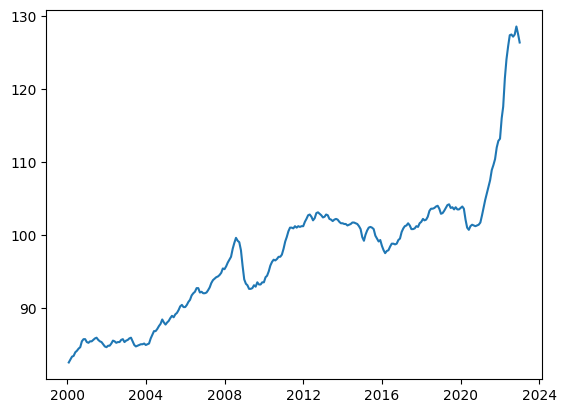

In [4]:
## X_14: EU 28 Countries PPI — FOUND Producer Prices Index: Economic Activities: Total Manufacturing for the European Union *monthly* 
### NOTE ON DATE -- first day of the month 
#**#*#**# NOTE for ex 2000-01-01 is the avg daily price fro JAN (nto for the prev or the next month )

FRED_API_KEY = "ba132add18e668066107070613e05207" ; SERIES_ID = "PIEAMP01EZM661N"

# Fetch data
url = f"https://api.stlouisfed.org/fred/series/observations?series_id={SERIES_ID}&api_key={FRED_API_KEY}&file_type=xml"
response = requests.get(url)

df_EU28_PPI = parse_fred_xml(response.content)

df_EU28_PPI['date'] = pd.to_datetime(df_EU28_PPI['date']) + pd.offsets.MonthEnd(0)

df_EU28_PPI = df_EU28_PPI.set_index('date')

print(df_EU28_PPI.head())

plt.plot(df_EU28_PPI["value"])


            value
date             
1987-11-30   58.8
1987-12-31   61.0


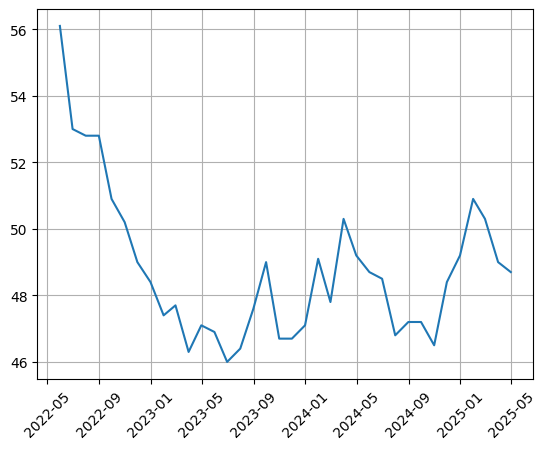

In [5]:
## X_15: US PMI Index *monthly*
### NOTE ON DATE — End of the month 


data_US_PMI = [ ####### NOTE US ISM Manufacturing PMI (I:USPMI) --https://ycharts.com/indicators/us_pmi 
    # First table (1987-1991)
    ("December 31, 1991", 46.80), ("November 30, 1991", 49.50), ("October 31, 1991", 53.10), 
    ("September 30, 1991", 54.90), ("August 31, 1991", 52.90), ("July 31, 1991", 50.60), ("June 30, 1991", 50.30), ("May 31, 1991", 44.50), ("April 30, 1991", 42.80), 
    ("March 31, 1991", 40.70), ("February 28, 1991", 39.40), ("January 31, 1991", 39.20), 
    ("December 31, 1990", 40.80), ("November 30, 1990", 41.30), ("October 31, 1990", 43.20), ("September 30, 1990", 44.50), ("August 31, 1990", 46.10), ("July 31, 1990", 46.60), 
    ("June 30, 1990", 49.20), ("May 31, 1990", 49.50), ("April 30, 1990", 50.00), ("March 31, 1990", 49.90), ("February 28, 1990", 49.10), ("January 31, 1990", 47.20), 
    ("December 31, 1989", 47.40), ("November 30, 1989", 46.80), ("October 31, 1989", 46.80), ("September 30, 1989", 46.00), ("August 31, 1989", 45.10), ("July 31, 1989", 45.90), 
    ("June 30, 1989", 47.30), ("May 31, 1989", 49.30), ("April 30, 1989", 52.20), ("March 31, 1989", 51.50), ("February 28, 1989", 54.10), ("January 31, 1989", 54.70), 
    ("December 31, 1988", 56.00), ("November 30, 1988", 55.60), ("October 31, 1988", 55.40), ("September 30, 1988", 54.50), ("August 31, 1988", 56.00), ("July 31, 1988", 58.20), 
    ("June 30, 1988", 59.30), ("May 31, 1988", 55.50), ("April 30, 1988", 55.80), ("March 31, 1988", 54.60), ("February 29, 1988", 56.20), ("January 31, 1988", 57.50), 
    ("December 31, 1987", 61.00), ("November 30, 1987", 58.80),
    
    # Second table (1992-1996)
    ("February 29, 1996", 45.90), ("January 31, 1996", 45.50), ("December 31, 1995", 46.20), 
    ("November 30, 1995", 45.90), ("October 31, 1995", 46.70), ("September 30, 1995", 48.10), ("August 31, 1995", 47.10), ("July 31, 1995", 50.70), ("June 30, 1995", 45.90), 
    ("May 31, 1995", 46.70), ("April 30, 1995", 51.50), ("March 31, 1995", 52.10), ("February 28, 1995", 55.10), ("January 31, 1995", 57.40), ("December 31, 1994", 56.10), 
    ("November 30, 1994", 59.20), ("October 31, 1994", 59.40), ("September 30, 1994", 59.00), ("August 31, 1994", 58.00), ("July 31, 1994", 58.50), ("June 30, 1994", 58.80), 
    ("May 31, 1994", 58.20), ("April 30, 1994", 57.40), ("March 31, 1994", 56.90), ("February 28, 1994", 56.50), ("January 31, 1994", 56.00), ("December 31, 1993", 55.60), 
    ("November 30, 1993", 53.80), ("October 31, 1993", 53.40), ("September 30, 1993", 50.80), ("August 31, 1993", 50.70), ("July 31, 1993", 50.20), ("June 30, 1993", 49.60), 
    ("May 31, 1993", 51.20), ("April 30, 1993", 50.20), ("March 31, 1993", 53.50), ("February 28, 1993", 55.20), ("January 31, 1993", 55.80), ("December 31, 1992", 54.20), 
    ("November 30, 1992", 53.60), ("October 31, 1992", 50.30), ("September 30, 1992", 49.70), ("August 31, 1992", 53.40), ("July 31, 1992", 53.90), ("June 30, 1992", 53.60), 
    ("May 31, 1992", 55.70), ("April 30, 1992", 52.60), ("March 31, 1992", 54.60), ("February 29, 1992", 52.70), ("January 31, 1992", 47.30),
    
    # Third table (1996-2000)
    ("April 30, 2000", 54.70), ("March 31, 2000", 54.90), ("February 29, 2000", 55.80), 
    ("January 31, 2000", 56.70), ("December 31, 1999", 57.80), ("November 30, 1999", 58.10), ("October 31, 1999", 57.20), ("September 30, 1999", 57.00), ("August 31, 1999", 54.80), 
    ("July 31, 1999", 53.60), ("June 30, 1999", 55.80), ("May 31, 1999", 54.30), ("April 30, 1999", 52.30), ("March 31, 1999", 52.40), ("February 28, 1999", 51.70), 
    ("January 31, 1999", 50.60), ("December 31, 1998", 46.80), ("November 30, 1998", 48.20), ("October 31, 1998", 48.70), ("September 30, 1998", 48.70), ("August 31, 1998", 49.30), 
    ("July 31, 1998", 49.20), ("June 30, 1998", 48.90), ("May 31, 1998", 50.90), ("April 30, 1998", 52.20), ("March 31, 1998", 52.90), ("February 28, 1998", 52.90), 
    ("January 31, 1998", 53.80), ("December 31, 1997", 54.50), ("November 30, 1997", 55.70), ("October 31, 1997", 56.40), ("September 30, 1997", 53.90), ("August 31, 1997", 56.30), 
    ("July 31, 1997", 57.70), ("June 30, 1997", 54.90), ("May 31, 1997", 56.10), ("April 30, 1997", 53.70), ("March 31, 1997", 53.80), ("February 28, 1997", 53.10), 
    ("January 31, 1997", 53.80), ("December 31, 1996", 55.20), ("November 30, 1996", 53.00), ("October 31, 1996", 50.50), ("September 30, 1996", 51.10), ("August 31, 1996", 51.60), 
    ("July 31, 1996", 49.70), ("June 30, 1996", 53.60), ("May 31, 1996", 49.10), ("April 30, 1996", 49.30), ("March 31, 1996", 46.90),
    
    # Fourth table (2000-2004)
    ("June 30, 2004", 60.50), ("May 31, 2004", 61.40), ("April 30, 2004", 60.60), 
    ("March 31, 2004", 60.60), ("February 29, 2004", 59.90), ("January 31, 2004", 60.80), ("December 31, 2003", 60.10), ("November 30, 2003", 58.40), ("October 31, 2003", 55.20), 
    ("September 30, 2003", 52.40), ("August 31, 2003", 53.20), ("July 31, 2003", 51.00), ("June 30, 2003", 49.00), ("May 31, 2003", 49.00), ("April 30, 2003", 46.10), 
    ("March 31, 2003", 46.30), ("February 28, 2003", 48.80), ("January 31, 2003", 51.30), ("December 31, 2002", 51.60), ("November 30, 2002", 48.50), ("October 31, 2002", 49.00), 
    ("September 30, 2002", 50.50), ("August 31, 2002", 50.30), ("July 31, 2002", 50.20), ("June 30, 2002", 53.60), ("May 31, 2002", 53.10), ("April 30, 2002", 52.40), 
    ("March 31, 2002", 52.40), ("February 28, 2002", 50.70), ("January 31, 2002", 47.50), ("December 31, 2001", 45.30), ("November 30, 2001", 44.10), ("October 31, 2001", 40.80), 
    ("September 30, 2001", 46.20), ("August 31, 2001", 46.30), ("July 31, 2001", 43.50), ("June 30, 2001", 43.20), ("May 31, 2001", 41.30), ("April 30, 2001", 42.70), 
    ("March 31, 2001", 43.10), ("February 28, 2001", 42.10), ("January 31, 2001", 42.30), ("December 31, 2000", 43.90), ("November 30, 2000", 48.50), ("October 31, 2000", 48.70), 
    ("September 30, 2000", 49.70), ("August 31, 2000", 49.90), ("July 31, 2000", 52.50), ("June 30, 2000", 51.40), ("May 31, 2000", 53.20),
    
    # Fifth table (2004-2008)
    ("August 31, 2008", 49.20), ("July 31, 2008", 49.60), ("June 30, 2008", 50.00), 
    ("May 31, 2008", 49.60), ("April 30, 2008", 48.90), ("March 31, 2008", 49.10), ("February 29, 2008", 48.70), ("January 31, 2008", 50.50), ("December 31, 2007", 48.70), 
    ("November 30, 2007", 50.70), ("October 31, 2007", 49.90), ("September 30, 2007", 50.40), ("August 31, 2007", 50.50), ("July 31, 2007", 52.10), ("June 30, 2007", 53.20), 
    ("May 31, 2007", 52.60), ("April 30, 2007", 52.90), ("March 31, 2007", 51.20), ("February 28, 2007", 51.90), ("January 31, 2007", 49.20), ("December 31, 2006", 52.00), 
    ("November 30, 2006", 50.40), ("October 31, 2006", 50.50), ("September 30, 2006", 51.80), ("August 31, 2006", 52.80), ("July 31, 2006", 53.20), ("June 30, 2006", 52.40), 
    ("May 31, 2006", 53.50), ("April 30, 2006", 55.80), ("March 31, 2006", 54.70), ("February 28, 2006", 55.50), ("January 31, 2006", 55.00), ("December 31, 2005", 54.90), 
    ("November 30, 2005", 56.50), ("October 31, 2005", 57.20), ("September 30, 2005", 56.50), ("August 31, 2005", 51.60), ("July 31, 2005", 54.00), ("June 30, 2005", 52.60), 
    ("May 31, 2005", 51.00), ("April 30, 2005", 52.50), ("March 31, 2005", 54.90), ("February 28, 2005", 54.80), ("January 31, 2005", 56.60), ("December 31, 2004", 57.20), 
    ("November 30, 2004", 56.20), ("October 31, 2004", 56.30), ("September 30, 2004", 57.40), ("August 31, 2004", 58.50), ("July 31, 2004", 59.90),
    
    # Sixth table (2008-2012)
    ("October 31, 2012", 51.20), ("September 30, 2012", 52.20), ("August 31, 2012", 51.10), 
    ("July 31, 2012", 50.60), ("June 30, 2012", 51.00), ("May 31, 2012", 53.20), ("April 30, 2012", 53.70), ("March 31, 2012", 53.00), ("February 29, 2012", 52.40), 
    ("January 31, 2012", 52.80), ("December 31, 2011", 52.90), ("November 30, 2011", 52.30), ("October 31, 2011", 51.50), ("September 30, 2011", 53.20), ("August 31, 2011", 53.20), 
    ("July 31, 2011", 52.30), ("June 30, 2011", 55.80), ("May 31, 2011", 53.50), ("April 30, 2011", 59.40), ("March 31, 2011", 59.30), ("February 28, 2011", 59.60), 
    ("January 31, 2011", 59.20), ("December 31, 2010", 57.30), ("November 30, 2010", 58.00), ("October 31, 2010", 57.00), ("September 30, 2010", 56.40), ("August 31, 2010", 57.40), 
    ("July 31, 2010", 55.70), ("June 30, 2010", 56.00), ("May 31, 2010", 58.80), ("April 30, 2010", 59.00), ("March 31, 2010", 59.30), ("February 28, 2010", 55.80), 
    ("January 31, 2010", 56.70), ("December 31, 2009", 56.40), ("November 30, 2009", 54.70), ("October 31, 2009", 55.80), ("September 30, 2009", 53.20), ("August 31, 2009", 51.40), 
    ("July 31, 2009", 49.00), ("June 30, 2009", 44.70), ("May 31, 2009", 41.90), ("April 30, 2009", 39.90), ("March 31, 2009", 36.60), ("February 28, 2009", 36.00), 
    ("January 31, 2009", 35.70), ("December 31, 2008", 33.30), ("November 30, 2008", 36.70), ("October 31, 2008", 38.40), ("September 30, 2008", 43.20),
    
    # Seventh table (2012-2016)
    ("December 31, 2016", 54.50), ("November 30, 2016", 53.20), ("October 31, 2016", 51.90), 
    ("September 30, 2016", 51.50), ("August 31, 2016", 49.40), ("July 31, 2016", 52.60), ("June 30, 2016", 53.20), ("May 31, 2016", 51.30), ("April 30, 2016", 50.80), 
    ("March 31, 2016", 51.80), ("February 29, 2016", 49.50), ("January 31, 2016", 48.20), 
    ("December 31, 2015", 48.00), ("November 30, 2015", 48.60), ("October 31, 2015", 50.10), ("September 30, 2015", 50.20), ("August 31, 2015", 51.10), ("July 31, 2015", 52.70), 
    ("June 30, 2015", 53.50), ("May 31, 2015", 52.80), ("April 30, 2015", 51.50), 
    ("March 31, 2015", 51.50), ("February 28, 2015", 52.90), ("January 31, 2015", 53.50), ("December 31, 2014", 55.10), ("November 30, 2014", 58.70), ("October 31, 2014", 59.00), 
    ("September 30, 2014", 56.60), ("August 31, 2014", 59.00), ("July 31, 2014", 57.10), ("June 30, 2014", 55.30), ("May 31, 2014", 55.40), ("April 30, 2014", 54.90), 
    ("March 31, 2014", 53.70), ("February 28, 2014", 53.20), ("January 31, 2014", 51.30), ("December 31, 2013", 56.50), ("November 30, 2013", 57.00), ("October 31, 2013", 56.60), 
    ("September 30, 2013", 56.00), ("August 31, 2013", 56.30), ("July 31, 2013", 54.90), ("June 30, 2013", 52.50), ("May 31, 2013", 50.00), ("April 30, 2013", 50.00), 
    ("March 31, 2013", 51.50), ("February 28, 2013", 53.10), ("January 31, 2013", 52.30), ("December 31, 2012", 50.40), ("November 30, 2012", 49.50),
    
    # Eighth table (2016-2021)
    ("February 28, 2021", 60.80), ("January 31, 2021", 58.70), ("December 31, 2020", 60.50), 
    ("November 30, 2020", 57.50), ("October 31, 2020", 59.30), ("September 30, 2020", 55.40), ("August 31, 2020", 56.00), ("July 31, 2020", 54.20), ("June 30, 2020", 52.60), 
    ("May 31, 2020", 43.10), ("April 30, 2020", 41.50), ("March 31, 2020", 49.10), ("February 29, 2020", 50.10), ("January 31, 2020", 50.90), ("December 31, 2019", 47.80), 
    ("November 30, 2019", 48.10), ("October 31, 2019", 48.30), ("September 30, 2019", 47.80), ("August 31, 2019", 49.10), ("July 31, 2019", 51.20), ("June 30, 2019", 51.70), 
    ("May 31, 2019", 52.10), ("April 30, 2019", 52.80), ("March 31, 2019", 55.30), ("February 28, 2019", 54.20), ("January 31, 2019", 56.60), ("December 31, 2018", 54.30), 
    ("November 30, 2018", 59.30), ("October 31, 2018", 57.70), ("September 30, 2018", 59.80), ("August 31, 2018", 61.30), ("July 31, 2018", 58.10), ("June 30, 2018", 60.20), 
    ("May 31, 2018", 58.70), ("April 30, 2018", 57.30), ("March 31, 2018", 59.30), ("February 28, 2018", 60.80), ("January 31, 2018", 56.60), ("December 31, 2017", 59.30), 
    ("November 30, 2017", 58.20), ("October 31, 2017", 58.70), ("September 30, 2017", 60.80), ("August 31, 2017", 58.80), ("July 31, 2017", 56.30), ("June 30, 2017", 57.80), 
    ("May 31, 2017", 54.90), ("April 30, 2017", 54.80), ("March 31, 2017", 57.20), ("February 28, 2017", 57.70), ("January 31, 2017", 56.00),
    
    # Ninth table (2021-2025)
    ("April 30, 2025", 48.70), ("March 31, 2025", 49.00), ("February 28, 2025", 50.30), ("January 31, 2025", 50.90), ("December 31, 2024", 49.20), ("November 30, 2024", 48.40), 
    ("October 31, 2024", 46.50), ("September 30, 2024", 47.20), ("August 31, 2024", 47.20), ("July 31, 2024", 46.80), ("June 30, 2024", 48.50), ("May 31, 2024", 48.70), 
    ("April 30, 2024", 49.20), ("March 31, 2024", 50.30), ("February 29, 2024", 47.80), ("January 31, 2024", 49.10), ("December 31, 2023", 47.10), ("November 30, 2023", 46.70), 
    ("October 31, 2023", 46.70), ("September 30, 2023", 49.00), ("August 31, 2023", 47.60), ("July 31, 2023", 46.40), ("June 30, 2023", 46.00), ("May 31, 2023", 46.90), 
    ("April 30, 2023", 47.10), ("March 31, 2023", 46.30), ("February 28, 2023", 47.70), ("January 31, 2023", 47.40), ("December 31, 2022", 48.40), ("November 30, 2022", 49.00), 
    ("October 31, 2022", 50.20), ("September 30, 2022", 50.90), ("August 31, 2022", 52.80), 
    ("July 31, 2022", 52.80), ("June 30, 2022", 53.00), ("May 31, 2022", 56.10), ("April 30, 2022", 55.40), ("March 31, 2022", 57.10), ("February 28, 2022", 58.60), 
    ("January 31, 2022", 57.60), ("December 31, 2021", 58.80), ("November 30, 2021", 61.10), ("October 31, 2021", 60.80), ("September 30, 2021", 61.10), ("August 31, 2021", 59.90), 
    ("July 31, 2021", 59.50), ("June 30, 2021", 60.60), ("May 31, 2021", 61.20), ("April 30, 2021", 60.70), ("March 31, 2021", 64.70)
]

df_US_PMI = pd.DataFrame(data_US_PMI, columns=['date', 'value'])

df_US_PMI['date'] = pd.to_datetime(df_US_PMI['date'])

df_US_PMI = df_US_PMI.sort_values('date', ascending=True)

df_US_PMI = df_US_PMI.set_index('date')

print(df_US_PMI.head(2))

df_US_PMI.index[0]


plt.plot(df_US_PMI["value"][df_US_PMI.index >= '2022-05-22'])
plt.xticks(rotation = 45)
plt.grid(True)


In [6]:
 ## X_16: Petroleum Inventory, Total OECD - FOUND Monthly OECD petroleum and other liquids stocks *monthly*
### NOTE ON DATE — End of the month 


#NOTE URL FOR DATA INFO https://www.eia.gov/international/data/world/featured-view/3?pd=5&p=00000000000000000000000000000000000004&u=0&f=M&v=mapbubble&a=-&i=none&vo=value&t=C&g=0000000000000000000000000000000000o&l=170-0268001c153kg614808a24sg40e10000gig006g0001o00g2gg&l=171-00280008013kg614808024k000e00000gg8004g0001o00g&s=315532800000&e=1735689600000
url = f"https://api.eia.gov/v2/international/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=monthly&data[0]=value&facets[activityId][]=5&facets[productId][]=5&facets[countryRegionId][]=OECD&facets[unit][]=MBBL&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)

df_oecd_pet_stocks = pd.DataFrame(jsonxx['response']['data'])

df_oecd_pet_stocks['value'] = pd.to_numeric(df_oecd_pet_stocks['value'], errors='coerce')

df_oecd_pet_stocks['date'] = pd.to_datetime(df_oecd_pet_stocks['period']) + pd.offsets.MonthEnd(0) ###pd.offsets.MonthEnd(0) makes it display end of moth dates, by default it will display begining of month dates which is wrong 

df_oecd_pet_stocks=df_oecd_pet_stocks.set_index('date')


response.text

 #*#**# absed on the graph in https://ycharts.com/indicators/oecd_petroleum_stocks this looks correct 

'{"response":{"total":"542","dateFormat":"YYYY-MM","frequency":"monthly","data":[{"period":"2025-02","productId":"5","productName":"Petroleum and other liquids","activityId":"5","activityName":"Stocks, OECD","countryRegionId":"OECD","countryRegionName":"OECD","countryRegionTypeId":"r","countryRegionTypeName":"Region","dataFlagId":null,"dataFlagDescription":null,"unitName":"millions barrels","value":"3954.259007","unit":"MBBL"},{"period":"2025-01","productId":"5","productName":"Petroleum and other liquids","activityId":"5","activityName":"Stocks, OECD","countryRegionId":"OECD","countryRegionName":"OECD","countryRegionTypeId":"r","countryRegionTypeName":"Region","dataFlagId":null,"dataFlagDescription":null,"unitName":"millions barrels","value":"3972.597001","unit":"MBBL"},{"period":"2024-12","productId":"5","productName":"Petroleum and other liquids","activityId":"5","activityName":"Stocks, OECD","countryRegionId":"OECD","countryRegionName":"OECD","countryRegionTypeId":"r","countryRegion

In [7]:
## X_18: Crude Oil Inventory, SPR (Strategic Petroleum Reserve) 


# NOTE  US Ending stocks of crude oil in SPR   -- WEEKLY and MONTLY avaiblable 
# NOTE weekly url https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=WCSSTUS1&f=W 
# NOTE URL FOR DATA INFO https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=MCSSTUS1&f=M


#*#**#*#*# WKLY 
url_wkly = f"https://api.eia.gov/v2/petroleum/sum/sndw/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=WCSSTUS1&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response_wkly = requests.get(url_wkly)

jsonxx_wkly = json.loads(response_wkly.text)
df_oecd_stocks_oilSPR_wkly = pd.DataFrame(jsonxx_wkly['response']['data'])
df_oecd_stocks_oilSPR_wkly['value'] = pd.to_numeric(df_oecd_stocks_oilSPR_wkly['value'], errors='coerce')
df_oecd_stocks_oilSPR_wkly['date'] = pd.to_datetime(df_oecd_stocks_oilSPR_wkly['period'])
df_oecd_stocks_oilSPR_wkly=df_oecd_stocks_oilSPR_wkly.set_index('date')
#*#**#*#*# WKLY 


#*#**#*#*# MONTHLY 
url_monthly = f"https://api.eia.gov/v2/petroleum/sum/crdsnd/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=monthly&data[0]=value&facets[series][]=MCSSTUS1&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response_monthly = requests.get(url_monthly)

jsonxx_monthly = json.loads(response_monthly.text)
df_oecd_stocks_oilSPR_monthly = pd.DataFrame(jsonxx_monthly['response']['data'])
df_oecd_stocks_oilSPR_monthly['value'] = pd.to_numeric(df_oecd_stocks_oilSPR_monthly['value'], errors='coerce')
df_oecd_stocks_oilSPR_monthly['date'] = pd.to_datetime(df_oecd_stocks_oilSPR_monthly['period'])

df_oecd_stocks_oilSPR_monthly=df_oecd_stocks_oilSPR_monthly.set_index('date')

#*#**#*#*# MONTHLY

print(f"Date range wkly: {df_oecd_stocks_oilSPR_wkly['period'].min()} to {df_oecd_stocks_oilSPR_wkly['period'].max()}")

print(f"Date range monthly: {df_oecd_stocks_oilSPR_monthly.index.min()} to {df_oecd_stocks_oilSPR_monthly['period'].max()}")

print(df_oecd_stocks_oilSPR_wkly.index[0:40])


Date range wkly: 1982-08-20 to 2025-05-30
Date range monthly: 1977-10-01 00:00:00 to 2025-03
DatetimeIndex(['2025-05-30', '2025-05-23', '2025-05-16', '2025-05-09',
               '2025-05-02', '2025-04-25', '2025-04-18', '2025-04-11',
               '2025-04-04', '2025-03-28', '2025-03-21', '2025-03-14',
               '2025-03-07', '2025-02-28', '2025-02-21', '2025-02-14',
               '2025-02-07', '2025-01-31', '2025-01-24', '2025-01-17',
               '2025-01-10', '2025-01-03', '2024-12-27', '2024-12-20',
               '2024-12-13', '2024-12-06', '2024-11-29', '2024-11-22',
               '2024-11-15', '2024-11-08', '2024-11-01', '2024-10-25',
               '2024-10-18', '2024-10-11', '2024-10-04', '2024-09-27',
               '2024-09-20', '2024-09-13', '2024-09-06', '2024-08-30'],
              dtype='datetime64[ns]', name='date', freq=None)


In [8]:
## X_19: Crude Oil Inventory, Non-SPR — **monthly,weekly**

# NOTE US Ending stocks of crude oul excluding SPR --- wk and monthly available 
# NOTE URL FOR DATA INFO https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=pet&s=mcestus1&f=m

#*#**#*#*# WKLY 
url_wkly = f"https://api.eia.gov/v2/petroleum/sum/sndw/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=WCESTUS1&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response_wkly = requests.get(url_wkly)

jsonxx_wkly = json.loads(response_wkly.text)
df_oecd_stocks_oilnonSPR_wkly = pd.DataFrame(jsonxx_wkly['response']['data'])
df_oecd_stocks_oilnonSPR_wkly['value'] = pd.to_numeric(df_oecd_stocks_oilnonSPR_wkly['value'], errors='coerce')
df_oecd_stocks_oilnonSPR_wkly['date'] = pd.to_datetime(df_oecd_stocks_oilnonSPR_wkly['period'])
df_oecd_stocks_oilnonSPR_wkly=df_oecd_stocks_oilnonSPR_wkly.set_index('date')
#*#**#*#*# WKLY 

#*#**#*#*# MONTHLY 
url_monthly = f"https://api.eia.gov/v2/petroleum/sum/crdsnd/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=monthly&data[0]=value&facets[series][]=MCESTUS1&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response_monthly = requests.get(url_monthly)


jsonxx_monthly = json.loads(response_monthly.text)
df_oecd_stocks_oilnonSPR_monthly = pd.DataFrame(jsonxx_monthly['response']['data'])
df_oecd_stocks_oilnonSPR_monthly['value'] = pd.to_numeric(df_oecd_stocks_oilnonSPR_monthly['value'], errors='coerce')
df_oecd_stocks_oilnonSPR_monthly['date'] = pd.to_datetime(df_oecd_stocks_oilnonSPR_monthly['period'],format ="%Y-%m")
df_oecd_stocks_oilnonSPR_monthly.set_index('date' ,inplace=True)

print(df_oecd_stocks_oilnonSPR_monthly.index[0])
# df_oecd_stocks_oilnonSPR_monthly=df_oecd_stocks_oilnonSPR_monthly.set_index('date')
# #*#**#*#*# MONTHLY

# print(f"Date range wkly: {df_oecd_stocks_oilnonSPR_wkly['period'].min()} to {df_oecd_stocks_oilnonSPR_wkly['period'].max()}")

# print(f"Date range monthly: {df_oecd_stocks_oilnonSPR_monthly['period'].min()} to {df_oecd_stocks_oilnonSPR_monthly['period'].max()}")

# df_oecd_stocks_oilnonSPR_monthly['period'] = pd.to_datetime(
#     df_oecd_stocks_oilnonSPR_monthly['period'], format="%Y-%m"
# ) + pd.offsets.MonthEnd(0)








2025-03-01 00:00:00


In [9]:
## X_20: Crude oil non-commercial net long ratio *weekly*

# CFTC Crude Oil speculative net positions -- https://www.investing.com/economic-calendar/cftc-crude-oil-speculative-positions-1653

data_speculation = """ 	
May 23, 2025 	15:30 	186.4K 	  	185.3K 	
May 16, 2025 	15:30 	185.3K 	  	175.4K 	
May 09, 2025 	15:30 	175.4K 	  	177.2K 	
May 02, 2025 	15:30 	177.2K 	  	171.0K 	
Apr 25, 2025 	15:30 	171.0K 	  	146.4K 	
Apr 18, 2025 	15:30 	146.4K 	  	139.6K 	
Apr 11, 2025 	15:30 	139.6K 	  	167.7K 	
Apr 04, 2025 	15:30 	167.7K 	  	180.6K 	
Mar 28, 2025 	15:30 	180.6K 	  	166.8K 	
Mar 21, 2025 	15:30 	166.8K 	  	164.1K 	
Mar 14, 2025 	15:30 	164.1K 	  	154.8K 	
Mar 07, 2025 	16:30 	154.8K 	  	171.2K 	
Feb 28, 2025 	16:30 	171.2K 	  	197.6K 	
Feb 21, 2025 	16:30 	197.6K 	  	220.0K 	
Feb 14, 2025 	16:30 	220.0K 	  	230.3K 	
Feb 07, 2025 	16:30 	230.3K 	  	264.1K 	
Jan 31, 2025 	16:30 	264.1K 	  	298.8K 	
Jan 24, 2025 	16:30 	298.8K 	  	306.3K 	
Jan 17, 2025 	16:30 	306.3K 	  	279.6K 	
Jan 13, 2025 	16:30 	279.6K 	  	254.3K 	
Jan 06, 2025 	16:30 	254.3K 	  	247.0K 	
Dec 30, 2024 	16:30 	247.0K 	  	230.0K 	
Dec 20, 2024 	16:30 	230.0K 	  	190.1K 	
Dec 13, 2024 	16:30 	190.1K 	  	201.5K 	
Dec 06, 2024 	16:30 	201.5K 	  	200.4K 	
Dec 02, 2024 	16:30 	200.4K 	  	193.9K 	
Nov 22, 2024 	16:30 	193.9K 	  	186.9K 	
Nov 15, 2024 	16:30 	186.9K 	  	196.1K 	
Nov 08, 2024 	16:30 	196.1K 	  	151.9K 	
Nov 01, 2024 	15:30 	151.9K 	  	173.7K 	
Oct 25, 2024 	15:30 	173.7K 	  	184.4K 	
Oct 18, 2024 	15:30 	184.4K 	  	190.6K 	
Oct 11, 2024 	15:30 	190.6K 	  	159.6K 	
Oct 04, 2024 	15:30 	159.6K 	  	158.6K 	
Sep 27, 2024 	15:30 	158.6K 	  	145.3K 	
Sep 20, 2024 	15:30 	145.3K 	  	140.0K 	
Sep 13, 2024 	15:30 	140.0K 	  	177.0K 	
Sep 06, 2024 	15:30 	177.0K 	  	226.7K 	
Aug 30, 2024 	15:30 	226.7K 	  	222.3K 	
Aug 23, 2024 	15:30 	222.3K 	  	231.5K 	
Aug 16, 2024 	15:30 	231.5K 	  	222.3K 	
Aug 09, 2024 	15:30 	222.3K 	  	245.5K 	
Aug 02, 2024 	15:30 	245.5K 	  	276.0K 	
Jul 26, 2024 	15:30 	276.0K 	  	287.6K 	
Jul 19, 2024 	15:30 	287.6K 	  	283.9K 	
Jul 12, 2024 	15:30 	283.9K 	  	279.9K 	
Jul 08, 2024 	15:30 	279.9K 	  	271.2K 	
Jun 28, 2024 	15:30 	271.2K 	  	246.8K 	
Jun 24, 2024 	15:30 	246.8K 	  	233.5K 	
Jun 14, 2024 	15:30 	233.5K 	  	210.7K 	
Jun 07, 2024 	15:30 	210.7K 	  	243.9K 	
May 31, 2024 	15:30 	243.9K 	  	219.3K 	
May 24, 2024 	15:30 	219.3K 	  	203.0K 	
May 17, 2024 	15:30 	203.0K 	  	215.4K 	
May 10, 2024 	15:30 	215.4K 	  	265.5K 	
May 03, 2024 	15:30 	265.5K 	  	264.8K 	
Apr 26, 2024 	15:30 	264.8K 	  	290.5K 	
Apr 19, 2024 	15:30 	290.5K 	  	297.1K 	
Apr 12, 2024 	15:30 	297.1K 	  	300.9K 	
Apr 05, 2024 	15:30 	300.9K 	  	278.0K 	
Mar 29, 2024 	15:30 	278.0K 	  	277.8K 	
Mar 22, 2024 	15:30 	277.8K 	  	233.8K 	
Mar 15, 2024 	16:30 	233.8K 	  	238.5K 	
Mar 08, 2024 	16:30 	238.5K 	  	224.8K 	
Mar 01, 2024 	16:30 	224.8K 	  	191.9K 	
Feb 23, 2024 	16:30 	191.9K 	  	171.0K 	
Feb 16, 2024 	16:30 	171.0K 	  	161.8K 	
Feb 09, 2024 	16:30 	161.8K 	  	196.7K 	
Feb 02, 2024 	16:30 	196.7K 	  	184.0K 	
Jan 26, 2024 	16:30 	184.0K 	  	162.0K 	
Jan 19, 2024 	16:30 	162.0K 	  	169.7K 	
Jan 12, 2024 	16:30 	169.7K 	  	163.7K 	
Jan 05, 2024 	16:30 	163.7K 	  	199.3K 	
Dec 29, 2023 	16:30 	199.3K 	  	182.7K 	
Dec 22, 2023 	16:30 	182.7K 	  	151.6K 	
Dec 15, 2023 	16:30 	151.6K 	  	169.0K 	
Dec 08, 2023 	16:30 	169.0K 	  	183.2K 	
Dec 01, 2023 	16:30 	183.2K 	  	207.3K 	
Nov 27, 2023 	16:30 	207.3K 	  	215.7K 	
Nov 17, 2023 	16:30 	215.7K 	  	236.0K 	
Nov 13, 2023 	16:30 	236.0K 	  	262.3K 	
Nov 03, 2023 	16:30 	262.3K 	  	300.8K 	
Oct 27, 2023 	16:30 	300.8K 	  	306.4K 	
Oct 20, 2023 	16:30 	306.4K 	  	322.0K 	
Oct 13, 2023 	16:30 	322.0K 	  	349.6K 	
Oct 06, 2023 	16:30 	349.6K 	  	350.1K 	
Sep 29, 2023 	16:30 	350.1K 	  	328.4K 	
Sep 22, 2023 	16:30 	328.4K 	  	326.9K 	
Sep 15, 2023 	16:30 	326.9K 	  	299.3K 	
Sep 08, 2023 	16:30 	299.3K 	  	240.9K 	
Sep 01, 2023 	16:30 	240.9K 	  	234.4K 	
Aug 25, 2023 	16:30 	234.4K 	  	242.1K 	
Aug 18, 2023 	16:30 	242.1K 	  	255.9K 	
Aug 11, 2023 	16:30 	255.9K 	  	241.9K 	
Aug 04, 2023 	16:30 	241.9K 	  	225.2K 	
Jul 28, 2023 	16:30 	225.2K 	  	206.1K 	
Jul 21, 2023 	16:30 	206.1K 	  	173.4K 	
Jul 14, 2023 	16:30 	173.4K 	  	141.4K 	
Jul 07, 2023 	16:30 	141.4K 	  	138.4K 	
Jun 30, 2023 	16:30 	138.4K 	  	166.5K 	
Jun 23, 2023 	16:30 	166.5K 	  	155.1K 	
Jun 16, 2023 	16:30 	155.1K 	  	172.4K 	
Jun 09, 2023 	16:30 	172.4K 	  	162.6K 	
Jun 02, 2023 	16:30 	162.6K 	  	193.1K 	
May 26, 2023 	16:30 	193.1K 	  	191.5K 	
May 19, 2023 	16:30 	191.5K 	  	216.6K 	
May 12, 2023 	16:30 	216.6K 	  	214.8K 	
May 05, 2023 	16:30 	214.8K 	  	236.4K 	
Apr 28, 2023 	16:30 	236.4K 	  	244.6K 	
Apr 21, 2023 	16:30 	244.6K 	  	235.6K 	
Apr 14, 2023 	16:30 	235.6K 	  	226.1K 	
Apr 07, 2023 	16:30 	226.1K 	  	181.1K 	
Mar 31, 2023 	16:30 	181.1K 	  	154.3K 	
Mar 24, 2023 	16:30 	154.3K 	  	206.9K 	
Mar 17, 2023 	16:30 	206.9K 	  	219.7K 	
Mar 10, 2023 	16:30 	219.7K 	  	224.2K 	
Mar 03, 2023 	16:30 	224.2K 	  	243.8K 	
Feb 24, 2023 	16:30 	243.8K 	  	249.8K 	
Jan 27, 2023 	16:30 	249.8K 	  	239.2K 	
Jan 20, 2023 	16:30 	239.2K 	  	205.2K 	
Jan 13, 2023 	16:30 	205.2K 	  	227.6K 	
Jan 06, 2023 	16:30 	227.6K 	  	247.6K 	
Dec 30, 2022 	16:30 	247.6K 	  	238.2K 	
Dec 23, 2022 	16:30 	238.2K 	  	229.6K 	
Dec 16, 2022 	16:30 	229.6K 	  	231.7K 	
Dec 09, 2022 	16:30 	231.7K 	  	239.7K 	
Dec 02, 2022 	15:30 	239.7K 	  	252.5K 	
Nov 28, 2022 	15:30 	252.5K 	  	278.3K 	
Nov 18, 2022 	15:30 	278.3K 	  	274.8K 	
Nov 14, 2022 	15:30 	274.8K 	  	254.8K 	
Nov 04, 2022 	15:30 	254.8K 	  	249.1K 	
Oct 28, 2022 	15:30 	249.1K 	  	251.5K 	
Oct 21, 2022 	15:30 	251.5K 	  	259.2K 	
Oct 14, 2022 	15:30 	259.2K 	  	242.0K 	
Oct 07, 2022 	15:30 	242.0K 	  	226.1K 	
Sep 30, 2022 	15:30 	226.1K 	  	239.9K 	
Sep 23, 2022 	15:30 	239.9K 	  	227.1K 	
Sep 16, 2022 	15:30 	227.1K 	  	214.5K 	
Sep 09, 2022 	15:30 	214.5K 	  	229.2K 	
Sep 02, 2022 	15:30 	229.2K 	  	246.2K 	
Aug 26, 2022 	15:30 	246.2K 	  	214.9K 	
Aug 19, 2022 	15:30 	214.9K 	  	210.7K 	
Aug 12, 2022 	15:30 	210.7K 	  	253.8K 	
Aug 05, 2022 	15:30 	253.8K 	  	259.3K 	
Jul 29, 2022 	15:30 	259.3K 	  	271.1K 	
Jul 22, 2022 	15:30 	271.1K 	  	268.3K 	
Jul 15, 2022 	15:30 	268.3K 	  	280.5K 	
Jul 08, 2022 	15:30 	280.5K 	  	299.7K 	
Jul 01, 2022 	15:30 	299.7K 	  	289.5K 	
Jun 24, 2022 	15:30 	289.5K 	  	302.9K 	
Jun 17, 2022 	15:30 	302.9K 	  	328.3K 	
Jun 10, 2022 	15:30 	328.3K 	  	333.0K 	
Jun 03, 2022 	15:30 	333.0K 	  	334.8K 	
May 27, 2022 	15:30 	334.8K 	  	325.6K 	
May 20, 2022 	15:30 	325.6K 	  	310.8K 	
May 13, 2022 	15:30 	310.8K 	  	321.7K 	
May 06, 2022 	15:30 	321.7K 	  	316.1K 	
Apr 29, 2022 	15:30 	316.1K 	  	307.7K 	
Apr 22, 2022 	15:30 	307.7K 	  	304.8K 	
Apr 15, 2022 	15:30 	304.8K 	  	308.6K 	
Apr 08, 2022 	15:30 	308.6K 	  	318.7K 	
Apr 01, 2022 	15:30 	318.7K 	  	340.0K 	
Mar 25, 2022 	15:30 	340.0K 	  	341.8K 	
Mar 18, 2022 	15:30 	341.8K 	  	361.7K 	
Mar 11, 2022 	16:30 	361.7K 	  	368.7K 	
Mar 04, 2022 	16:30 	368.7K 	  	339.0K 	
Feb 25, 2022 	16:30 	339.0K 	  	348.1K 	
Feb 18, 2022 	16:30 	348.1K 	  	363.4K 	
Feb 11, 2022 	16:30 	363.4K 	  	368.9K 	
Feb 04, 2022 	16:30 	368.9K 	  	373.4K 	
Jan 28, 2022 	16:30 	373.4K 	  	385.8K 	
Jan 21, 2022 	16:30 	385.8K 	  	360.5K 	
Jan 14, 2022 	16:30 	360.5K 	  	332.8K 	
Jan 07, 2022 	16:30 	332.8K 	  	338.4K 	
Jan 03, 2022 	16:30 	338.4K 	  	340.3K 	
Dec 27, 2021 	16:30 	340.3K 	  	347.1K 	
Dec 17, 2021 	16:30 	347.1K 	  	367.2K 	
Dec 10, 2021 	16:30 	367.2K 	  	387.2K 	
Dec 03, 2021 	16:30 	387.2K 	  	407.7K 	
Nov 29, 2021 	16:30 	407.7K 	  	415.8K 	
Nov 19, 2021 	16:30 	415.8K 	  	421.3K 	
Nov 15, 2021 	15:30 	421.3K 	  	419.3K 	
Nov 05, 2021 	15:30 	419.3K 	  	423.7K 	
Oct 29, 2021 	15:30 	423.7K 	  	429.6K 	
Oct 22, 2021 	15:30 	429.6K 	  	404.8K 	
Oct 15, 2021 	15:30 	404.8K 	  	398.3K 	
Oct 08, 2021 	15:30 	398.3K 	  	373.8K 	
Oct 01, 2021 	15:30 	373.8K 	  	356.0K 	
Sep 24, 2021 	15:30 	356.0K 	  	355.1K 	
Sep 17, 2021 	15:30 	355.1K 	  	349.2K 	
Sep 10, 2021 	15:30 	349.2K 	  	356.5K 	
Sep 03, 2021 	15:30 	356.5K 	  	374.3K 	
Aug 27, 2021 	15:30 	374.3K 	  	404.3K 	
Aug 20, 2021 	15:30 	404.3K 	  	400.4K 	
Aug 13, 2021 	15:30 	400.4K 	  	430.5K 	
Aug 06, 2021 	15:30 	430.5K 	  	449.8K 	
Jul 30, 2021 	15:30 	449.8K 	  	448.7K 	
Jul 23, 2021 	15:30 	448.7K 	  	499.1K 	
Jul 16, 2021 	15:30 	499.1K 	  	497.4K 	
Jul 09, 2021 	15:30 	497.4K 	  	522.5K 	
Jul 02, 2021 	15:30 	522.5K 	  	526.2K 	
Jun 25, 2021 	15:30 	526.2K 	  	510.5K 	
Jun 11, 2021 	15:30 	510.5K 	  	491.3K 	
Jun 04, 2021 	15:30 	491.3K 	  	475.5K 	
May 28, 2021 	15:30 	475.5K 	  	475.9K 	
May 21, 2021 	15:30 	475.9K 	  	496.6K 	
May 14, 2021 	15:30 	496.6K 	  	500.0K 	
May 07, 2021 	15:30 	500.0K 	  	489.7K 	
Apr 30, 2021 	15:30 	489.7K 	  	500.0K 	
Apr 23, 2021 	15:30 	500.0K 	  	492.7K 	
Apr 16, 2021 	15:30 	492.7K 	  	511.7K 	
Apr 09, 2021 	15:30 	511.7K 	  	531.3K 	
Apr 02, 2021 	16:30 	531.3K 	  	523.1K 	
Mar 26, 2021 	16:30 	523.1K 	  	525.4K 	
Mar 19, 2021 	16:30 	525.4K 	  	537.4K 	
Mar 12, 2021 	16:30 	537.4K 	  	519.0K 	
Mar 05, 2021 	16:30 	519.0K 	  	511.8K 	
Feb 26, 2021 	16:30 	511.8K 	  	514.7K 	
Feb 19, 2021 	16:30 	514.7K 	  	514.3K 	
Feb 12, 2021 	16:30 	514.3K 	  	499.2K 	
Feb 05, 2021 	16:30 	499.2K 	  	504.6K 	
Jan 29, 2021 	16:30 	504.6K 	  	508.6K 	
Jan 22, 2021 	16:30 	508.6K 	  	527.7K 	
Jan 15, 2021 	16:30 	527.7K 	  	518.6K 	
Jan 08, 2021 	16:30 	518.6K 	  	511.7K 	
Jan 04, 2021 	16:30 	511.7K 	  	525.7K 	
Dec 28, 2020 	16:30 	525.7K 	  	514.6K 	
Dec 18, 2020 	16:30 	514.6K 	  	517.2K 	
Dec 11, 2020 	16:30 	517.2K 	  	517.2K 	
Dec 04, 2020 	16:30 	517.2K 	  	522.6K 	
Nov 30, 2020 	16:30 	522.6K 	  	480.8K 	
Nov 20, 2020 	16:30 	480.8K 	  	463.5K 	
Nov 16, 2020 	16:30 	463.5K 	  	442.5K 	
Nov 06, 2020 	16:30 	442.5K 	  	472.1K 	
Oct 30, 2020 	15:30 	472.1K 	  	490.3K 	
Oct 23, 2020 	15:30 	490.3K 	  	472.8K 	
Oct 16, 2020 	15:30 	472.8K 	  	471.5K 	
Oct 09, 2020 	15:30 	471.5K 	  	461.9K 	
Oct 02, 2020 	15:30 	461.9K 	  	472.8K 	
Sep 25, 2020 	15:30 	472.8K 	  	449.7K 	
Sep 18, 2020 	15:30 	449.7K 	  	449.4K 	
Sep 11, 2020 	15:30 	449.4K 	  	490.9K 	
Sep 04, 2020 	15:30 	490.9K 	  	500.7K 	
Aug 28, 2020 	15:30 	500.7K 	  	510.7K 	
Aug 21, 2020 	15:30 	510.7K 	  	520.9K 	
Aug 14, 2020 	15:30 	520.9K 	  	536.3K 	
Aug 07, 2020 	15:30 	536.3K 	  	532.6K 	
Jul 31, 2020 	15:30 	532.6K 	  	548.9K 	
Jul 24, 2020 	15:30 	548.9K 	  	539.8K 	
Jul 17, 2020 	15:30 	539.8K 	  	535.3K 	
Jul 10, 2020 	15:30 	535.3K 	  	543.8K 	
Jul 06, 2020 	15:30 	543.8K 	  	560.9K 	
Jun 26, 2020 	15:30 	560.9K 	  	546.3K 	
Jun 19, 2020 	15:30 	546.3K 	  	567.9K 	
Jun 12, 2020 	15:30 	567.9K 	  	568.3K 	
Jun 05, 2020 	15:30 	568.3K 	  	542.6K 	
May 29, 2020 	15:30 	542.6K 	  	543.6K 	
May 22, 2020 	15:30 	543.6K 	  	541.0K 	
May 15, 2020 	15:30 	541.0K 	  	530.6K 	
May 08, 2020 	15:30 	530.6K 	  	589.4K 	
May 01, 2020 	15:30 	589.4K 	  	587.2K 	
Apr 24, 2020 	15:30 	587.2K 	  	510.7K 	
Apr 17, 2020 	15:30 	510.7K 	  	484.9K 	
Apr 10, 2020 	15:30 	484.9K 	  	435.1K 	
Apr 03, 2020 	15:30 	435.1K 	  	436.0K 	
Mar 27, 2020 	15:30 	436.0K 	  	440.2K 	
Mar 20, 2020 	15:30 	440.2K 	  	387.4K 	
Mar 13, 2020 	15:30 	387.4K 	  	388.4K 	
Mar 06, 2020 	15:30 	388.4K 	  	431.5K 	
Feb 28, 2020 	15:30 	431.5K 	  	411.8K 	
Feb 21, 2020 	15:30 	411.8K 	  	396.8K 	
Feb 14, 2020 	15:30 	396.8K 	  	397.4K 	
Feb 07, 2020 	15:30 	397.4K 	  	461.8K 	
Jan 31, 2020 	15:30 	461.8K 	  	520.6K 	
Jan 24, 2020 	15:30 	520.6K 	  	530.3K 	
Jan 17, 2020 	15:30 	530.3K 	  	567.3K 	
Jan 10, 2020 	15:30 	567.3K 	  	550.1K 	
Jan 06, 2020 	15:30 	550.1K 	  	536.4K 	
Dec 30, 2019 	15:30 	536.4K 	  	536.4K 	
Dec 20, 2019 	15:30 	536.4K 	  	495.5K 	
Dec 13, 2019 	15:30 	495.5K 	  	428.0K 	
Dec 06, 2019 	15:30 	428.0K 	  	470.9K 	
Dec 02, 2019 	15:30 	470.9K 	  	430.0K 	
Nov 22, 2019 	15:30 	430.0K 	  	424.6K 	
Nov 15, 2019 	15:30 	424.6K 	  	406.1K 	
Nov 08, 2019 	15:30 	406.1K 	  	383.3K 	
Nov 01, 2019 	15:30 	383.3K 	  	366.2K 	
Oct 25, 2019 	15:30 	366.2K 	  	356.9K 	
Oct 18, 2019 	15:30 	356.9K 	  	355.1K 	
Oct 11, 2019 	15:30 	355.1K 	  	389.3K 	
Oct 04, 2019 	15:30 	389.3K 	  	424.2K 	
Sep 27, 2019 	15:30 	424.2K 	  	427.1K 	
Sep 20, 2019 	15:30 	427.1K 	  	428.2K 	
Sep 13, 2019 	15:30 	428.2K 	  	384.2K 	
Sep 06, 2019 	15:30 	384.2K 	  	391.6K 	
Aug 30, 2019 	15:30 	391.6K 	  	414.6K 	
Aug 23, 2019 	15:30 	414.6K 	  	382.1K 	
Aug 16, 2019 	15:30 	382.1K 	  	375.6K 	
Aug 09, 2019 	15:30 	375.6K 	  	387.3K 	
Aug 02, 2019 	15:30 	387.3K 	  	397.9K 	
Jul 26, 2019 	15:30 	397.9K 	  	423.8K 	
Jul 19, 2019 	15:30 	423.8K 	  	390.1K 	
Jul 12, 2019 	15:30 	390.1K 	  	392.8K 	
Jul 08, 2019 	15:30 	392.8K 	  	378.8K 	
Jun 28, 2019 	15:30 	378.8K 	  	363.1K 	
Jun 21, 2019 	15:30 	363.1K 	  	351.7K 	
Jun 14, 2019 	15:30 	351.7K 	  	400.2K 	
Jun 07, 2019 	15:30 	400.2K 	  	438.9K 	
May 31, 2019 	15:30 	438.9K 	  	478.4K 	
May 24, 2019 	15:30 	478.4K 	  	487.8K 	
May 17, 2019 	15:30 	487.8K 	  	494.3K 	
May 10, 2019 	15:30 	494.3K 	  	524.1K 	
May 03, 2019 	15:30 	524.1K 	  	547.4K 	
Apr 26, 2019 	15:30 	547.4K 	  	515.3K 	
Apr 19, 2019 	15:30 	515.3K 	  	516.7K 	
Apr 12, 2019 	15:30 	516.7K 	  	481.4K 	
Apr 05, 2019 	15:30 	481.4K 	  	448.6K 	
Mar 29, 2019 	15:30 	448.6K 	  	414.7K 	
Mar 22, 2019 	15:30 	414.7K 	  	362.3K 	
Mar 15, 2019 	15:30 	362.3K 	  	348.8K 	
Mar 08, 2019 	16:30 	348.8K 	  	314.0K 	
Mar 01, 2019 	16:30 	314.0K 	  	321.6K 	
Feb 22, 2019 	16:30 	321.6K 	  	334.9K 	
Feb 15, 2019 	16:30 	334.9K 	  	277.2K 	
Feb 08, 2019 	16:30 	277.2K 	  	306.3K 	
Feb 01, 2019 	16:30 	306.3K 	  	309.6K 	
Dec 21, 2018 	16:30 	309.6K 	  	309.5K 	
Dec 14, 2018 	16:30 	309.5K 	  	330.1K 	
Dec 10, 2018 	16:30 	330.1K 	  	348.1K 	
Nov 30, 2018 	16:30 	348.1K 	  	367.2K 	
Nov 26, 2018 	16:30 	367.2K 	  	381.2K 	
Nov 16, 2018 	16:30 	381.2K 	  	403.8K 	
Nov 09, 2018 	16:30 	403.8K 	  	432.6K 	
Nov 02, 2018 	15:30 	432.6K 	  	455.3K 	
Oct 26, 2018 	15:30 	455.3K 	  	493.2K 	
Oct 19, 2018 	15:30 	493.2K 	  	528.1K 	
Oct 12, 2018 	15:30 	528.1K 	  	548.9K 	
Oct 05, 2018 	15:30 	548.9K 	  	560.1K 	
Sep 28, 2018 	15:30 	560.1K 	  	530.4K 	
Sep 21, 2018 	15:30 	530.4K 	  	543.8K 	
Sep 14, 2018 	15:30 	543.8K 	  	565.7K 	
Sep 07, 2018 	15:30 	565.7K 	  	550.3K 	
Aug 31, 2018 	15:30 	550.3K 	  	538.8K 	
Aug 24, 2018 	15:30 	538.8K 	  	573.4K 	
Aug 17, 2018 	15:30 	573.4K 	  	608.9K 	
Aug 10, 2018 	15:30 	608.9K 	  	613.4K 	
Aug 03, 2018 	15:30 	613.4K 	  	610.5K 	
Jul 27, 2018 	15:30 	610.5K 	  	631.3K 	
Jul 20, 2018 	15:30 	631.3K 	  	654.5K 	
Jul 13, 2018 	15:30 	654.5K 	  	656.7K 	
Jul 09, 2018 	15:30 	656.7K 	  	625.1K 	
Jun 29, 2018 	15:30 	625.1K 	  	580.9K 	
Jun 22, 2018 	15:30 	580.9K 	  	595.3K 	
Jun 15, 2018 	15:30 	595.3K 	  	583.6K 	
Jun 08, 2018 	15:30 	583.6K 	  	607.8K 	
Jun 01, 2018 	15:30 	607.8K 	  	633.4K 	
May 25, 2018 	15:30 	633.4K 	  	644.4K 	
May 18, 2018 	15:30 	644.4K 	  	679.9K 	
May 11, 2018 	15:30 	679.9K 	  	690.7K 	
May 04, 2018 	15:30 	690.7K 	  	712.4K 	
Apr 27, 2018 	15:30 	712.4K 	  	728.1K 	
Apr 20, 2018 	15:30 	728.1K 	  	707.1K 	
Apr 13, 2018 	15:30 	707.1K 	  	699.5K 	
Apr 06, 2018 	15:30 	699.5K 	  	715.8K 	
Mar 30, 2018 	15:30 	715.8K 	  	703.7K 	
Mar 23, 2018 	15:30 	703.7K 	  	668.5K 	
Mar 16, 2018 	15:30 	668.5K 	  	686.5K 	
Mar 09, 2018 	16:30 	686.5K 	  	704.1K 	
Mar 02, 2018 	16:30 	704.1K 	  	689.4K 	
Feb 23, 2018 	16:30 	689.4K 	  	712.3K 	
Feb 16, 2018 	16:30 	712.3K 	  	739.1K 	
Feb 09, 2018 	16:30 	739.1K 	  	734.6K 	
Feb 02, 2018 	16:30 	734.6K 	  	716.7K 	
Jan 26, 2018 	16:30 	716.7K 	  	707.8K 	
Jan 19, 2018 	16:30 	707.8K 	  	657.6K 	
Jan 12, 2018 	16:30 	657.6K 	  	624.2K 	
Jan 05, 2018 	16:30 	624.2K 	  	632.2K 	
Dec 29, 2017 	16:30 	632.2K 	  	601.8K 	
Dec 22, 2017 	16:30 	601.8K 	  	614.5K 	
Dec 15, 2017 	16:30 	614.5K 	  	611.1K 	
Dec 08, 2017 	16:30 	611.1K 	  	609.8K 	
Dec 01, 2017 	16:30 	609.8K 	  	577.1K 	
Nov 27, 2017 	16:30 	577.1K 	  	596.5K 	
Nov 17, 2017 	16:30 	596.5K 	  	545.2K 	
Nov 13, 2017 	16:30 	545.2K 	  	502.9K 	
Nov 03, 2017 	15:30 	502.9K 	  	446.8K 	
Oct 27, 2017 	15:30 	446.8K 	  	429.5K 	
Oct 20, 2017 	15:30 	429.5K 	  	417.1K 	
Oct 13, 2017 	15:30 	417.1K 	  	444.3K 	
Oct 06, 2017 	15:30 	444.3K 	  	454.1K 	
Sep 29, 2017 	15:30 	454.1K 	  	418.1K 	
Sep 22, 2017 	15:30 	418.1K 	  	374.5K 	
Sep 15, 2017 	15:30 	374.5K 	  	382.1K 	
Sep 08, 2017 	15:30 	382.1K 	  	365.9K 	
Sep 01, 2017 	15:30 	365.9K 	  	445.4K 	
Aug 25, 2017 	15:30 	445.4K 	  	463.5K 	
Aug 18, 2017 	15:30 	463.5K 	  	480.6K 	
Aug 11, 2017 	15:30 	480.6K 	  	486.8K 	
Aug 04, 2017 	15:30 	486.8K 	  	423.3K 	
Jul 28, 2017 	15:30 	423.3K 	  	396.5K 	
Jul 21, 2017 	15:30 	396.5K 	  	358.0K 	
Jul 14, 2017 	15:30 	358.0K 	  	341.0K 	
Jul 07, 2017 	15:30 	341.0K 	  	327.2K 	
Jun 30, 2017 	15:30 	327.2K 	  	328.8K 	
Jun 23, 2017 	15:30 	328.8K 	  	359.0K 	
Jun 16, 2017 	15:30 	359.0K 	  	382.5K 	
Jun 09, 2017 	15:30 	382.5K 	  	373.8K 	
Jun 02, 2017 	15:30 	373.8K 	  	373.0K 	
May 26, 2017 	15:30 	373.0K 	  	329.0K 	
May 19, 2017 	15:30 	329.0K 	  	328.8K 	
May 12, 2017 	15:30 	328.8K 	  	373.1K 	
May 05, 2017 	15:30 	373.1K 	  	411.8K 	
Apr 28, 2017 	15:30 	411.8K 	  	443.9K 	
Apr 21, 2017 	15:30 	443.9K 	  	437.0K 	
Apr 14, 2017 	15:30 	437.0K 	  	408.4K 	
Apr 07, 2017 	15:30 	408.4K 	  	398.1K 	
Mar 31, 2017 	15:30 	398.1K 	  	418.5K 	
Mar 24, 2017 	16:30 	418.5K 	  	433.8K 	
Mar 17, 2017 	16:30 	433.8K 	  	508.5K 	
Mar 10, 2017 	16:30 	508.5K 	  	525.3K 	
Mar 03, 2017 	16:30 	525.3K 	  	556.6K 	
Feb 24, 2017 	16:30 	556.6K 	  	508.5K 	
Feb 17, 2017 	16:30 	508.5K 	  	477.0K 	
Feb 10, 2017 	16:30 	477.0K 	  	492.7K 	
Feb 03, 2017 	16:30 	492.7K 	  	482.5K 	
Jan 27, 2017 	16:30 	482.5K 	  	464.7K 	
Jan 20, 2017 	16:30 	464.7K 	  	433.6K 	
Jan 13, 2017 	16:30 	433.6K 	  	440.1K 	
Jan 06, 2017 	16:30 	440.1K 	  	444.9K 	
Dec 30, 2016 	16:30 	444.9K 	  	436.7K 	
Dec 23, 2016 	16:30 	436.7K 	  	422.8K 	
Dec 16, 2016 	16:30 	422.8K 	  	377.6K 	
Dec 09, 2016 	16:30 	377.6K 	  	287.9K 	
Dec 02, 2016 	16:30 	287.9K 	  	276.3K 	
Nov 28, 2016 	16:30 	276.3K 	  	276.3K 	
Nov 18, 2016 	16:30 	276.3K 	  	277.5K 	
Nov 14, 2016 	16:30 	277.5K 	  	354.4K 	
Nov 04, 2016 	15:30 	354.4K 	  	403.6K 	
Oct 28, 2016 	15:30 	403.6K 	  	408.0K 	
Oct 21, 2016 	15:30 	408.0K 	  	413.7K 	
Oct 14, 2016 	15:30 	413.7K 	  	363.0K 	
Oct 07, 2016 	15:30 	363.0K 	  	291.6K 	
Sep 30, 2016 	15:30 	291.6K 	  	278.9K 	
Sep 23, 2016 	15:30 	278.9K 	  	313.3K 	
Sep 16, 2016 	15:30 	313.3K 	  	285.8K 	
Sep 09, 2016 	15:30 	285.8K 	  	341.3K 	
Sep 02, 2016 	15:30 	341.3K 	  	353.7K 	
Aug 26, 2016 	15:30 	353.7K 	  	307.5K 	
Aug 19, 2016 	15:30 	307.5K 	  	258.3K 	
Aug 12, 2016 	15:30 	258.3K 	  	267.2K 	
Aug 05, 2016 	15:30 	267.2K 	  	273.3K 	
Jul 29, 2016 	15:30 	273.3K 	  	289.6K 	
Jul 22, 2016 	15:30 	289.6K 	  	294.8K 	
Jul 15, 2016 	15:30 	294.8K 	  	299.7K 	
Jul 08, 2016 	15:30 	299.7K 	  	304.2K 	
Jul 01, 2016 	15:30 	304.2K 	  	318.6K 	
Jun 24, 2016 	15:30 	318.6K 	  	312.6K 	
Jun 17, 2016 	15:30 	312.6K 	  	325.2K 	
Jun 10, 2016 	15:30 	325.2K 	  	347.0K 	
Jun 03, 2016 	15:30 	347.0K 	  	348.1K 	
May 27, 2016 	15:30 	348.1K 	  	368.8K 	
May 20, 2016 	15:30 	368.8K 	  	292.0K 	
May 13, 2016 	15:30 	292.0K 	  	318.5K 	
May 06, 2016 	15:30 	318.5K 	  	334.3K 	
Apr 29, 2016 	15:30 	334.3K 	  	334.2K 	
Apr 22, 2016 	15:30 	334.2K 	  	289.2K 	
Apr 15, 2016 	15:30 	289.2K 	  	290.1K 	
Apr 08, 2016 	15:30 	290.1K 	  	305.5K 	
Apr 01, 2016 	15:30 	305.5K 	  	308.0K 	
Mar 25, 2016 	15:30 	308.0K 	  	269.9K 	
Mar 18, 2016 	15:30 	269.9K 	  	244.3K 	
Mar 11, 2016 	16:30 	244.3K 	  	212.5K 	
Mar 04, 2016 	16:30 	212.5K 	  	205.9K 	
Feb 26, 2016 	16:30 	205.9K 	  	159.0K 	
Feb 19, 2016 	16:30 	159.0K 	  	187.9K 	
Feb 12, 2016 	16:30 	187.9K 	  	196.9K 	
Feb 05, 2016 	16:30 	196.9K 	  	205.7K 	
Jan 29, 2016 	16:30 	205.7K 	  	179.4K 	
Jan 22, 2016 	16:30 	179.4K 	  	163.5K 	
Jan 15, 2016 	16:30 	163.5K 	  	184.2K 	
Jan 08, 2016 	16:30 	184.2K 	  	196.4K 	
Jan 04, 2016 	16:30 	196.4K 	  	192.9K 	
Dec 28, 2015 	16:30 	192.9K 	  	210.5K 	
Dec 18, 2015 	16:30 	210.5K 	  	197.9K 	
Dec 11, 2015 	16:30 	197.9K 	  	208.5K 	
Dec 04, 2015 	16:30 	208.5K 	  	212.0K 	
Nov 30, 2015 	16:30 	212.0K 	  	228.6K 	
Nov 20, 2015 	16:30 	228.6K 	  	238.3K 	
Nov 16, 2015 	16:30 	238.3K 	  	246.2K 	
Nov 06, 2015 	16:30 	246.2K 	  	236.6K 	
Oct 30, 2015 	15:30 	236.6K 	  	251.2K 	
Oct 23, 2015 	16:30 	251.2K 	  	265.0K 	
Oct 16, 2015 	16:30 	265.0k 	  	258.3k 	
Oct 09, 2015 	16:30 	258.3k 	  	251.7k 	
Oct 02, 2015 	16:30 	251.7k 	  	259.4k 	
Sep 25, 2015 	16:30 	259.4k 	  	239.4k 	
Sep 18, 2015 	16:30 	239.4k 	  	231.4k 	
Sep 11, 2015 	16:30 	231.4k 	  	220.3k 	
Sep 04, 2015 	16:30 	220.3k 	  	215.6k 	
Aug 28, 2015 	16:30 	215.6k 	  	210.6k 	
Aug 21, 2015 	16:30 	210.6k 	  	225.8k 	
Aug 14, 2015 	16:30 	225.8k 	  	247.1k 	
Aug 07, 2015 	16:30 	247.1k 	  	243.4k 	
Jul 31, 2015 	16:30 	243.4k 	  	253.7k 	
Jul 24, 2015 	16:30 	253.7k 	  	264.4k 	
Jul 17, 2015 	16:30 	264.4k 	  	296.2k 	
Jul 10, 2015 	16:30 	296.2k 	  	328.2k 	
Jul 03, 2015 	16:30 	328.2k 	  	327.4k 	
Jun 26, 2015 	16:30 	327.4k 	  	327.1k 	
Jun 19, 2015 	16:30 	327.1k 	  	325.9k 	
Jun 12, 2015 	16:30 	325.9k 	  	339.5k 	
Jun 05, 2015 	16:30 	339.5k 	  	348.0k 	
May 29, 2015 	16:30 	348.0k 	  	343.4k 	
May 22, 2015 	16:30 	343.4k 	  	320.2k 	
May 15, 2015 	16:30 	320.2k 	  	325.7k 	
May 08, 2015 	16:30 	325.7k 	  	314.8k 	
May 01, 2015 	16:30 	314.8k 	  	323.1k 	
Apr 24, 2015 	16:30 	323.1k 	  	282.2k 	
Apr 17, 2015 	16:30 	282.2k 	  	252.0k 	
Apr 10, 2015 	16:30 	252.0k 	  	226.7k 	
Apr 03, 2015 	16:30 	226.7k 	  	206.9k 	
Mar 27, 2015 	16:30 	206.9k 	  	243.5k 	
Mar 20, 2015 	16:30 	243.5k 	  	260.7k 	
Mar 13, 2015 	16:30 	260.7k 	  	262.3k 	
Mar 06, 2015 	16:30 	262.3k 	  	269.8k 	
Feb 27, 2015 	16:30 	269.8k 	  	299.4k 	
Feb 20, 2015 	16:30 	299.4k 	  	271.5k 	
Feb 13, 2015 	16:30 	271.5k 	  	272.2k 	
Feb 06, 2015 	16:30 	272.2k 	  	274.3k 	
Jan 30, 2015 	16:30 	274.3k 	  	281.3k 	
Jan 23, 2015 	16:30 	281.3k 	  	275.5k 	
Jan 16, 2015 	16:30 	275.5k 	  	268.8k 	
Jan 09, 2015 	16:30 	268.8k 	  	272.5k 	
Jan 02, 2015 	16:30 	272.5k 	  	281.6k 	
Dec 26, 2014 	16:30 	281.6k 	  	284.1k 	
Dec 19, 2014 	16:30 	284.1k 	  	261.8k 	
Dec 12, 2014 	16:30 	261.8k 	  	265.0k 	
Dec 05, 2014 	16:30 	265.0k 	  	253.0k 	
Nov 28, 2014 	16:30 	253.0k 	  	255.4k 	
Nov 21, 2014 	16:30 	255.4k 	  	276.8k 	
Nov 14, 2014 	16:30 	276.8k 	  	268.5k 	
Nov 07, 2014 	16:30 	268.5k 	  	267.3k 	
Oct 31, 2014 	16:30 	267.3k 	  	280.1k 	
Oct 24, 2014 	16:30 	280.1k 	  	278.8k 	
Oct 17, 2014 	16:30 	278.8k 	  	293.7k 	
Oct 10, 2014 	16:30 	293.7k 	  	295.9k 	
Oct 03, 2014 	16:30 	295.9k 	  	296.1k 	
Sep 26, 2014 	16:30 	296.1k 	  	297.3k 	
Sep 19, 2014 	16:30 	297.3k 	  	300.0k 	
Sep 12, 2014 	16:30 	300.0k 	  	302.6k 	
Sep 05, 2014 	16:30 	302.6k 	  	317.7k 	
Aug 29, 2014 	16:30 	317.7k 	  	323.5k 	
Aug 22, 2014 	16:30 	323.5k 	  	324.1k 	
Aug 15, 2014 	16:30 	324.1k 	  	347.2k 	
Aug 08, 2014 	16:30 	347.2k 	  	364.7k 	
Aug 01, 2014 	16:30 	364.7k 	  	371.4k 	
Jul 25, 2014 	16:30 	371.4k 	  	399.6k 	
Jul 18, 2014 	16:30 	399.6k 	  	424.9k 	
Jul 11, 2014 	16:30 	424.9k 	  	445.8k 	
Jul 04, 2014 	16:30 	445.8k 	  	459.0k 	
Jun 27, 2014 	16:30 	459.0k 	  	457.2k 	
Jun 20, 2014 	16:30 	457.2k 	  	418.0k 	
Jun 13, 2014 	16:30 	418.0k 	  	416.6k 	
Jun 06, 2014 	16:30 	416.6k 	  	423.1k 	
May 30, 2014 	16:30 	423.1k 	  	410.2k 	
May 23, 2014 	16:30 	410.2k 	  	387.7k 	
May 16, 2014 	16:30 	387.7k 	  	383.1k 	
May 09, 2014 	16:30 	383.1k 	  	402.3k 	
May 02, 2014 	16:30 	402.3k 	  	410.1k 	
Apr 25, 2014 	16:30 	410.1k 	  	409.6k 	
Apr 18, 2014 	16:30 	409.6k 	  	399.8k 	
Apr 11, 2014 	16:30 	399.8k 	  	391.8k 	
Apr 04, 2014 	16:30 	391.8k 	  	391.2k 	
Mar 28, 2014 	16:30 	391.2k 	  	384.3k 	
Mar 21, 2014 	16:30 	384.3k 	  	406.8k 	
Mar 14, 2014 	16:30 	406.8k 	  	425.8k 	
Mar 07, 2014 	16:30 	425.8k 	  	416.4k 	
Feb 28, 2014 	16:30 	416.4k 	  	416.4k 	
Feb 21, 2014 	16:30 	416.4k 	  	382.3k 	
Feb 14, 2014 	16:30 	382.3k 	  	360.2k 	
Feb 07, 2014 	16:30 	360.2k 	  	351.1k 	
Jan 31, 2014 	16:30 	351.1k 	  	340.0k 	
Jan 24, 2014 	16:30 	340.0k 	  	327.4k 	
Jan 17, 2014 	16:30 	327.4k 	  	331.0k 	
Jan 10, 2014 	16:30 	331.0k 	  	355.3k 	
Jan 03, 2014 	16:30 	355.3k 	  	352.8k 	
Dec 27, 2013 	16:30 	352.8k 	  	346.7k 	
Dec 20, 2013 	16:30 	346.7k 	  	349.0k 	
Dec 13, 2013 	16:30 	349.0k 	  	320.8k 	
Dec 06, 2013 	16:30 	320.8k 	  	307.5k 	
Nov 29, 2013 	16:30 	307.5k 	  	313.2k 	
Nov 22, 2013 	16:30 	313.2k 	  	305.6k 	
Nov 15, 2013 	16:30 	305.6k 	  	299.5k 	
Nov 08, 2013 	16:30 	299.5k 	  	302.2k 	
Nov 01, 2013 	16:30 	302.2k 	  	299.2k 	
Oct 25, 2013 	16:30 	299.2k 	  	302.9k 	
Oct 18, 2013 	16:30 	302.9k 	  	315.6k 	
Oct 11, 2013 	16:30 	315.6k 	  	315.4k 	
Oct 04, 2013 	16:30 	315.4k 	  	320.8k 	
Sep 27, 2013 	16:30 	320.8k 	  	326.8k 	
Sep 20, 2013 	16:30 	326.8k 	  	334.8k 	
Sep 13, 2013 	16:30 	334.8k 	  	339.3k 	
Sep 06, 2013 	16:30 	339.3k 	  	345.1k 	
Aug 30, 2013 	16:30 	345.1k 	  	345.4k 	
Aug 23, 2013 	16:30 	345.4k 	  	350.5k 	
Aug 16, 2013 	16:30 	350.5k 	  	357.5k 	
Aug 09, 2013 	16:30 	357.5k 	  	362.9k 	
Aug 02, 2013 	16:30 	362.9k 	  	361.1k 	
Jul 26, 2013 	16:30 	361.1k 	  	329.4k 	
Jul 19, 2013 	16:30 	329.4k 	  	305.4k 	
Jul 12, 2013 	16:30 	305.4k 	  	289.6k 	
Jul 05, 2013 	16:30 	289.6k 	  	274.5k 	
Jun 28, 2013 	16:30 	274.5k 	  	298.7k 	
Jun 21, 2013 	16:30 	298.7k 	  	269.8k 	
Jun 14, 2013 	16:30 	269.8k 	  	255.8k 	
Jun 07, 2013 	16:30 	255.8k 	  	257.1k 	
May 31, 2013 	16:30 	257.1k 	  	268.9k 	
May 24, 2013 	16:30 	268.9k 	  	232.6k 	
May 17, 2013 	16:30 	232.6k 	  	220.6k 	
May 10, 2013 	16:30 	220.6k 	  	209.9k 	
May 03, 2013 	16:30 	209.9k 	  	211.6k 	
Apr 26, 2013 	16:30 	211.6k 	  	210.7k 	
Apr 19, 2013 	16:30 	210.7k 	  	223.4k 	
Apr 12, 2013 	16:30 	223.4k 	  	248.9k 	
Apr 05, 2013 	16:30 	248.9k 	  	244.6k 	
Mar 29, 2013 	16:30 	244.6k 	  	223.7k 	
Mar 22, 2013 	16:30 	223.7k 	  	228.2k 	
Mar 15, 2013 	16:30 	228.2k 	  	235.7k 	
Mar 08, 2013 	16:30 	235.7k 	  	236.1k 	
Mar 01, 2013 	16:30 	236.1k 	  	257.9k 	
Feb 22, 2013 	16:30 	257.9k 	  	272.9k 	
Feb 15, 2013 	16:30 	272.9k 	  	266.8k 	
Feb 08, 2013 	16:30 	266.8k 	  	268.0k 	
Feb 01, 2013 	16:30 	268.0k 	  	246.1k 	
Jan 25, 2013 	16:30 	246.1k 	  	226.8k 	
Jan 18, 2013 	16:30 	226.8k 	  	214.8k 	
Jan 11, 2013 	16:30 	214.8k 	  	198.1k 	
Jan 03, 2013 	16:30 	198.1k 	  	194.7k 	
Dec 27, 2012 	16:30 	194.7k 	  	182.9k 	
Dec 21, 2012 	16:30 	182.9k 	  	166.3k 	
Dec 14, 2012 	16:30 	166.3k 	  	193.8k 	
Dec 07, 2012 	16:30 	193.8k 	  	180.0k 	
Nov 30, 2012 	16:30 	180.0k 	  	177.9k 	
Nov 23, 2012 	16:30 	177.9k 	  	177.8k 	
Nov 16, 2012 	16:30 	177.8k 	  	165.8k 	
Nov 09, 2012 	16:30 	165.8k 	  	169.6k 	
Nov 02, 2012 	16:30 	169.6k 	  	186.4k 	
Oct 26, 2012 	16:30 	186.4k 	  	206.5k 	
Oct 19, 2012 	16:30 	206.5k 	  	213.6k 	
Oct 12, 2012 	16:30 	213.6k 	  	215.9k 	
Oct 05, 2012 	16:30 	215.9k 	  	231.3k 	
Sep 28, 2012 	16:30 	231.3k 	  	267.2k 	
Sep 21, 2012 	16:30 	267.2k 	  	248.7k 	
Sep 14, 2012 	16:30 	248.7k 	  	238.6k 	
Sep 07, 2012 	16:30 	238.6k 	  	249.3k 	
Aug 31, 2012 	16:30 	249.3k 	  	230.4k 	
Aug 24, 2012 	16:30 	230.4k 	  	193.4k 	
Aug 17, 2012 	16:30 	193.4k 	  	204.5k 	
Aug 10, 2012 	16:30 	204.5k 	  	174.4k 	
Aug 03, 2012 	16:30 	174.4k 	  	190.7k 	
Jul 27, 2012 	16:30 	190.7k 	  	172.8k 	
Jul 20, 2012 	16:30 	172.8k 	  	138.6k 	
Jul 13, 2012 	16:30 	138.6k 	  	131.6k 	
Jul 06, 2012 	16:30 	131.6k 	  	112.8k 	
Jun 29, 2012 	16:30 	112.8k 	  	123.9k 	
Jun 22, 2012 	16:30 	123.9k 	  	130.9k 	
Jun 15, 2012 	16:30 	130.9k 	  	146.8k 	
Jun 08, 2012 	16:30 	146.8k 	  	178.9k 	
Jun 01, 2012 	16:30 	178.9k 	  	184.1k 	
May 25, 2012 	16:30 	184.1k 	  	184.5k 	
May 18, 2012 	16:30 	184.5k 	  	184.0k 	
May 11, 2012 	16:30 	184.0k 	  	226.6k 	
May 04, 2012 	16:30 	226.6k 	  	212.4k 	
Apr 27, 2012 	16:30 	212.4k 	  	213.6k 	
Apr 20, 2012 	16:30 	213.6k 	  	197.6k 	
Apr 13, 2012 	16:30 	197.6k 	  	215.6k 	
Apr 06, 2012 	16:30 	215.6k 	  	229.5k 	
Mar 30, 2012 	16:30 	229.5k 	  	234.6k 	
Mar 23, 2012 	16:30 	234.6k 	  	243.2k 	
Mar 16, 2012 	16:30 	243.2k 	  	237.0k 	
Mar 09, 2012 	16:30 	237.0k 	  	254.6k 	
Mar 02, 2012 	16:30 	254.6k 	  	228.2k 	
Feb 24, 2012 	16:30 	228.2k 	  	204.8k 	
Feb 17, 2012 	16:30 	204.8k 	  	168.9k 	
Feb 10, 2012 	16:30 	168.9k 	  	170.7k 	
Feb 03, 2012 	16:30 	170.7k 	  	177.8k 	
Jan 27, 2012 	16:30 	177.8k 	  	171.2k 	
Jan 20, 2012 	16:30 	171.2k 	  	159.3k 	
Jan 13, 2012 	16:30 	159.3k 	  	144.5k 	
Jan 06, 2012 	16:30 	144.5k 	  	144.6k 	
Dec 30, 2011 	16:30 	144.6k 	  	138.0k 	
Dec 23, 2011 	16:30 	138.0k 	  	149.3k 	
Dec 16, 2011 	16:30 	149.3k 	  	155.8k 	
Dec 09, 2011 	16:30 	155.8k 	  	156.5k 	
Dec 02, 2011 	16:30 	156.5k 	  	157.3k 	
Nov 25, 2011 	16:30 	157.3k 	  	173.4k 	
Nov 18, 2011 	16:30 	173.4k 	  	167.0k 	
Nov 11, 2011 	16:30 	167.0k 	  	161.6k 	
Nov 04, 2011 	16:30 	161.6k 	  	159.7k 	
Oct 28, 2011 	16:30 	159.7k 	  	144.4k 	
Oct 21, 2011 	16:30 	144.4k 	  	121.1k 	
Oct 14, 2011 	16:30 	121.1k 	  	108.2k 	
Oct 07, 2011 	16:30 	108.2k 	  	137.7k 	
Sep 30, 2011 	16:30 	137.7k 	  	160.0k 	
Sep 23, 2011 	16:30 	160.0k 	  	165.4k 	
Sep 16, 2011 	16:30 	165.4k 	  	165.1k 	
Sep 09, 2011 	16:30 	165.1k 	  	152.7k 	
Sep 02, 2011 	16:30 	152.7k 	  	136.3k 	
Aug 26, 2011 	16:30 	136.3k 	  	131.2k 	
Aug 19, 2011 	16:30 	131.2k 	  	135.7k 	
Aug 12, 2011 	16:30 	135.7k 	  	147.4k 	
Aug 05, 2011 	16:30 	147.4k 	  	158.8k 	
Jul 29, 2011 	16:30 	158.8k 	  	154.9k 	
Jul 22, 2011 	16:30 	154.9k 	  	150.9k 	
Jul 15, 2011 	16:30 	150.9k 	  	138.4k 	
Jul 08, 2011 	16:30 	138.4k 	  	134.6k 	
Jul 01, 2011 	16:30 	134.6k 	  	149.1k 	
Jun 24, 2011 	16:30 	149.1k 	  	166.4k 	
Jun 17, 2011 	16:30 	166.4k 	  	176.1k 	
Jun 10, 2011 	16:30 	176.1k 	  	191.1k 	
Jun 03, 2011 	16:30 	191.1k 	  	199.2k 	
May 27, 2011 	16:30 	199.2k 	  	203.1k 	
May 20, 2011 	16:30 	203.1k 	  	211.5k 	
May 13, 2011 	16:30 	211.5k 	  	244.3k 	
May 06, 2011 	16:30 	244.3k 	  	258.1k 	
Apr 29, 2011 	16:30 	258.1k 	  	254.0k 	
Apr 22, 2011 	16:30 	254.0k 	  	243.3k 	
Apr 15, 2011 	16:30 	243.3k 	  	252.2k 	
Apr 08, 2011 	16:30 	252.2k 	  	254.9k 	
Apr 01, 2011 	16:30 	254.9k 	  	253.7k 	
Mar 25, 2011 	16:30 	253.7k 	  	254.6k 	
Mar 18, 2011 	16:30 	254.6k 	  	275.6k 	
Mar 11, 2011 	16:30 	275.6k 	  	271.9k 	
Mar 04, 2011 	16:30 	271.9k 	  	219.0k 	
Feb 25, 2011 	16:30 	219.0k 	  	165.5k 	
Feb 18, 2011 	16:30 	165.5k 	  	165.5k 	
Feb 11, 2011 	16:30 	165.5k 	  	152.7k 	
Feb 04, 2011 	16:30 	152.7k 	  	143.3k 	
Jan 28, 2011 	16:30 	143.3k 	  	166.6k 	
Jan 21, 2011 	16:30 	166.6k 	  	169.1k 	
Jan 14, 2011 	16:30 	169.1k 	  	149.5k 	
Jan 07, 2011 	16:30 	149.5k 	  	162.6k 	
Dec 31, 2010 	16:30 	162.6k 	  	160.4k 	
Dec 24, 2010 	16:30 	160.4k 	  	162.8k 	
Dec 17, 2010 	16:30 	162.8k 	  	176.6k 	
Dec 10, 2010 	16:30 	176.6k 	  	146.9k 	
Dec 03, 2010 	16:30 	146.9k 	  	141.4k 	
Nov 26, 2010 	16:30 	141.4k 	  	172.0k 	
Nov 19, 2010 	16:30 	172.0k 	  	144.1k 	
Nov 12, 2010 	16:30 	144.1k 	  	130.1k 	
Nov 05, 2010 	16:30 	130.1k 	  	125.3k 	
Oct 29, 2010 	16:30 	125.3k 	  	100.8k 	
Oct 22, 2010 	16:30 	100.8k 	  	129.3k 	
Oct 15, 2010 	16:30 	129.3k 	  	116.0k 	
Oct 08, 2010 	16:30 	116.0k 	  	61.5k 	
Oct 01, 2010 	16:30 	61.5k 	  	43.9k 	
Sep 24, 2010 	16:30 	43.9k 	  	48.3k 	
Sep 17, 2010 	16:30 	48.3k 	  	10.5k 	
Sep 10, 2010 	16:30 	10.5k 	  	13.1k 	
Sep 03, 2010 	16:30 	13.1k 	  	27.3k 	
Aug 27, 2010 	16:30 	27.3k 	  	62.1k 	
Aug 20, 2010 	16:30 	62.1k 	  	60.3k 	
Aug 13, 2010 	16:30 	60.3k 	  	55.7k 	
Aug 06, 2010 	16:30 	55.7k 	  	44.3k 	
Jul 30, 2010 	16:30 	44.3k 	  	36.1k 	
Jul 23, 2010 	16:30 	36.1k 	  	34.6k 	
Jul 16, 2010 	16:30 	34.6k 	  	26.2k 	
Jul 09, 2010 	16:30 	26.2k 	  	37.1k 	
Jul 02, 2010 	16:30 	37.1k 	  	39.6k 	
Jun 25, 2010 	16:30 	39.6k 	  	32.9k 	
Jun 18, 2010 	16:30 	32.9k 	  	17.5k 	
Jun 11, 2010 	16:30 	17.5k 	  	24.9k 	
Jun 04, 2010 	16:30 	24.9k 	  	40.4k 	
May 28, 2010 	16:30 	40.4k 	  	67.4k 	
May 21, 2010 	16:30 	67.4k 	  	92.9k 	
May 14, 2010 	16:30 	92.9k 	  	109.9k 	
May 07, 2010 	16:30 	109.9k 	  	109.3k 	
Apr 30, 2010 	16:30 	109.3k 	  	121.5k 	
Apr 23, 2010 	16:30 	121.5k 	  	113.4k 	
Apr 16, 2010 	16:30 	113.4k 	  	128.1k 	
Apr 09, 2010 	16:30 	128.1k 	  	117.2k 	
Apr 02, 2010 	16:30 	117.2k 	  	111.9k 	
Mar 26, 2010 	16:30 	111.9k 	  	124.1k 	
Mar 19, 2010 	16:30 	124.1k 	  	109.3k 	
Mar 12, 2010 	16:30 	109.3k 	  	91.4k 	
Mar 05, 2010 	16:30 	91.4k 	  	85.4k 	
Feb 26, 2010 	16:30 	85.4k 	  	68.4k 	
Feb 19, 2010 	16:30 	68.4k 	  	42.1k 	
Feb 12, 2010 	16:30 	42.1k 	  	86.0k 	
Feb 05, 2010 	16:30 	86.0k 	  	99.6k 	
Jan 29, 2010 	16:30 	99.6k 	  	134.4k 	
Jan 22, 2010 	16:30 	134.4k 	  	135.7k 	
Jan 15, 2010 	16:30 	135.7k 	  	108.8k 	
Jan 08, 2010 	16:30 	108.8k 	  	94.1k 	
Jan 01, 2010 	16:30 	94.1k 	  	75.3k 	
Dec 25, 2009 	16:30 	75.3k 	  	53.2k 	
Dec 18, 2009 	16:30 	53.2k 	  	67.8k 	
Dec 11, 2009 	16:30 	67.8k 	  	76.4k 	
Dec 04, 2009 	16:30 	76.4k 	  	75.5k 	
Nov 27, 2009 	16:30 	75.5k 	  	86.3k 	
Nov 20, 2009 	16:30 	86.3k 	  	88.0k 	
Nov 12, 2009 	16:30 	88.0k 	  	103.8k 	
Nov 06, 2009 	16:30 	103.8k 	  	109.6k 	
Oct 30, 2009 	16:30 	109.6k 	  	74.4k 	
Oct 23, 2009 	16:30 	74.4k 	  	68.8k 	
Oct 16, 2009 	16:30 	68.8k 	  	50.0k 	
Oct 09, 2009 	16:30 	50.0k 	  	42.1k 	
Oct 02, 2009 	16:30 	42.1k 	  	62.2k 	
Sep 25, 2009 	16:30 	62.2k 	  	45.6k 	
Sep 18, 2009 	16:30 	45.6k 	  	33.1k 	
Sep 11, 2009 	16:30 	33.1k 	  	28.6k 	
Sep 04, 2009 	16:30 	28.6k 	  	39.5k 	
Aug 28, 2009 	16:30 	39.5k 	  	22.7k 	
Aug 21, 2009 	16:30 	22.7k 	  	27.1k 	
Aug 14, 2009 	16:30 	27.1k 	  	34.1k 	
Aug 07, 2009 	16:30 	34.1k 	  	4.6k 	
Jul 31, 2009 	16:30 	4.6k 	  	2.2k 	
Jul 24, 2009 	16:30 	2.2k 	  	16.2k 	
Jul 17, 2009 	16:30 	16.2k 	  	15.4k 	
Jul 10, 2009 	16:30 	15.4k 	  	40.8k 	
Jul 03, 2009 	16:30 	40.8k 	  	39.4k 	
Jun 26, 2009 	16:30 	39.4k 	  	26.4k 	
Jun 19, 2009 	16:30 	26.4k 	  	47.9k 	
Jun 12, 2009 	16:30 	47.9k 	  	39.7k 	
Jun 05, 2009 	16:30 	39.7k 	  	40.1k 	
May 29, 2009 	16:30 	40.1k 	  	35.2k 	
May 22, 2009 	16:30 	35.2k 	  	3.1k 	
May 15, 2009 	16:30 	3.1k 	  	-11.3k 	
May 08, 2009 	16:30 	-11.3k 	  	0.3k 	
May 01, 2009 	16:30 	0.3k 	  	-14.6k 	
Apr 24, 2009 	16:30 	-14.6k 	  	5.0k 	
Apr 17, 2009 	16:30 	5.0k 	  	12.5k 	
Apr 10, 2009 	16:30 	12.5k 	  	6.5k 	
Apr 03, 2009 	16:30 	6.5k 	  	17.6k 	
Mar 27, 2009 	16:30 	17.6k 	  	13.5k 	
Mar 20, 2009 	16:30 	13.5k 	  	-6.0k 	
Mar 13, 2009 	16:30 	-6.0k 	  	-0.5k 	
Mar 06, 2009 	16:30 	-0.5k 	  	28.7k 	
Feb 27, 2009 	16:30 	28.7k 	  	45.0k 	
Feb 20, 2009 	16:30 	45.0k 	  	16.6k 	
Feb 13, 2009 	16:30 	16.6k 	  	29.3k 	
Feb 06, 2009 	16:30 	29.3k 	  	51.7k 	
Jan 30, 2009 	16:30 	51.7k 	  	46.1k 	
Jan 23, 2009 	16:30 	46.1k 	  	53.3k 	
Jan 16, 2009 	16:30 	53.3k 	  	76.7k 	
Jan 09, 2009 	16:30 	76.7k 	  	64.5k 	
Jan 02, 2009 	16:30 	64.5k 	  	72.6k 	
Dec 25, 2008 	16:30 	72.6k 	  	64.1k 	
Dec 19, 2008 	16:30 	64.1k 	  	10.8k 	
Dec 12, 2008 	16:30 	10.8k 	  	2.2k 	
Dec 05, 2008 	16:30 	2.2k 	  	2.8k 	
Nov 28, 2008 	16:30 	2.8k 	  	11.0k 	
Nov 21, 2008 	16:30 	11.0k 	  	-53.0k 	
Nov 14, 2008 	16:30 	-53.0k 	  	-10.5k 	
Nov 07, 2008 	16:30 	-10.5k 	  	-8.4k 	
Oct 31, 2008 	16:30 	-8.4k 	  	0.5k 	
Oct 24, 2008 	16:30 	0.5k 	  	-1.9k 	
Oct 17, 2008 	16:30 	-1.9k 	  	3.7k 	
Oct 10, 2008 	16:30 	3.7k 	  	40.1k 	
Oct 03, 2008 	16:30 	40.1k 	  	41.7k 	
Sep 26, 2008 	16:30 	41.7k 	  	19.4k 	
Sep 19, 2008 	16:30 	19.4k 	  	6.3k 	
Sep 12, 2008 	16:30 	6.3k 	  	14.3k 	
Sep 05, 2008 	16:30 	14.3k 	  	20.2k 	
Aug 29, 2008 	16:30 	20.2k 	  	11.7k 	
Aug 22, 2008 	16:30 	11.7k 	  	-9.1k 	
Aug 15, 2008 	16:30 	-9.1k 	  	-5.6k 	
Aug 08, 2008 	16:30 	-5.6k 	  	-0.7k 	
Aug 01, 2008 	16:30 	-0.7k 	  	-3.6k 	
Jul 25, 2008 	16:30 	-3.6k 	  	22.4k 	
Jul 18, 2008 	16:30 	22.4k 	  	14.1k 	
Jul 11, 2008 	16:30 	14.1k 	  	26.5k 	
Jul 04, 2008 	16:30 	26.5k 	  	20.6k 	
Jun 27, 2008 	16:30 	20.6k 	  	5.7k 	
Jun 20, 2008 	16:30 	5.7k 	  	22.3k 	
Jun 13, 2008 	16:30 	22.3k 	  	30.9k 	
Jun 06, 2008 	16:30 	30.9k 	  	39.0k 	
May 30, 2008 	16:30 	39.0k 	  	54.2k 	
May 23, 2008 	16:30 	54.2k 	  	76.1k 	
May 16, 2008 	16:30 	76.1k 	  	72.0k 	
May 09, 2008 	16:30 	72.0k 	  	70.3k 	
May 02, 2008 	16:30 	70.3k 	  	79.9k 	
Apr 25, 2008 	16:30 	79.9k 	  	63.5k 	
Apr 18, 2008 	16:30 	63.5k 	  	57.2k 	
Apr 11, 2008 	16:30 	57.2k 	  	37.7k 	
Apr 04, 2008 	16:30 	37.7k 	  	45.0k 	
Mar 28, 2008 	16:30 	45.0k 	  	83.1k 	
Mar 21, 2008 	16:30 	83.1k 	  	115.1k 	
Mar 14, 2008 	16:30 	115.1k 	  	102.1k 	
Mar 07, 2008 	16:30 	102.1k 	  	85.7k 	
Feb 29, 2008 	16:30 	85.7k 	  	55.2k 	
Feb 22, 2008 	16:30 	55.2k 	  	31.6k 	
Feb 15, 2008 	16:30 	31.6k 	  	20.8k 	
Feb 08, 2008 	16:30 	20.8k 	  	21.3k 	
Feb 01, 2008 	16:30 	21.3k 	  	32.4k 	
Jan 25, 2008 	16:30 	32.4k 	  	88.9k 	
Jan 18, 2008 	16:30 	88.9k 	  	97.1k 	
Jan 11, 2008 	16:30 	97.1k 	  	87.7k 	
Jan 03, 2008 	16:30 	87.7k 	  	48.4k 	
Dec 27, 2007 	16:30 	48.4k 	  	29.1k 	
Dec 21, 2007 	16:30 	29.1k 	  	38.0k 	
Dec 14, 2007 	16:30 	38.0k 	  	34.2k 	
Dec 07, 2007 	16:30 	34.2k 	  	44.6k 	
Nov 30, 2007 	16:30 	44.6k 	  	34.6k 	
Nov 23, 2007 	16:30 	34.6k 	  	10.8k 	
Nov 16, 2007 	16:30 	10.8k 	  	88.6k 	
Nov 09, 2007 	16:30 	88.6k 	  	65.7k 	
Nov 02, 2007 	16:30 	65.7k 	  	42.4k 	
Oct 26, 2007 	16:30 	42.4k 	  	68.6k 	
Oct 19, 2007 	16:30 	68.6k 	  	53.4k 	
Oct 12, 2007 	16:30 	53.4k 	  	41.5k 	
Oct 05, 2007 	16:30 	41.5k 	  	28.1k 	
Sep 28, 2007 	16:30 	28.1k 	  	39.1k 	
Sep 21, 2007 	16:30 	39.1k 	  	26.6k 	
Sep 14, 2007 	16:30 	26.6k 	  	32.9k 	
Sep 07, 2007 	16:30 	32.9k 	  	7.4k 	
Aug 31, 2007 	16:30 	7.4k 	  	22.8k 	
Aug 24, 2007 	16:30 	22.8k 	  	66.1k 	
Aug 17, 2007 	16:30 	66.1k 	  	108.9k 	
Aug 10, 2007 	16:30 	108.9k 	  	129.6k 	
Aug 03, 2007 	16:30 	129.6k 	  	110.9k 	
Jul 27, 2007 	16:30 	110.9k 	  	111.5k 	
Jul 20, 2007 	16:30 	111.5k 	  	113.3k 	
Jul 13, 2007 	16:30 	113.3k 	  	97.4k 	
Jul 06, 2007 	16:30 	97.4k 	  	67.2k 	
Jun 29, 2007 	16:30 	67.2k 	  	67.4k 	
Jun 22, 2007 	16:30 	67.4k 	  	64.5k 	
Jun 15, 2007 	16:30 	64.5k 	  	54.9k 	
Jun 08, 2007 	16:30 	54.9k 	  	35.2k 	
Jun 01, 2007 	16:30 	35.2k 	  	53.5k 	
May 25, 2007 	16:30 	53.5k 	  	44.6k 	
May 18, 2007 	16:30 	44.6k 	  	56.0k 	
May 11, 2007 	16:30 	56.0k 	  	66.1k 	
May 04, 2007 	16:30 	66.1k 	  	63.8k 	
Apr 27, 2007 	16:30 	63.8k 	  	80.8k 	
Apr 20, 2007 	16:30 	80.8k 	  	75.2k 	
Apr 13, 2007 	16:30 	75.2k 	  	66.7k 	
Apr 06, 2007 	16:30 	66.7k 	  	40.2k 	
Mar 30, 2007 	16:30 	40.2k 	  	44.4k 	
Mar 23, 2007 	16:30 	44.4k 	  	37.1k 	
Mar 16, 2007 	16:30 	37.1k 	  	36.3k 	
Mar 09, 2007 	16:30 	36.3k 	  	26.0k 	
Mar 02, 2007 	16:30 	26.0k 	  	7.9k 	
Feb 23, 2007 	16:30 	7.9k 	  	-7.2k 	
Feb 16, 2007 	16:30 	-7.2k 	  	-21.3k 	
Feb 09, 2007 	16:30 	-21.3k 	  	-14.3k 	
Feb 02, 2007 	16:30 	-14.3k 	  	-8.5k 	
Jan 26, 2007 	16:30 	-8.5k 	  	-2.0k 	
Jan 19, 2007 	16:30 	-2.0k 	  	-22.4k 	
Jan 12, 2007 	16:30 	-22.4k 	  	2.2k 	
Jan 06, 2007 	16:30 	2.2k 	  	19.8k 	
Dec 29, 2006 	16:30 	19.8k 	  	18.8k 	
Dec 22, 2006 	16:30 	18.8k 	  	12.5k 	
Dec 15, 2006 	16:30 	12.5k 	  	19.0k 	
Dec 08, 2006 	16:30 	19.0k 	  	11.8k 	
Dec 01, 2006 	16:30 	11.8k 	  	12.4k 	
Nov 24, 2006 	16:30 	12.4k 	  	17.4k 	
Nov 17, 2006 	16:30 	17.4k 	  	-4.8k 	
Nov 10, 2006 	16:30 	-4.8k 	  	-11.3k 	
Nov 03, 2006 	16:30 	-11.3k 	  	-5.0k 	
Oct 27, 2006 	16:30 	-5.0k 	  	-2.7k 	
Oct 20, 2006 	16:30 	-2.7k 	  	0.3k 	
Oct 13, 2006 	16:30 	0.3k 	  	0.1k 	
Oct 06, 2006 	16:30 	0.1k 	  	13.7k 	
Sep 29, 2006 	16:30 	13.7k 	  	22.5k 	
Sep 22, 2006 	16:30 	22.5k 	  	37.0k 	
Sep 15, 2006 	16:30 	37.0k 	  	47.3k 	
Sep 08, 2006 	16:30 	47.3k 	  	60.9k 	
Sep 01, 2006 	16:30 	60.9k 	  	68.9k 	
Aug 25, 2006 	16:30 	68.9k 	  	83.8k 	
Aug 18, 2006 	16:30 	83.8k 	  	70.5k 	
Aug 11, 2006 	16:30 	70.5k 	  	66.1k 	
Aug 04, 2006 	16:30 	66.1k 	  	60.3k 	
Jul 28, 2006 	16:30 	60.3k 	  	56.8k 	
Jul 21, 2006 	16:30 	56.8k 	  	57.8k 	
Jul 14, 2006 	16:30 	57.8k 	  	45.3k 	
Jul 06, 2006 	16:30 	45.3k 	  	36.8k 	
Jun 30, 2006 	16:30 	36.8k 	  	26.7k 	
Jun 23, 2006 	16:30 	26.7k 	  	37.6k 	
Jun 16, 2006 	16:30 	37.6k 	  	43.9k 	
Jun 09, 2006 	16:30 	43.9k 	  	48.5k 	
Jun 02, 2006 	16:30 	48.5k 	  	54.6k 	
May 26, 2006 	16:30 	54.6k 	  	78.2k 	
May 19, 2006 	16:30 	78.2k 	  	86.3k 	
May 12, 2006 	16:30 	86.3k 	  	94.1k 	
May 05, 2006 	16:30 	94.1k 	  	74.0k 	
Apr 28, 2006 	16:30 	74.0k 	  	66.7k 	
Apr 21, 2006 	16:30 	66.7k 	  	28.2k 	
Apr 14, 2006 	16:30 	28.2k 	  	30.0k 	
Apr 07, 2006 	16:30 	30.0k 	  	7.2k 	
Mar 31, 2006 	16:30 	7.2k 	  	-6.3k 	
Mar 24, 2006 	16:30 	-6.3k 	  	-15.3k 	
Mar 17, 2006 	16:30 	-15.3k 	  	-19.1k 	
Mar 10, 2006 	16:30 	-19.1k 	  	-25.7k 	
Mar 03, 2006 	16:30 	-25.7k 	  	-30.1k 	
Feb 24, 2006 	16:30 	-30.1k 	  	-18.5k 	
Feb 17, 2006 	16:30 	-18.5k 	  	-0.5k 	
Feb 10, 2006 	16:30 	-0.5k 	  	20.0k 	
Feb 03, 2006 	16:30 	20.0k 	  	5.5k 	
Jan 27, 2006 	16:30 	5.5k 	  	-1.7k 	
Jan 20, 2006 	16:30 	-1.7k 	  	-0.7k 	
Jan 13, 2006 	16:30 	-0.7k 	  	-14.4k 	
Jan 06, 2006 	16:30 	-14.4k 	  	-24.3k 	
Dec 30, 2005 	16:30 	-24.3k 	  	-17.0k 	
Dec 23, 2005 	16:30 	-17.0k 	  	-29.9k 	
Dec 16, 2005 	16:30 	-29.9k 	  	-29.5k 	
Dec 09, 2005 	16:30 	-29.5k 	  	-43.8k 	
Dec 02, 2005 	16:30 	-43.8k 	  	-43.1k 	
Nov 25, 2005 	16:30 	-43.1k 	  	-56.2k 	
Nov 18, 2005 	16:30 	-56.2k 	  	-47.8k 	
Nov 11, 2005 	16:30 	-47.8k 	  	-42.0k 	
Nov 04, 2005 	16:30 	-42.0k 	  	-38.1k 	
Oct 28, 2005 	16:30 	-38.1k 	  	-26.1k 	
Oct 21, 2005 	16:30 	-26.1k 	  	-40.6k 	
Oct 14, 2005 	16:30 	-40.6k 	  	-27.3k 	
Oct 07, 2005 	16:30 	-27.3k 	  	-26.3k 	
Sep 30, 2005 	16:30 	-26.3k 	  	-13.1k 	
Sep 23, 2005 	16:30 	-13.1k 	  	-8.2k 	
Sep 16, 2005 	16:30 	-8.2k 	  	24.1k 	
Sep 09, 2005 	16:30 	24.1k 	  	19.4k 	
Sep 02, 2005 	16:30 	19.4k 	  	15.7k 	
Aug 26, 2005 	16:30 	15.7k 	  	40.4k 	
Aug 19, 2005 	16:30 	40.4k 	  	35.0k 	
Aug 12, 2005 	16:30 	35.0k 	  	26.1k 	
Aug 05, 2005 	16:30 	26.1k 	  	11.9k 	
Jul 29, 2005 	16:30 	11.9k 	  	18.9k 	
Jul 22, 2005 	16:30 	18.9k 	  	34.0k 	
Jul 15, 2005 	16:30 	34.0k 	  	32.8k 	
Jul 08, 2005 	16:30 	32.8k 	  	22.0k 	
Jul 01, 2005 	16:30 	22.0k 	  	19.8k 	
Jun 24, 2005 	16:30 	19.8k 	  	12.6k 	
Jun 17, 2005 	16:30 	12.6k 	  	1.4k 	
Jun 10, 2005 	16:30 	1.4k 	  	-17.4k 	
Jun 03, 2005 	16:30 	-17.4k 	  	-14.3k 	
May 27, 2005 	16:30 	-14.3k 	  	-2.3k 	
May 20, 2005 	16:30 	-2.3k 	  	0.1k 	
May 13, 2005 	16:30 	0.1k 	  	8.4k 	
May 06, 2005 	16:30 	8.4k 	  	26.0k 	
Apr 29, 2005 	16:30 	26.0k 	  	32.7k 	
Apr 22, 2005 	16:30 	32.7k 	  	59.7k 	
Apr 15, 2005 	16:30 	59.7k 	  	88.7k 	
Apr 08, 2005 	16:30 	88.7k 	  	73.8k 	
Apr 01, 2005 	16:30 	73.8k 	  	69.5k 	
Mar 25, 2005 	16:30 	69.5k 	  	67.7k 	
Mar 18, 2005 	16:30 	67.7k 	  	76.7k 	
Mar 11, 2005 	16:30 	76.7k 	  	60.2k 	
Mar 04, 2005 	16:30 	60.2k 	  	54.2k 	
Feb 25, 2005 	16:30 	54.2k 	  	31.6k 	
Feb 18, 2005 	16:30 	31.6k 	  	27.6k 	
Feb 11, 2005 	16:30 	27.6k 	  	31.0k 	
Feb 04, 2005 	16:30 	31.0k 	  	33.9k 	
Jan 28, 2005 	16:30 	33.9k 	  	15.9k 	
Jan 21, 2005 	16:30 	15.9k 	  	8.6k 	
Jan 14, 2005 	16:30 	8.6k 	  	7.5k 	
Jan 07, 2005 	16:30 	7.5k 	  	5.0k 	
Dec 31, 2004 	16:30 	5.0k 	  	1.6k 	
Dec 24, 2004 	16:30 	1.6k 	  	-9.1k 	
Dec 17, 2004 	16:30 	-9.1k 	  	-17.4k 	
Dec 10, 2004 	16:30 	-17.4k 	  	5.8k 	
Dec 03, 2004 	16:30 	5.8k 	  	5.8k 	
Nov 26, 2004 	16:30 	5.8k 	  	0.7k 	
Nov 19, 2004 	16:30 	0.7k 	  	3.7k 	
Nov 12, 2004 	16:30 	3.7k 	  	5.2k 	
Nov 05, 2004 	16:30 	5.2k 	  	21.0k 	
Oct 29, 2004 	16:30 	21.0k 	  	22.3k 	
Oct 22, 2004 	16:30 	22.3k 	  	24.8k 	
Oct 15, 2004 	16:30 	24.8k 	  	37.2k 	
Oct 08, 2004 	16:30 	37.2k 	  	33.3k 	
Oct 01, 2004 	16:30 	33.3k 	  	26.7k 	
Sep 24, 2004 	16:30 	26.7k 	  	13.2k 	
Sep 17, 2004 	16:30 	13.2k 	  	21.2k 	
Sep 10, 2004 	16:30 	21.2k 	  	28.0k 	
Sep 03, 2004 	16:30 	28.0k 	  	31.4k 	
Aug 27, 2004 	16:30 	31.4k 	  	47.9k 	
Aug 20, 2004 	16:30 	47.9k 	  	36.3k 	
Aug 13, 2004 	16:30 	36.3k 	  	40.3k 	
Aug 06, 2004 	16:30 	40.3k 	  	33.7k 	
Jul 30, 2004 	16:30 	33.7k 	  	36.1k 	
Jul 23, 2004 	16:30 	36.1k 	  	31.1k 	
Jul 16, 2004 	16:30 	31.1k 	  	25.1k 	
Jul 09, 2004 	16:30 	25.1k 	  	14.6k 	
Jul 02, 2004 	16:30 	14.6k 	  	26.9k 	
Jun 25, 2004 	16:30 	26.9k 	  	26.8k 	
Jun 18, 2004 	16:30 	26.8k 	  	35.9k 	
Jun 11, 2004 	16:30 	35.9k 	  	65.3k 	
Jun 04, 2004 	16:30 	65.3k 	  	77.4k 	
May 28, 2004 	16:30 	77.4k 	  	65.8k 	
May 21, 2004 	16:30 	65.8k 	  	66.4k 	
May 14, 2004 	16:30 	66.4k 	  	65.5k 	
May 07, 2004 	16:30 	65.5k 	  	59.5k 	
Apr 30, 2004 	16:30 	59.5k 	  	57.2k 	
Apr 23, 2004 	16:30 	57.2k 	  	47.7k 	
Apr 15, 2004 	16:30 	47.7k 	  	24.2k 	
Apr 09, 2004 	16:30 	24.2k 	  	59.4k 	
Apr 02, 2004 	16:30 	59.4k 	  	80.0k 	
Mar 26, 2004 	16:30 	80.0k 	  	68.8k 	
Mar 19, 2004 	16:30 	68.8k 	  	75.7k 	
Mar 12, 2004 	16:30 	75.7k 	  	82.5k 	
Mar 05, 2004 	16:30 	82.5k 	  	76.4k 	
Feb 27, 2004 	16:30 	76.4k 	  	67.7k 	
Feb 20, 2004 	16:30 	67.7k 	  	47.0k 	
Feb 13, 2004 	16:30 	47.0k 	  	53.5k 	
Feb 06, 2004 	16:30 	53.5k 	  	51.0k 	
Jan 30, 2004 	16:30 	51.0k 	  	51.5k 	
Jan 23, 2004 	16:30 	51.5k 	  	59.4k 	
Jan 16, 2004 	16:30 	59.4k 	  	61.4k 	
Jan 09, 2004 	16:30 	61.4k 	  	50.6k 	
Jan 02, 2004 	16:30 	50.6k 	  	47.9k 	
Dec 25, 2003 	16:30 	47.9k 	  	56.4k 	
Dec 19, 2003 	16:30 	56.4k 	  	33.2k 	
Dec 12, 2003 	16:30 	33.2k 	  	32.5k 	
Dec 05, 2003 	16:30 	32.5k 	  	31.7k 	
Nov 28, 2003 	16:30 	31.7k 	  	56.5k 	
Nov 21, 2003 	16:30 	56.5k 	  	16.6k 	
Nov 14, 2003 	16:30 	16.6k 	  	-3.0k 	
Nov 07, 2003 	16:30 	-3.0k 	  	27.9k 	
Oct 31, 2003 	16:30 	27.9k 	  	21.0k 	
Oct 24, 2003 	16:30 	21.0k 	  	19.4k 	
Oct 17, 2003 	16:30 	19.4k 	  	-19.2k 	
Oct 10, 2003 	16:30 	-19.2k 	  	-38.8k 	
Oct 03, 2003 	16:30 	-38.8k 	  	-51.0k 	
Sep 26, 2003 	16:30 	-51.0k 	  	-30.2k 	
Sep 19, 2003 	16:30 	-30.2k 	  	0.9k 	
Sep 12, 2003 	16:30 	0.9k 	  	17.5k 	
Sep 05, 2003 	16:30 	17.5k 	  	42.0k 	
Aug 29, 2003 	16:30 	42.0k 	  	28.4k 	
Aug 22, 2003 	16:30 	28.4k 	  	50.6k 	
Aug 15, 2003 	16:30 	50.6k 	  	60.0k 	
Aug 08, 2003 	16:30 	60.0k 	  	35.1k 	
Aug 01, 2003 	16:30 	35.1k 	  	23.4k 	
Jul 25, 2003 	16:30 	23.4k 	  	37.9k 	
Jul 18, 2003 	16:30 	37.9k 	  	30.5k 	
Jul 11, 2003 	16:30 	30.5k 	  	27.3k 	
Jul 04, 2003 	16:30 	27.3k 	  	18.0k 	
Jun 27, 2003 	16:30 	18.0k 	  	6.1k 	
Jun 20, 2003 	16:30 	6.1k 	  	16.9k 	
Jun 13, 2003 	16:30 	16.9k 	  	2.1k 	
Jun 06, 2003 	16:30 	2.1k 	  	-16.3k 	
May 30, 2003 	16:30 	-16.3k 	  	-18.3k 	
May 23, 2003 	16:30 	-18.3k 	  	-25.4k 	
May 16, 2003 	16:30 	-25.4k 	  	-45.2k 	
May 09, 2003 	16:30 	-45.2k 	  	-38.8k 	
May 02, 2003 	16:30 	-38.8k 	  	-35.2k 	
Apr 25, 2003 	16:30 	-35.2k 	  	-48.9k 	
Apr 18, 2003 	16:30 	-48.9k 	  	-50.2k 	
Apr 11, 2003 	16:30 	-50.2k 	  	-57.1k 	
Apr 04, 2003 	16:30 	-57.1k 	  	-45.5k 	
Mar 28, 2003 	16:30 	-45.5k 	  	-32.7k 	
Mar 21, 2003 	16:30 	-32.7k 	  	-42.3k 	
Mar 14, 2003 	16:30 	-42.3k 	  	-16.1k 	
Mar 07, 2003 	16:30 	-16.1k 	  	-2.3k 	
Feb 28, 2003 	16:30 	-2.3k 	  	-7.8k 	
Feb 17, 2003 	16:30 	-7.8k 	  	-2.5k 	
Feb 14, 2003 	16:30 	-2.5k 	  	4.2k 	
Feb 07, 2003 	16:30 	4.2k 	  	2.1k 	
Jan 31, 2003 	16:30 	2.1k 	  	13.7k 	
Jan 24, 2003 	16:30 	13.7k 	  	11.6k 	
Jan 17, 2003 	16:30 	11.6k 	  	-5.0k 	
Jan 10, 2003 	16:30 	-5.0k 	  	17.8k 	
Jan 03, 2003 	16:30 	17.8k 	  	28.0k 	
Dec 26, 2002 	16:30 	28.0k 	  	12.2k 	
Dec 20, 2002 	16:30 	12.2k 	  	-5.1k 	
Dec 13, 2002 	16:30 	-5.1k 	  	-13.6k 	
Dec 06, 2002 	16:30 	-13.6k 	  	-13.7k 	
Nov 29, 2002 	16:30 	-13.7k 	  	-22.1k 	
Nov 22, 2002 	16:30 	-22.1k 	  	-22.5k 	
Nov 15, 2002 	16:30 	-22.5k 	  	-18.7k 	
Nov 08, 2002 	16:30 	-18.7k 	  	-19.9k 	
Nov 01, 2002 	16:30 	-19.9k 	  	-0.7k 	
Oct 25, 2002 	16:30 	-0.7k 	  	18.2k 	
Oct 18, 2002 	16:30 	18.2k 	  	25.4k 	
Oct 11, 2002 	16:30 	25.4k 	  	43.7k 	
Oct 04, 2002 	16:30 	43.7k 	  	35.7k 	
Sep 27, 2002 	16:30 	35.7k 	  	33.6k 	
Sep 20, 2002 	16:30 	33.6k 	  	27.8k 	
Sep 13, 2002 	16:30 	27.8k 	  	23.0k 	
Sep 06, 2002 	16:30 	23.0k 	  	25.9k 	
Aug 30, 2002 	16:30 	25.9k 	  	10.2k 	
Aug 23, 2002 	16:30 	10.2k 	  	7.1k 	
Aug 16, 2002 	16:30 	7.1k 	  	11.0k 	
Aug 09, 2002 	16:30 	11.0k 	  	25.6k 	
Aug 02, 2002 	16:30 	25.6k 	  	22.5k 	
Jul 26, 2002 	16:30 	22.5k 	  	35.1k 	
Jul 19, 2002 	16:30 	35.1k 	  	24.2k 	
Jul 12, 2002 	16:30 	24.2k 	  	22.1k 	
Jul 05, 2002 	16:30 	22.1k 	  	18.9k 	
Jun 28, 2002 	16:30 	18.9k 	  	7.3k 	
Jun 21, 2002 	16:30 	7.3k 	  	0.2k 	
Jun 14, 2002 	16:30 	0.2k 	  	12.7k 	
Jun 07, 2002 	16:30 	12.7k 	  	18.2k 	
May 31, 2002 	16:30 	18.2k 	  	19.8k 	
May 24, 2002 	16:30 	19.8k 	  	41.8k 	
May 17, 2002 	16:30 	41.8k 	  	27.8k 	
May 10, 2002 	16:30 	27.8k 	  	31.8k 	
May 03, 2002 	16:30 	31.8k 	  	36.2k 	
Apr 26, 2002 	16:30 	36.2k 	  	46.0k 	
Apr 19, 2002 	16:30 	46.0k 	  	51.4k 	
Apr 12, 2002 	16:30 	51.4k 	  	60.0k 	
Apr 05, 2002 	16:30 	60.0k 	  	59.0k 	
Mar 29, 2002 	16:30 	59.0k 	  	52.2k 	
Mar 22, 2002 	16:30 	52.2k 	  	23.0k 	
Mar 15, 2002 	16:30 	23.0k 	  	17.3k 	
Mar 08, 2002 	16:30 	17.3k 	  	-2.3k 	
Mar 01, 2002 	16:30 	-2.3k 	  	-3.0k 	
Feb 22, 2002 	16:30 	-3.0k 	  	-20.9k 	
Feb 15, 2002 	16:30 	-20.9k 	  	-42.0k 	
Feb 08, 2002 	16:30 	-42.0k 	  	-46.2k 	
Feb 01, 2002 	16:30 	-46.2k 	  	-41.2k 	
Jan 25, 2002 	16:30 	-41.2k 	  	-47.9k 	
Jan 18, 2002 	16:30 	-47.9k 	  	-44.4k 	
Jan 11, 2002 	16:30 	-44.4k 	  	-63.5k 	
Dec 31, 2001 	16:30 	-63.5k 	  	-71.7k 	
Dec 24, 2001 	16:30 	-71.7k 	  	-71.9k 	
Dec 21, 2001 	16:30 	-71.9k 	  	-69.3k 	
Dec 14, 2001 	16:30 	-69.3k 	  	-57.5k 	
Dec 07, 2001 	16:30 	-57.5k 	  	-46.2k 	
Nov 30, 2001 	16:30 	-46.2k 	  	-49.7k 	
Nov 23, 2001 	16:30 	-49.7k 	  	-62.3k 	
Nov 16, 2001 	16:30 	-62.3k 	  	-64.3k 	
Nov 09, 2001 	16:30 	-64.3k 	  	-44.7k 	
Nov 02, 2001 	16:30 	-44.7k 	  	-37.4k 	
Oct 26, 2001 	16:30 	-37.4k 	  	-48.7k 	
Oct 19, 2001 	16:30 	-48.7k 	  	-45.6k 	
Oct 12, 2001 	16:30 	-45.6k 	  	-44.7k 	
Oct 05, 2001 	16:30 	-44.7k 	  	-19.0k 	
Sep 28, 2001 	16:30 	-19.0k 	  	4.2k 	
Sep 21, 2001 	16:30 	4.2k 	  	-28.5k 	
Sep 07, 2001 	16:30 	-28.5k 	  	-24.8k 	
Aug 31, 2001 	16:30 	-24.8k 	  	-31.2k 	
Aug 24, 2001 	16:30 	-31.2k 	  	-29.3k 	
Aug 17, 2001 	16:30 	-29.3k 	  	-30.1k 	
Aug 10, 2001 	16:30 	-30.1k 	  	-50.4k 	
Aug 03, 2001 	16:30 	-50.4k 	  	-49.8k 	
Jul 27, 2001 	16:30 	-49.8k 	  	-46.0k 	
Jul 20, 2001 	16:30 	-46.0k 	  	-53.5k 	
Jul 13, 2001 	16:30 	-53.5k 	  	-48.5k 	
Jul 06, 2001 	16:30 	-48.5k 	  	-38.9k 	
Jun 29, 2001 	16:30 	-38.9k 	  	-17.0k 	
Jun 22, 2001 	16:30 	-17.0k 	  	-2.9k 	
Jun 15, 2001 	16:30 	-2.9k 	  	-8.9k 	
Jun 08, 2001 	16:30 	-8.9k 	  	2.1k 	
Jun 01, 2001 	16:30 	2.1k 	  	18.5k 	
May 25, 2001 	16:30 	18.5k 	  	6.0k 	
May 18, 2001 	16:30 	6.0k 	  	-0.5k 	
May 11, 2001 	16:30 	-0.5k 	  	6.1k 	
May 04, 2001 	16:30 	6.1k 	  	3.3k 	
Apr 27, 2001 	16:30 	3.3k 	  	3.5k 	
Apr 20, 2001 	16:30 	3.5k 	  	-13.6k 	
Apr 13, 2001 	16:30 	-13.6k 	  	-39.4k 	
Apr 06, 2001 	16:30 	-39.4k 	  	-23.2k 	
Mar 30, 2001 	16:30 	-23.2k 	  	-30.3k 	
Mar 23, 2001 	16:30 	-30.3k 	  	-17.8k 	
Mar 16, 2001 	16:30 	-17.8k 	  	-23.7k 	
Mar 09, 2001 	16:30 	-23.7k 	  	-24.4k 	
Mar 02, 2001 	16:30 	-24.4k 	  	-18.1k 	
Feb 23, 2001 	16:30 	-18.1k 	  	-8.2k 	
Feb 16, 2001 	16:30 	-8.2k 	  	-24.9k 	
Feb 09, 2001 	16:30 	-24.9k 	  	-17.0k 	
Feb 02, 2001 	16:30 	-17.0k 	  	-12.8k 	
Jan 26, 2001 	16:30 	-12.8k 	  	-17.7k 	
Jan 19, 2001 	16:30 	-17.7k 	  	-10.6k 	
Jan 12, 2001 	16:30 	-10.6k 	  	-11.5k 	
Jan 05, 2001 	16:30 	-11.5k 	  	-4.9k 	
Dec 29, 2000 	16:30 	-4.9k 	  	-3.5k 	
Dec 22, 2000 	16:30 	-3.5k 	  	-7.0k 	
Dec 15, 2000 	16:30 	-7.0k 	  	11.6k 	
Dec 08, 2000 	16:30 	11.6k 	  	11.9k 	
Dec 01, 2000 	16:30 	11.9k 	  	13.8k 	
Nov 24, 2000 	16:30 	13.8k 	  	8.4k 	
Nov 17, 2000 	16:30 	8.4k 	  	-1.8k 	
Nov 10, 2000 	16:30 	-1.8k 	  	-0.9k 	
Nov 03, 2000 	16:30 	-0.9k 	  	-3.9k 	
Oct 27, 2000 	16:30 	-3.9k 	  	-0.1k 	
Oct 20, 2000 	16:30 	-0.1k 	  	-12.6k 	
Oct 13, 2000 	16:30 	-12.6k 	  	-10.5k 	
Oct 06, 2000 	16:30 	-10.5k 	  	4.3k 	
Sep 29, 2000 	16:30 	4.3k 	  	0.1k 	
Sep 22, 2000 	16:30 	0.1k 	  	-1.5k 	
Sep 15, 2000 	16:30 	-1.5k 	  	5.5k 	
Sep 08, 2000 	16:30 	5.5k 	  	14.9k 	
Sep 01, 2000 	16:30 	14.9k 	  	11.4k 	
Aug 25, 2000 	16:30 	11.4k 	  	6.8k 	
Aug 18, 2000 	16:30 	6.8k 	  	-4.3k 	
Aug 11, 2000 	16:30 	-4.3k 	  	-2.6k 	
Aug 04, 2000 	16:30 	-2.6k 	  	8.7k 	
Jul 28, 2000 	16:30 	8.7k 	  	19.5k 	
Jul 21, 2000 	16:30 	19.5k 	  	22.5k 	
Jul 14, 2000 	16:30 	22.5k 	  	29.2k 	
Jul 08, 2000 	16:30 	29.2k 	  	31.1k 	
Jun 30, 2000 	16:30 	31.1k 	  	31.3k 	
Jun 23, 2000 	16:30 	31.3k 	  	30.0k 	
Jun 16, 2000 	16:30 	30.0k 	  	31.0k 	
Jun 09, 2000 	16:30 	31.0k 	  	41.2k 	
Jun 02, 2000 	16:30 	41.2k 	  	35.5k 	
May 26, 2000 	16:30 	35.5k 	  	38.1k 	
May 19, 2000 	16:30 	38.1k 	  	21.5k 	
May 12, 2000 	16:30 	21.5k 	  	4.2k 	
May 05, 2000 	16:30 	4.2k 	  	-11.1k 	
Apr 28, 2000 	16:30 	-11.1k 	  	-9.3k 	
Apr 21, 2000 	16:30 	-9.3k 	  	0.4k 	
Apr 14, 2000 	16:30 	0.4k 	  	15.2k 	
Apr 07, 2000 	16:30 	15.2k 	  	19.0k 	
Mar 31, 2000 	16:30 	19.0k 	  	25.6k 	
Mar 24, 2000 	16:30 	25.6k 	  	29.1k 	
Mar 17, 2000 	16:30 	29.1k 	  	39.0k 	
Mar 10, 2000 	16:30 	39.0k 	  	44.5k 	
Mar 03, 2000 	16:30 	44.5k 	  	47.2k 	
Feb 25, 2000 	16:30 	47.2k 	  	45.5k 	
Feb 18, 2000 	16:30 	45.5k 	  	29.6k 	
Feb 11, 2000 	16:30 	29.6k 	  	45.2k 	
Feb 04, 2000 	16:30 	45.2k 	  	37.4k 	
Jan 28, 2000 	16:30 	37.4k 	  	35.6k 	
Jan 21, 2000 	16:30 	35.6k 	  	19.8k 	
Jan 14, 2000 	16:30 	19.8k 	  	19.2k 	
Jan 07, 2000 	16:30 	19.2k 	  	26.9k 	
Dec 31, 1999 	16:30 	26.9k 	  	23.9k 	
Dec 24, 1999 	16:30 	23.9k 	  	29.3k 	
"""

lines = data_speculation.strip().split('\n')

dates = [] ;times = [] ; values1 = [] ; values2 = []

for line in lines:

    parts = [p.strip() for p in line.split('\t') if p.strip()]
    
    if len(parts) >= 4:
        date = parts[0] ; time = parts[1] ; val1 = parts[2] ; val2 = parts[3]        
        dates.append(date) ; times.append(time) ; values1.append(val1) ; values2.append(val2)

df_spec = pd.DataFrame({
    'date': dates,
    'time': times,
    'value': values1,
    'prev_value': values2
})

df_spec['date'] = df_spec['date'].str.replace(' ', '-').str.replace(',', '')
df_spec['date'] = pd.to_datetime(df_spec['date'], format='%b-%d-%Y')
df_spec['value'] = df_spec['value'].str.replace('k','')
df_spec['value'] = df_spec['value'].str.replace('K','').astype(float)
df_spec = df_spec.set_index('date')

# df_spec['Prev_value'] = df_spec['Prev_value'].str.replace('k', '')

print(f"Date range : {df_spec.index.min()} to {df_spec.index.max()}")


Date range : 1999-12-24 00:00:00 to 2025-05-23 00:00:00


In [10]:
## X_21: Real dollar index: generalized -  python  *weekly*

# US DOLLAR INDEX DATA BELOW (NOTE I dont think this is broad but trends look similar for broad and non broad) --- FROM https://finance.yahoo.com/quote/DX-Y.NYB/history/ ## WEEKLY

raw_data = """ 

May 27, 2025	98.96	99.61	98.78	99.55	99.55	-
May 26, 2025	99.09	99.16	98.69	98.93	98.93	-
May 19, 2025	100.91	100.91	99.05	99.11	99.11	-
May 12, 2025	100.69	101.98	100.27	101.09	101.09	-
May 5, 2025	100.00	100.86	99.17	100.34	100.34	-
Apr 28, 2025	99.61	100.38	98.90	100.00	100.00	-
Apr 21, 2025	99.08	99.94	97.92	99.47	99.47	-
Apr 14, 2025	100.02	100.28	99.17	99.23	99.23	-
Apr 7, 2025	103.07	103.54	99.01	99.78	99.78	-
Mar 31, 2025	104.01	104.39	101.27	103.02	103.02	-
Mar 24, 2025	104.15	104.68	103.84	104.04	104.04	-
Mar 17, 2025	103.74	104.22	103.20	104.09	104.09	-
Mar 10, 2025	103.91	104.09	103.22	103.72	103.72	-
Mar 3, 2025	107.56	107.56	103.46	103.84	103.84	-
Feb 24, 2025	106.64	107.66	106.13	107.61	107.61	-
Feb 17, 2025	106.82	107.38	106.34	106.61	106.61	-
Feb 10, 2025	108.10	108.52	106.57	106.57	106.57	-
Feb 3, 2025	108.50	109.88	107.30	108.04	108.04	-
Jan 27, 2025	107.47	108.57	106.97	108.37	108.37	-
Jan 20, 2025	109.41	109.47	107.22	107.44	107.44	-
Jan 13, 2025	109.64	110.18	108.60	109.35	109.35	-
Jan 6, 2025	108.92	109.97	107.75	109.65	109.65	-
Dec 30, 2024	108.01	109.53	107.74	108.95	108.95	-
Dec 23, 2024	107.82	108.30	107.68	108.00	108.00	-
Dec 16, 2024	106.95	108.54	106.70	107.62	107.62	-
Dec 9, 2024	105.97	107.19	105.80	107.00	107.00	-
Dec 2, 2024	105.82	106.73	105.42	105.97	105.97	-
Nov 25, 2024	107.25	107.50	105.62	105.74	105.74	-
Nov 18, 2024	106.67	108.07	106.11	107.49	107.49	-
Nov 11, 2024	104.95	107.06	104.93	106.69	106.69	-
Nov 4, 2024	103.97	105.44	103.37	105.00	105.00	-
Oct 28, 2024	104.32	104.64	103.68	104.28	104.28	-
Oct 21, 2024	103.46	104.57	103.42	104.26	104.26	-
Oct 14, 2024	102.93	103.87	102.93	103.49	103.49	-
Oct 7, 2024	102.49	103.18	102.29	102.89	102.89	-
Sep 30, 2024	100.42	102.69	100.18	102.52	102.52	-
Sep 23, 2024	100.74	101.23	100.16	100.42	100.42	-
Sep 16, 2024	101.04	101.47	100.22	100.72	100.72	-
Sep 9, 2024	101.19	101.84	100.88	101.11	101.11	-
Sep 2, 2024	101.66	101.92	100.58	101.18	101.18	-
Aug 26, 2024	100.68	101.78	100.51	101.70	101.70	-
Aug 19, 2024	102.40	102.48	100.60	100.72	100.72	-
Aug 12, 2024	103.15	103.31	102.27	102.46	102.46	-
Aug 5, 2024	103.22	103.55	102.16	103.14	103.14	-
Jul 29, 2024	104.33	104.80	103.13	103.21	103.21	-
Jul 22, 2024	104.37	104.56	104.08	104.32	104.32	-
Jul 15, 2024	104.08	104.51	103.65	104.40	104.40	-
Jul 8, 2024	104.88	105.21	104.04	104.09	104.09	-
Jul 1, 2024	105.85	106.05	104.83	104.88	104.88	-
Jun 24, 2024	105.83	106.13	105.37	105.87	105.87	-
Jun 17, 2024	105.51	105.92	105.13	105.80	105.80	-
Jun 10, 2024	105.04	105.81	104.26	105.55	105.55	-
Jun 3, 2024	104.63	104.95	103.99	104.89	104.89	-
May 27, 2024	104.58	105.18	104.34	104.67	104.67	-
May 20, 2024	104.50	105.12	104.39	104.72	104.72	-
May 13, 2024	105.31	105.46	104.08	104.45	104.45	-
May 6, 2024	105.08	105.74	104.87	105.31	105.31	-
Apr 29, 2024	106.08	106.49	104.52	105.03	105.03	-
Apr 22, 2024	106.12	106.40	105.41	105.94	105.94	-
Apr 15, 2024	106.01	106.52	105.74	106.15	106.15	-
Apr 8, 2024	104.29	106.11	103.88	106.04	106.04	-
Apr 1, 2024	104.49	105.10	103.92	104.30	104.30	-
Mar 25, 2024	104.43	104.73	104.01	104.55	104.55	-
Mar 18, 2024	103.45	104.50	103.17	104.43	104.43	-
Mar 11, 2024	102.74	103.49	102.64	103.43	103.43	-
Mar 4, 2024	103.89	103.96	102.36	102.74	102.74	-
Feb 26, 2024	103.96	104.29	103.61	103.86	103.86	-
Feb 19, 2024	104.28	104.41	103.43	103.94	103.94	-
Feb 12, 2024	104.08	104.98	103.90	104.30	104.30	-
Feb 5, 2024	103.99	104.60	103.94	104.08	104.08	-
Jan 29, 2024	103.47	104.04	102.90	103.92	103.92	-
Jan 22, 2024	103.24	103.82	102.77	103.47	103.47	-
Jan 15, 2024	102.44	103.69	102.31	103.29	103.29	-
Jan 8, 2024	102.44	102.76	102.08	102.40	102.40	-
Jan 1, 2024	101.42	103.10	101.34	102.41	102.41	-
Dec 25, 2023	101.65	101.77	100.62	101.33	101.33	-
Dec 18, 2023	102.59	102.63	101.43	101.70	101.70	-
Dec 11, 2023	103.98	104.26	101.77	102.55	102.55	-
Dec 4, 2023	103.19	104.26	103.06	104.01	104.01	-
Nov 27, 2023	103.42	103.72	102.47	103.27	103.27	-
Nov 20, 2023	103.82	104.21	103.18	103.40	103.40	-
Nov 13, 2023	105.80	105.96	103.81	103.82	103.82	-
Nov 6, 2023	105.07	106.01	104.85	105.86	105.86	-
Oct 30, 2023	106.58	107.11	104.94	105.02	105.02	-
Oct 23, 2023	106.16	106.89	105.36	106.56	106.56	-
Oct 16, 2023	106.58	106.67	105.98	106.16	106.16	-
Oct 9, 2023	106.10	106.79	105.54	106.65	106.65	-
Oct 2, 2023	106.17	107.35	105.95	106.04	106.04	-
Sep 25, 2023	105.57	106.84	105.52	106.17	106.17	-
Sep 18, 2023	105.30	105.78	104.67	105.58	105.58	-
Sep 11, 2023	104.94	105.44	104.42	105.32	105.32	-
Sep 4, 2023	104.26	105.16	104.03	105.09	105.09	-
Aug 28, 2023	104.19	104.36	102.94	104.24	104.24	-
Aug 21, 2023	103.43	104.45	103.01	104.08	104.08	-
Aug 14, 2023	102.85	103.68	102.77	103.38	103.38	-
Aug 7, 2023	102.01	102.91	101.78	102.84	102.84	-
Jul 31, 2023	101.70	102.84	101.53	102.02	102.02	-
Jul 24, 2023	101.09	102.04	100.55	101.62	101.62	-
Jul 17, 2023	99.96	101.19	99.59	101.07	101.07	-
Jul 10, 2023	102.29	102.56	99.58	99.91	99.91	-
Jul 3, 2023	102.92	103.57	102.23	102.27	102.27	-
Jun 26, 2023	102.83	103.54	102.32	102.91	102.91	-
Jun 19, 2023	102.48	103.17	101.92	102.90	102.90	-
Jun 12, 2023	103.55	103.76	102.01	102.30	102.30	-
Jun 5, 2023	104.04	104.40	103.30	103.56	103.56	-
May 29, 2023	104.30	104.70	103.38	104.02	104.02	-
May 22, 2023	103.19	104.42	102.96	104.21	104.21	-
May 15, 2023	102.71	103.62	102.20	103.20	103.20	-
May 8, 2023	101.28	102.71	101.04	102.68	102.68	-
May 1, 2023	101.67	102.40	101.03	101.21	101.21	-
Apr 24, 2023	101.72	102.17	101.01	101.67	101.67	-
Apr 17, 2023	101.58	102.23	101.53	101.82	101.82	-
Apr 10, 2023	102.10	102.81	100.79	101.55	101.55	-
Apr 3, 2023	102.59	103.06	101.42	102.09	102.09	-
Mar 27, 2023	103.12	103.23	102.05	102.51	102.51	-
Mar 20, 2023	103.86	103.96	101.92	103.12	103.12	-
Mar 13, 2023	104.39	105.10	103.44	103.71	103.71	-
Mar 6, 2023	104.53	105.88	104.04	104.58	104.58	-
Feb 27, 2023	105.26	105.36	104.09	104.52	104.52	-
Feb 20, 2023	103.88	105.32	103.76	105.21	105.21	-
Feb 13, 2023	103.58	104.67	102.59	103.86	103.86	-
Feb 6, 2023	103.01	103.96	102.64	103.63	103.63	-
Jan 30, 2023	101.92	103.01	100.82	102.92	102.92	-
Jan 23, 2023	101.99	102.43	101.50	101.93	101.93	-
Jan 16, 2023	102.18	102.90	101.53	102.01	102.01	-
Jan 9, 2023	103.91	103.94	101.99	102.20	102.20	-
Jan 2, 2023	103.66	105.63	103.47	103.88	103.88	-
Dec 26, 2022	104.12	104.56	103.39	103.52	103.52	-
Dec 19, 2022	104.84	104.93	103.75	104.31	104.31	-
Dec 12, 2022	104.93	105.25	103.45	104.70	104.70	-
Dec 5, 2022	104.51	105.82	104.11	104.81	104.81	-
Nov 28, 2022	106.06	107.20	104.38	104.55	104.55	-
Nov 21, 2022	106.97	107.99	105.63	105.96	105.96	-
Nov 14, 2022	106.48	107.27	105.34	106.93	106.93	-
Nov 7, 2022	110.79	111.27	106.28	106.29	106.29	-
Oct 31, 2022	110.67	113.15	110.43	110.88	110.88	-
Oct 24, 2022	111.88	112.53	109.54	110.67	110.67	-
Oct 17, 2022	113.22	113.94	111.70	112.01	112.01	-
Oct 10, 2022	112.75	113.92	112.15	113.31	113.31	-
Oct 3, 2022	112.17	112.88	110.06	112.80	112.80	-
Sep 26, 2022	113.02	114.78	111.58	112.12	112.12	-
Sep 19, 2022	109.64	113.23	109.36	113.19	113.19	-
Sep 12, 2022	108.60	110.26	107.68	109.76	109.76	-
Sep 5, 2022	109.60	110.79	108.36	109.00	109.00	-
Aug 29, 2022	108.84	109.98	108.29	109.53	109.53	-
Aug 22, 2022	108.10	109.27	107.59	108.80	108.80	-
Aug 15, 2022	105.67	108.22	105.55	108.17	108.17	-
Aug 8, 2022	106.58	106.80	104.64	105.63	105.63	-
Aug 1, 2022	105.83	106.93	105.05	106.62	106.62	-
Jul 25, 2022	106.55	107.43	105.54	105.90	105.90	-
Jul 18, 2022	107.98	108.04	106.11	106.73	106.73	-
Jul 11, 2022	106.92	109.29	106.92	108.06	108.06	-
Jul 4, 2022	105.12	107.79	104.82	107.01	107.01	-
Jun 27, 2022	104.12	105.64	103.67	105.14	105.14	-
Jun 20, 2022	104.65	104.95	103.86	104.19	104.19	-
Jun 13, 2022	104.21	105.79	103.42	104.70	104.70	-
Jun 6, 2022	102.17	104.23	101.85	104.15	104.15	-
May 30, 2022	101.64	102.73	101.30	102.14	102.14	-
May 23, 2022	103.03	103.05	101.43	101.67	101.67	-
May 16, 2022	104.47	104.64	102.66	103.15	103.15	-
May 9, 2022	103.66	105.01	103.37	104.56	104.56	-
May 2, 2022	103.21	104.06	102.35	103.66	103.66	-
Apr 25, 2022	101.12	103.93	101.04	102.96	102.96	-
Apr 18, 2022	100.50	101.33	99.82	101.22	101.22	-
Apr 11, 2022	99.84	100.76	99.57	100.50	100.50	-
Apr 4, 2022	98.57	100.19	98.52	99.80	99.80	-
Mar 28, 2022	98.81	99.37	97.69	98.63	98.63	-
Mar 21, 2022	98.24	98.97	98.16	98.81	98.81	-
Mar 14, 2022	99.13	99.29	97.73	98.23	98.23	-
Mar 7, 2022	98.57	99.42	97.71	99.12	99.12	-
Feb 28, 2022	96.54	98.92	96.54	98.65	98.65	-
Feb 21, 2022	96.08	97.74	95.84	96.62	96.62	-
Feb 14, 2022	96.03	96.44	95.68	96.04	96.04	-
Feb 7, 2022	95.48	96.11	95.17	96.08	96.08	-
Jan 31, 2022	97.22	97.30	95.14	95.48	95.48	-
Jan 24, 2022	95.64	97.44	95.63	97.27	97.27	-
Jan 17, 2022	95.17	95.86	95.04	95.64	95.64	-
Jan 10, 2022	95.74	96.23	94.63	95.17	95.17	-
Jan 3, 2022	95.67	96.46	95.63	95.74	95.74	-
Dec 27, 2021	96.15	96.40	95.57	95.67	95.67	-
Dec 20, 2021	96.67	96.69	95.99	96.02	96.02	-
Dec 13, 2021	96.05	96.91	95.85	96.57	96.57	-
Dec 6, 2021	96.15	96.59	95.85	96.05	96.05	-
Nov 29, 2021	96.14	96.64	95.52	96.12	96.12	-
Nov 22, 2021	96.07	96.94	95.75	96.09	96.09	-
Nov 15, 2021	95.12	96.24	94.97	96.07	96.07	-
Nov 8, 2021	94.25	95.27	93.88	95.13	95.13	-
Nov 1, 2021	94.13	94.62	93.82	94.32	94.32	-
Oct 25, 2021	93.66	94.30	93.28	94.12	94.12	-
Oct 18, 2021	93.95	94.17	93.50	93.61	93.61	-
Oct 11, 2021	94.10	94.56	93.76	93.94	93.94	-
Oct 4, 2021	94.07	94.45	93.68	94.07	94.07	-
Sep 27, 2021	93.28	94.50	93.21	94.04	94.04	-
Sep 20, 2021	93.25	93.52	92.98	93.33	93.33	-
Sep 13, 2021	92.61	93.25	92.32	93.20	93.20	-
Sep 6, 2021	92.12	92.86	92.10	92.58	92.58	-
Aug 30, 2021	92.68	92.79	91.95	92.04	92.04	-
Aug 23, 2021	93.46	93.51	92.63	92.69	92.69	-
Aug 16, 2021	92.52	93.73	92.48	93.50	93.50	-
Aug 9, 2021	92.78	93.19	92.47	92.52	92.52	-
Aug 2, 2021	92.09	92.84	91.82	92.80	92.80	-
Jul 26, 2021	92.91	92.96	91.78	92.17	92.17	-
Jul 19, 2021	92.71	93.19	92.51	92.91	92.91	-
Jul 12, 2021	92.10	92.83	92.08	92.69	92.69	-
Jul 5, 2021	92.24	92.85	92.00	92.13	92.13	-
Jun 28, 2021	91.81	92.74	91.70	92.23	92.23	-
Jun 21, 2021	92.32	92.37	91.51	91.81	91.81	-
Jun 14, 2021	90.51	92.41	90.35	92.23	92.23	-
Jun 7, 2021	90.13	90.61	89.84	90.56	90.56	-
May 31, 2021	90.06	90.63	89.66	90.14	90.14	-
May 24, 2021	90.03	90.44	89.54	90.03	90.03	-
May 17, 2021	90.30	90.43	89.65	90.02	90.02	-
May 10, 2021	90.23	90.91	89.98	90.32	90.32	-
May 3, 2021	91.30	91.44	90.19	90.23	90.23	-
Apr 26, 2021	90.83	91.32	90.42	91.28	91.28	-
Apr 19, 2021	91.54	91.75	90.81	90.86	90.86	-
Apr 12, 2021	92.18	92.33	91.49	91.56	91.56	-
Apr 5, 2021	93.01	93.11	92.00	92.16	92.16	-
Mar 29, 2021	92.72	93.44	92.72	92.93	92.93	-
Mar 22, 2021	91.74	92.92	91.71	92.77	92.77	-
Mar 15, 2021	91.66	92.17	91.30	91.92	91.92	-
Mar 8, 2021	91.99	92.50	91.37	91.68	91.68	-
Mar 1, 2021	90.93	92.19	90.63	91.98	91.98	-
Feb 22, 2021	90.34	90.97	89.68	90.93	90.93	-
Feb 15, 2021	90.45	91.06	90.12	90.36	90.36	-
Feb 8, 2021	91.00	91.24	90.25	90.48	90.48	-
Feb 1, 2021	90.53	91.60	90.50	91.04	91.04	-
Jan 25, 2021	90.23	90.88	90.08	90.58	90.58	-
Jan 18, 2021	90.73	90.76	90.05	90.24	90.24	-
Jan 11, 2021	90.07	90.80	89.92	90.78	90.78	-
Jan 4, 2021	89.93	90.25	89.21	90.10	90.10	-
Dec 28, 2020	90.22	90.38	89.52	89.94	89.94	-
Dec 21, 2020	89.92	91.02	89.92	90.33	90.33	-
Dec 14, 2020	90.98	90.98	89.73	90.02	90.02	-
Dec 7, 2020	90.81	91.24	90.62	90.98	90.98	-
Nov 30, 2020	91.78	92.05	90.48	90.70	90.70	-
Nov 23, 2020	92.40	92.80	91.76	91.79	91.79	-
Nov 16, 2020	92.72	92.84	92.21	92.39	92.39	-
Nov 9, 2020	92.24	93.21	92.13	92.76	92.76	-
Nov 2, 2020	93.89	94.30	92.18	92.23	92.23	-
Oct 26, 2020	92.76	94.10	92.74	94.04	94.04	-
Oct 19, 2020	93.72	93.77	92.47	92.77	92.77	-
Oct 12, 2020	93.06	93.90	93.01	93.68	93.68	-
Oct 5, 2020	93.81	93.90	93.01	93.06	93.06	-
Sep 28, 2020	94.58	94.64	93.53	93.84	93.84	-
Sep 21, 2020	93.01	94.74	92.75	94.58	94.58	-
Sep 14, 2020	93.29	93.59	92.77	92.93	92.93	-
Sep 7, 2020	93.05	93.66	92.70	93.33	93.33	-
Aug 31, 2020	92.30	93.24	91.75	92.72	92.72	-
Aug 24, 2020	93.20	93.36	92.20	92.37	92.37	-
Aug 17, 2020	93.10	93.47	92.13	93.25	93.25	-
Aug 10, 2020	93.39	93.91	92.93	93.10	93.10	-
Aug 3, 2020	93.46	93.99	92.52	93.44	93.44	-
Jul 27, 2020	94.35	94.42	92.55	93.49	93.49	-
Jul 20, 2020	96.01	96.18	94.33	94.44	94.44	-
Jul 13, 2020	96.66	96.70	95.78	95.94	95.94	-
Jul 6, 2020	97.15	97.20	96.24	96.65	96.65	-
Jun 29, 2020	97.50	97.80	96.81	97.32	97.32	-
Jun 22, 2020	97.66	97.74	96.39	97.50	97.50	-
Jun 15, 2020	97.09	97.72	96.43	97.62	97.62	-
Jun 8, 2020	96.84	97.45	95.72	97.32	97.32	-
Jun 1, 2020	98.30	98.32	96.44	96.94	96.94	-
May 25, 2020	99.77	99.77	97.95	98.34	98.34	-
May 18, 2020	100.36	100.47	99.00	99.86	99.86	-
May 11, 2020	99.67	100.56	99.58	100.40	100.40	-
May 4, 2020	99.09	100.40	99.09	99.73	99.73	-
Apr 27, 2020	100.23	100.32	98.78	98.80	98.80	-
Apr 20, 2020	99.71	100.87	99.65	100.38	100.38	-
Apr 13, 2020	99.49	100.30	98.82	99.78	99.78	-
Apr 6, 2020	100.66	100.93	99.36	99.47	99.47	-
Mar 30, 2020	98.31	100.85	98.29	100.58	100.58	-
Mar 23, 2020	101.95	102.98	98.27	98.37	98.37	-
Mar 16, 2020	98.47	102.99	97.45	102.82	102.82	-
Mar 9, 2020	95.79	98.81	94.65	98.75	98.75	-
Mar 2, 2020	98.08	98.09	95.71	95.95	95.95	-
Feb 24, 2020	99.34	99.64	97.96	98.13	98.13	-
Feb 17, 2020	99.19	99.91	99.14	99.26	99.26	-
Feb 10, 2020	98.70	99.16	98.60	99.12	99.12	-
Feb 3, 2020	97.37	98.71	97.37	98.68	98.68	-
Jan 27, 2020	97.88	98.19	97.36	97.39	97.39	-
Jan 20, 2020	97.64	97.95	97.39	97.85	97.85	-
Jan 13, 2020	97.35	97.66	97.09	97.61	97.61	-
Jan 6, 2020	96.90	97.58	96.54	97.36	97.36	-
Dec 30, 2019	97.00	97.11	96.36	96.84	96.84	-
Dec 23, 2019	97.67	97.82	96.92	96.92	96.92	-
Dec 16, 2019	97.18	97.76	96.93	97.71	97.71	-
Dec 9, 2019	97.68	97.72	96.72	97.17	97.17	-
Dec 2, 2019	98.27	98.38	97.36	97.70	97.70	-
Nov 25, 2019	98.27	98.54	98.17	98.27	98.27	-
Nov 18, 2019	97.98	98.31	97.68	98.27	98.27	-
Nov 11, 2019	98.37	98.45	97.96	98.00	98.00	-
Nov 4, 2019	97.22	98.40	97.17	98.35	98.35	-
Oct 28, 2019	97.85	98.00	97.11	97.24	97.24	-
Oct 21, 2019	97.34	97.90	97.15	97.83	97.83	-
Oct 14, 2019	98.36	98.65	97.14	97.28	97.28	-
Oct 7, 2019	98.82	99.25	98.20	98.30	98.30	-
Sep 30, 2019	99.12	99.67	98.64	98.81	98.81	-
Sep 23, 2019	98.51	99.31	98.29	99.11	99.11	-
Sep 16, 2019	98.12	98.74	98.03	98.51	98.51	-
Sep 9, 2019	98.42	99.10	97.86	98.26	98.26	-
Sep 2, 2019	98.83	99.37	98.01	98.39	98.39	-
Aug 26, 2019	97.59	99.02	97.48	98.92	98.92	-
Aug 19, 2019	98.17	98.45	97.59	97.64	97.64	-
Aug 12, 2019	97.54	98.34	97.32	98.14	98.14	-
Aug 5, 2019	98.11	98.14	97.21	97.49	97.49	-
Jul 29, 2019	97.99	98.93	97.90	98.10	98.10	-
Jul 22, 2019	97.15	98.09	97.13	98.01	98.01	-
Jul 15, 2019	96.84	97.44	96.67	97.15	97.15	-
Jul 8, 2019	97.23	97.59	96.79	96.81	96.81	-
Jul 1, 2019	96.25	97.44	96.25	97.25	97.25	-
Jun 24, 2019	96.18	96.39	95.84	96.13	96.13	-
Jun 17, 2019	97.52	97.77	96.15	96.22	96.22	-
Jun 10, 2019	96.65	97.58	96.58	97.57	97.57	-
Jun 3, 2019	97.64	97.80	96.46	96.61	96.61	-
May 27, 2019	97.57	98.28	97.55	97.75	97.75	-
May 20, 2019	97.96	98.37	97.55	97.61	97.61	-
May 13, 2019	97.30	98.03	97.03	98.00	98.00	-
May 6, 2019	97.56	97.74	97.13	97.33	97.33	-
Apr 29, 2019	98.03	98.10	97.15	97.52	97.52	-
Apr 22, 2019	97.38	98.33	97.26	98.01	98.01	-
Apr 15, 2019	96.93	97.49	96.79	97.47	97.47	-
Apr 8, 2019	97.39	97.40	96.75	96.97	96.97	-
Apr 1, 2019	97.18	97.52	96.96	97.40	97.40	-
Mar 25, 2019	96.64	97.34	96.41	97.28	97.28	-
Mar 18, 2019	96.57	96.81	95.74	96.65	96.65	-
Mar 11, 2019	97.39	97.45	96.39	96.60	96.60	-
Mar 4, 2019	96.34	97.71	96.33	97.37	97.37	-
Feb 25, 2019	96.52	96.60	95.82	96.53	96.53	-
Feb 18, 2019	96.81	97.09	96.29	96.51	96.51	-
Feb 11, 2019	96.66	97.37	96.62	96.92	96.92	-
Feb 4, 2019	95.60	96.69	95.57	96.64	96.64	-
Jan 28, 2019	95.79	95.98	95.16	95.58	95.58	-
Jan 21, 2019	96.35	96.68	95.74	95.79	95.79	-
Jan 14, 2019	95.65	96.39	95.47	96.34	96.34	-
Jan 7, 2019	96.16	96.16	95.03	95.67	95.67	-
Dec 31, 2018	96.40	96.96	95.82	96.19	96.19	-
Dec 24, 2018	96.94	97.12	96.19	96.39	96.39	-
Dec 17, 2018	97.43	97.46	96.17	96.96	96.96	-
Dec 10, 2018	96.72	97.71	96.36	97.44	97.44	-
Dec 3, 2018	97.13	97.21	96.38	96.51	96.51	-
Nov 26, 2018	96.93	97.54	96.63	97.27	97.27	-
Nov 19, 2018	96.43	96.98	96.04	96.92	96.92	-
Nov 12, 2018	97.05	97.69	96.40	96.47	96.47	-
Nov 5, 2018	96.44	97.01	95.68	96.91	96.91	-
Oct 29, 2018	96.44	97.20	95.99	96.54	96.54	-
Oct 22, 2018	95.66	96.86	95.47	96.36	96.36	-
Oct 15, 2018	95.35	96.09	94.79	95.71	95.71	-
Oct 8, 2018	95.62	96.16	94.95	95.22	95.22	-
Oct 1, 2018	95.11	96.12	95.00	95.62	95.62	-
Sep 24, 2018	94.23	95.37	93.84	95.19	95.19	-
Sep 17, 2018	94.93	94.98	93.81	94.22	94.22	-
Sep 10, 2018	95.43	95.56	94.36	94.98	94.98	-
Sep 3, 2018	95.19	95.74	94.87	95.37	95.37	-
Aug 27, 2018	95.17	95.30	94.43	95.14	95.14	-
Aug 20, 2018	96.13	96.40	94.93	95.15	95.15	-
Aug 13, 2018	95.19	96.98	95.16	96.10	96.10	-
Aug 6, 2018	95.20	96.45	94.99	96.36	96.36	-
Jul 30, 2018	94.66	95.37	94.16	95.14	95.14	-
Jul 23, 2018	94.43	94.91	94.08	94.68	94.68	-
Jul 16, 2018	94.69	95.65	94.30	94.46	94.46	-
Jul 9, 2018	93.97	95.24	93.71	94.75	94.75	-
Jul 2, 2018	94.63	95.14	93.92	94.04	94.04	-
Jun 25, 2018	94.50	95.53	94.17	94.63	94.63	-
Jun 18, 2018	94.79	95.53	94.43	94.52	94.52	-
Jun 11, 2018	93.54	95.13	93.19	94.79	94.79	-
Jun 4, 2018	94.16	94.32	93.21	93.55	93.55	-
May 28, 2018	94.25	95.03	93.72	94.19	94.19	-
May 21, 2018	93.67	94.28	93.29	94.19	94.19	-
May 14, 2018	92.55	93.83	92.24	93.64	93.64	-
May 7, 2018	92.57	93.42	92.37	92.54	92.54	-
Apr 30, 2018	91.53	92.90	91.48	92.57	92.57	-
Apr 23, 2018	90.32	91.99	90.32	91.54	91.54	-
Apr 16, 2018	89.77	90.48	89.23	90.32	90.32	-
Apr 9, 2018	90.07	90.27	89.36	89.80	89.80	-
Apr 2, 2018	89.97	90.60	89.82	90.11	90.11	-
Mar 26, 2018	89.47	90.18	88.94	89.97	89.97	-
Mar 19, 2018	90.20	90.45	89.40	89.44	89.44	-
Mar 12, 2018	90.11	90.38	89.56	90.23	90.23	-
Mar 5, 2018	89.83	90.36	89.41	90.09	90.09	-
Feb 26, 2018	89.88	90.93	89.50	89.94	89.94	-
Feb 19, 2018	89.24	90.24	89.22	89.88	89.88	-
Feb 12, 2018	90.33	90.43	88.25	89.10	89.10	-
Feb 5, 2018	89.19	90.57	89.02	90.44	90.44	-
Jan 29, 2018	89.02	89.64	88.56	89.20	89.20	-
Jan 22, 2018	90.67	90.70	88.44	89.07	89.07	-
Jan 15, 2018	90.94	91.00	90.11	90.57	90.57	-
Jan 8, 2018	92.06	92.64	90.90	90.97	90.97	-
Jan 1, 2018	92.24	92.26	91.75	91.95	91.95	-
Dec 25, 2017	93.25	93.40	92.08	92.12	92.12	-
Dec 18, 2017	93.98	94.03	93.16	93.35	93.35	-
Dec 11, 2017	93.92	94.22	93.28	93.93	93.93	-
Dec 4, 2017	93.22	94.09	93.04	93.90	93.90	-
Nov 27, 2017	92.69	93.51	92.50	92.90	92.90	-
Nov 20, 2017	93.71	94.17	92.68	92.76	92.76	-
Nov 13, 2017	94.41	94.64	93.40	93.66	93.66	-
Nov 6, 2017	94.87	95.15	94.26	94.39	94.39	-
Oct 30, 2017	94.79	95.02	94.41	94.94	94.94	-
Oct 23, 2017	93.84	95.15	93.48	94.92	94.92	-
Oct 16, 2017	93.07	93.80	93.06	93.70	93.70	-
Oct 9, 2017	93.77	93.84	92.75	93.09	93.09	-
Oct 2, 2017	93.29	94.27	93.12	93.80	93.80	-
Sep 25, 2017	92.32	93.67	92.21	93.08	93.08	-
Sep 18, 2017	91.93	92.70	91.53	92.17	92.17	-
Sep 11, 2017	91.86	92.66	91.42	91.87	91.87	-
Sep 4, 2017	92.66	92.73	91.01	91.33	91.33	-
Aug 28, 2017	92.36	93.35	91.62	92.81	92.81	-
Aug 21, 2017	93.43	93.63	92.42	92.74	92.74	-
Aug 14, 2017	93.09	94.15	93.05	93.43	93.43	-
Aug 7, 2017	93.50	93.89	92.93	93.07	93.07	-
Jul 31, 2017	93.36	93.77	92.55	93.54	93.54	-
Jul 24, 2017	93.95	94.29	93.15	93.26	93.26	-
Jul 17, 2017	95.10	95.35	93.85	93.94	93.94	-
Jul 10, 2017	96.04	96.21	95.09	95.11	95.11	-
Jul 3, 2017	95.62	96.51	95.62	96.01	96.01	-
Jun 26, 2017	97.30	97.47	95.47	95.66	95.66	-
Jun 19, 2017	97.11	97.87	97.05	97.30	97.30	-
Jun 12, 2017	97.27	97.56	96.32	97.16	97.16	-
Jun 5, 2017	96.68	97.50	96.51	97.27	97.27	-
May 29, 2017	97.43	97.78	96.65	96.72	96.72	-
May 22, 2017	97.16	97.55	96.80	97.40	97.40	-
May 15, 2017	99.16	99.26	97.08	97.15	97.15	-
May 8, 2017	98.50	99.89	98.50	99.25	99.25	-
May 1, 2017	98.93	99.46	98.54	98.65	98.65	-
Apr 24, 2017	98.79	99.33	98.70	99.05	99.05	-
Apr 17, 2017	100.47	100.47	99.37	99.98	99.98	-
Apr 10, 2017	101.13	101.34	100.01	100.56	100.56	-
Apr 3, 2017	100.50	101.26	100.37	101.18	101.18	-
Mar 27, 2017	99.43	100.65	98.86	100.35	100.35	-
Mar 20, 2017	100.34	100.45	99.53	99.63	99.63	-
Mar 13, 2017	101.28	101.79	100.14	100.30	100.30	-
Mar 6, 2017	101.44	102.25	101.17	101.25	101.25	-
Feb 27, 2017	101.08	102.26	100.69	101.54	101.54	-
Feb 20, 2017	100.94	101.72	100.66	101.09	101.09	-
Feb 13, 2017	100.85	101.76	100.41	100.95	100.95	-
Feb 6, 2017	99.62	101.01	99.62	100.80	100.80	-
Jan 30, 2017	100.35	101.02	99.23	99.87	99.87	-
Jan 23, 2017	100.72	100.82	99.79	100.53	100.53	-
Jan 16, 2017	101.66	101.73	100.28	100.74	100.74	-
Jan 9, 2017	102.26	102.95	100.72	101.18	101.18	-
Jan 2, 2017	102.38	103.82	101.30	102.22	102.22	-
Dec 26, 2016	103.01	103.63	101.91	102.39	102.39	-
Dec 19, 2016	102.93	103.65	102.52	103.01	103.01	-
Dec 12, 2016	101.69	103.56	100.73	102.95	102.95	-
Dec 5, 2016	100.66	101.74	99.43	101.57	101.57	-
Nov 28, 2016	101.44	101.83	100.62	100.77	100.77	-
Nov 21, 2016	101.29	101.92	100.65	101.49	101.49	-
Nov 14, 2016	99.00	101.48	99.00	101.21	101.21	-
Nov 7, 2016	97.54	99.13	95.89	98.99	98.99	-
Oct 31, 2016	98.32	98.70	96.89	97.07	97.07	-
Oct 24, 2016	98.62	99.12	98.24	98.35	98.35	-
Oct 17, 2016	98.06	98.81	97.61	98.70	98.70	-
Oct 10, 2016	96.47	98.13	96.46	98.02	98.02	-
Oct 3, 2016	95.42	97.19	95.42	96.52	96.52	-
Sep 26, 2016	95.51	95.96	95.13	95.46	95.46	-
Sep 19, 2016	96.04	96.33	95.05	95.48	95.48	-
Sep 12, 2016	95.30	96.11	94.94	96.11	96.11	-
Sep 5, 2016	95.89	95.89	94.47	95.34	95.34	-
Aug 29, 2016	95.46	96.26	95.19	95.88	95.88	-
Aug 22, 2016	94.50	95.59	94.21	95.57	95.57	-
Aug 15, 2016	95.68	95.80	94.08	94.51	94.51	-
Aug 8, 2016	96.22	96.52	95.25	95.72	95.72	-
Aug 1, 2016	95.51	96.52	95.00	96.19	96.19	-
Jul 25, 2016	97.35	97.57	95.38	95.53	95.53	-
Jul 18, 2016	96.59	97.54	96.47	97.47	97.47	-
Jul 11, 2016	96.28	96.79	95.83	96.58	96.58	-
Jul 4, 2016	95.69	96.70	95.34	96.30	96.30	-
Jun 27, 2016	95.53	96.71	95.41	95.65	95.65	-
Jun 20, 2016	93.78	96.70	93.02	95.45	95.45	-
Jun 13, 2016	94.64	95.32	94.07	94.21	94.21	-
Jun 6, 2016	93.87	94.71	93.43	94.60	94.60	-
May 30, 2016	95.66	95.90	93.87	94.03	94.03	-
May 23, 2016	95.29	95.78	94.94	95.52	95.52	-
May 16, 2016	94.57	95.50	94.33	95.31	95.31	-
May 9, 2016	93.83	94.85	93.68	94.61	94.61	-
May 2, 2016	93.02	93.96	91.92	93.89	93.89	-
Apr 25, 2016	95.11	95.11	93.01	93.08	93.08	-
Apr 18, 2016	94.70	95.20	93.92	95.12	95.12	-
Apr 11, 2016	94.19	95.20	93.63	94.70	94.70	-
Apr 4, 2016	94.62	95.07	94.02	94.24	94.24	-
Mar 28, 2016	96.28	96.40	94.32	94.62	94.62	-
Mar 21, 2016	95.05	96.36	95.00	96.14	96.14	-
Mar 14, 2016	96.20	97.06	94.58	94.99	94.99	-
Mar 7, 2016	97.23	98.42	95.94	96.17	96.17	-
Feb 29, 2016	98.17	98.58	97.02	97.34	97.34	-
Feb 22, 2016	96.60	98.26	96.60	98.15	98.15	-
Feb 15, 2016	96.57	97.17	96.38	96.60	96.60	-
Feb 8, 2016	96.96	97.48	95.24	95.98	95.98	-
Feb 1, 2016	99.54	99.63	96.26	97.03	97.03	-
Jan 25, 2016	99.50	99.83	98.43	99.61	99.61	-
Jan 18, 2016	98.80	99.80	98.63	99.57	99.57	-
Jan 11, 2016	98.37	99.33	98.25	98.96	98.96	-
Jan 4, 2016	98.69	99.63	98.05	98.54	98.54	-
Dec 28, 2015	97.85	98.75	97.80	98.63	98.63	-
Dec 21, 2015	98.72	98.84	97.86	97.98	97.98	-
Dec 14, 2015	97.62	99.29	97.19	98.70	98.70	-
Dec 7, 2015	98.35	98.90	97.22	97.57	97.57	-
Nov 30, 2015	100.08	100.51	97.59	98.35	98.35	-
Nov 23, 2015	99.61	100.20	99.31	100.02	100.02	-
Nov 16, 2015	98.97	99.85	98.74	99.57	99.57	-
Nov 9, 2015	99.19	99.50	98.43	98.99	98.99	-
Nov 2, 2015	96.92	99.35	96.64	99.16	99.16	-
Oct 26, 2015	97.04	97.82	96.47	96.95	96.95	-
Oct 19, 2015	94.68	97.20	94.55	97.07	97.07	-
Oct 12, 2015	94.85	94.98	93.81	94.54	94.54	-
Oct 5, 2015	95.82	96.17	94.69	94.81	94.81	-
Sep 28, 2015	96.26	96.50	95.22	95.83	95.83	-
Sep 21, 2015	95.32	96.70	95.04	96.27	96.27	-
Sep 14, 2015	95.18	95.85	94.06	94.86	94.86	-
Sep 7, 2015	96.15	96.42	95.12	95.19	95.19	-
Aug 31, 2015	96.14	96.62	95.19	96.23	96.23	-
Aug 24, 2015	94.86	96.32	92.62	96.11	96.11	-
Aug 17, 2015	96.59	97.08	94.82	94.83	94.83	-
Aug 10, 2015	97.57	97.92	95.93	96.57	96.57	-
Aug 3, 2015	97.22	98.33	97.16	97.56	97.56	-
Jul 27, 2015	97.20	97.77	96.29	97.37	97.37	-
Jul 20, 2015	97.96	98.15	96.89	97.24	97.24	-
Jul 13, 2015	95.77	97.98	95.63	97.86	97.86	-
Jul 6, 2015	95.94	97.24	95.45	96.03	96.03	-
Jun 29, 2015	96.26	96.42	94.68	95.95	95.95	-
Jun 22, 2015	94.06	95.67	93.81	95.47	95.47	-
Jun 15, 2015	95.20	95.39	93.56	94.09	94.09	-
Jun 8, 2015	96.34	96.55	94.32	94.97	94.97	-
Jun 1, 2015	96.89	97.68	94.65	96.31	96.31	-
May 25, 2015	96.23	97.78	96.17	96.91	96.91	-
May 18, 2015	93.23	96.27	93.23	96.01	96.01	-
May 11, 2015	94.80	95.26	93.13	93.14	93.14	-
May 4, 2015	95.22	95.95	93.88	94.79	94.79	-
Apr 27, 2015	96.90	97.28	94.40	95.30	95.30	-
Apr 20, 2015	97.31	98.46	96.76	96.92	96.92	-
Apr 13, 2015	99.35	99.99	97.00	97.52	97.52	-
Apr 6, 2015	96.74	99.69	96.33	99.39	99.39	-
Mar 30, 2015	97.39	98.67	96.39	96.75	96.75	-
Mar 23, 2015	97.80	98.24	96.17	97.29	97.29	-
Mar 16, 2015	100.26	100.27	96.63	97.91	97.91	-
Mar 9, 2015	97.72	100.39	97.29	100.33	100.33	-
Mar 2, 2015	95.26	97.73	95.06	97.62	97.62	-
Feb 23, 2015	94.32	95.36	94.06	95.25	95.25	-
Feb 16, 2015	94.10	94.79	93.80	94.25	94.25	-
Feb 9, 2015	94.68	95.12	93.90	94.20	94.20	-
Feb 2, 2015	94.84	94.88	93.25	94.70	94.70	-
Jan 26, 2015	95.20	95.33	93.70	94.80	94.80	-
Jan 19, 2015	92.71	95.48	92.15	95.00	95.00	-
Jan 12, 2015	91.88	93.26	91.51	92.52	92.52	-
Jan 5, 2015	91.13	92.53	91.12	91.94	91.94	-
Dec 29, 2014	89.98	91.16	89.79	91.08	91.08	-
Dec 22, 2014	89.63	90.16	89.37	90.03	90.03	-
Dec 15, 2014	88.21	89.65	87.63	89.60	89.60	-
Dec 8, 2014	89.40	89.55	87.91	88.36	88.36	-
Dec 1, 2014	88.23	89.47	87.78	89.33	89.33	-
Nov 24, 2014	88.28	88.44	87.52	88.36	88.36	-
Nov 17, 2014	87.54	88.39	87.18	88.31	88.31	-
Nov 10, 2014	87.56	88.27	87.22	87.53	87.53	-
Nov 3, 2014	87.08	88.19	86.88	87.64	87.64	-
Oct 27, 2014	85.69	87.13	85.19	86.88	86.88	-
Oct 20, 2014	85.21	85.94	84.74	85.73	85.73	-
Oct 13, 2014	85.82	86.01	84.47	85.19	85.19	-
Oct 6, 2014	86.64	86.68	84.94	85.91	85.91	-
Sep 29, 2014	85.62	86.75	85.45	86.69	86.69	-
Sep 22, 2014	84.81	85.69	84.37	85.64	85.64	-
Sep 15, 2014	84.18	84.80	83.86	84.80	84.80	-
Sep 8, 2014	83.80	84.52	83.80	84.24	84.24	-
Sep 1, 2014	82.76	83.94	82.75	83.76	83.76	-
Aug 25, 2014	82.46	82.75	82.32	82.75	82.75	-
Aug 18, 2014	81.42	82.46	81.38	82.34	82.34	-
Aug 11, 2014	81.40	81.69	81.36	81.42	81.42	-
Aug 4, 2014	81.30	81.72	81.26	81.39	81.39	-
Jul 28, 2014	81.02	81.57	80.98	81.30	81.30	-
Jul 21, 2014	80.52	81.08	80.42	81.03	81.03	-
Jul 14, 2014	80.19	80.69	80.08	80.52	80.52	-
Jul 7, 2014	80.26	80.36	79.98	80.19	80.19	-
Jun 30, 2014	80.01	80.32	79.74	80.21	80.21	-
Jun 23, 2014	80.37	80.43	80.01	80.04	80.04	-
Jun 16, 2014	80.60	80.71	80.15	80.37	80.37	-
Jun 9, 2014	80.42	80.90	80.30	80.58	80.58	-
Jun 2, 2014	80.40	81.02	80.24	80.41	80.41	-
May 26, 2014	80.29	80.58	80.17	80.37	80.37	-
May 19, 2014	80.05	80.44	79.88	80.39	80.39	-
May 12, 2014	79.86	80.34	79.78	80.04	80.04	-
May 5, 2014	79.50	79.92	78.91	79.90	79.90	-
Apr 28, 2014	79.77	79.92	79.41	79.52	79.52	-
Apr 21, 2014	79.86	79.99	79.66	79.77	79.77	-
Apr 14, 2014	79.62	79.90	79.56	79.83	79.83	-
Apr 7, 2014	80.44	80.45	79.33	79.45	79.45	-
Mar 31, 2014	80.19	80.60	79.96	80.42	80.42	-
Mar 24, 2014	80.12	80.29	79.75	80.18	80.18	-
Mar 17, 2014	79.40	80.35	79.28	80.11	80.11	-
Mar 10, 2014	79.69	79.93	79.27	79.44	79.44	-
Mar 3, 2014	79.90	80.27	79.43	79.72	79.72	-
Feb 24, 2014	80.28	80.58	79.69	79.78	79.78	-
Feb 17, 2014	80.17	80.42	79.93	80.24	80.24	-
Feb 10, 2014	80.77	80.83	80.07	80.13	80.13	-
Feb 3, 2014	81.25	81.32	80.60	80.69	80.69	-
Jan 27, 2014	80.46	81.32	80.30	81.27	81.27	-
Jan 20, 2014	81.18	81.39	80.15	80.46	80.46	-
Jan 13, 2014	80.58	81.30	80.44	81.26	81.26	-
Jan 6, 2014	80.87	81.19	80.53	80.66	80.66	-
Dec 30, 2013	80.34	80.90	79.93	80.79	80.79	-
Dec 23, 2013	80.55	80.62	79.69	80.39	80.39	-
Dec 16, 2013	80.19	80.83	79.81	80.58	80.58	-
Dec 9, 2013	80.25	80.42	79.76	80.21	80.21	-
Dec 2, 2013	80.66	80.99	80.22	80.27	80.27	-
Nov 25, 2013	80.69	81.02	80.48	80.68	80.68	-
Nov 18, 2013	80.57	81.29	80.49	80.71	80.71	-
Nov 11, 2013	81.29	81.46	80.73	80.84	80.84	-
Nov 4, 2013	80.69	81.48	80.38	81.21	81.21	-
Oct 28, 2013	79.15	80.79	79.15	80.73	80.73	-
Oct 21, 2013	79.62	79.82	79.00	79.18	79.18	-
Oct 14, 2013	80.13	80.75	79.48	79.64	79.64	-
Oct 7, 2013	79.68	80.60	79.68	80.36	80.36	-
Sep 30, 2013	80.03	80.43	79.63	80.12	80.12	-
Sep 23, 2013	80.29	80.65	80.11	80.27	80.27	-
Sep 16, 2013	81.23	81.35	80.06	80.44	80.44	-
Sep 9, 2013	81.70	82.63	81.36	81.45	81.45	-
Sep 2, 2013	82.02	82.67	82.02	82.15	82.15	-
Aug 26, 2013	81.34	82.26	81.11	82.09	82.09	-
Aug 19, 2013	81.14	81.72	80.75	81.34	81.34	-
Aug 12, 2013	81.07	81.94	81.05	81.26	81.26	-
Aug 5, 2013	81.75	82.49	80.87	81.13	81.13	-
Jul 29, 2013	81.50	82.49	81.41	81.91	81.91	-
Jul 22, 2013	82.61	82.61	81.55	81.62	81.62	-
Jul 15, 2013	82.87	83.46	82.34	82.58	82.58	-
Jul 8, 2013	84.49	84.75	82.28	82.99	82.99	-
Jul 1, 2013	83.20	84.53	82.97	84.42	84.42	-
Jun 24, 2013	82.31	83.34	82.24	83.17	83.17	-
Jun 17, 2013	80.62	82.52	80.50	82.32	82.32	-
Jun 10, 2013	81.60	82.09	80.50	80.67	80.67	-
Jun 3, 2013	83.31	83.38	81.08	81.69	81.69	-
May 27, 2013	83.67	84.37	82.96	83.38	83.38	-
May 20, 2013	84.21	84.50	83.43	83.70	83.70	-
May 13, 2013	83.24	84.37	82.96	84.28	84.28	-
May 6, 2013	81.98	83.44	81.72	83.14	83.14	-
Apr 29, 2013	82.04	82.52	81.33	82.10	82.10	-
Apr 22, 2013	82.31	83.19	82.31	82.48	82.48	-
Apr 15, 2013	81.96	82.78	81.72	82.71	82.71	-
Apr 8, 2013	82.49	82.83	82.05	82.31	82.31	-
Apr 1, 2013	83.04	83.49	82.27	82.50	82.50	-
Mar 25, 2013	82.45	83.30	82.15	82.99	82.99	-
Mar 18, 2013	82.79	83.10	82.29	82.53	82.53	-
Mar 11, 2013	82.81	83.17	82.05	82.26	82.26	-
Mar 4, 2013	82.30	82.92	81.90	82.70	82.70	-
Feb 25, 2013	81.62	82.51	81.07	82.31	82.31	-
Feb 18, 2013	80.64	81.59	80.27	81.48	81.48	-
Feb 11, 2013	80.21	80.62	79.84	80.58	80.58	-
Feb 4, 2013	79.19	80.28	78.92	80.25	80.25	-
Jan 28, 2013	79.79	79.93	78.92	79.13	79.13	-
Jan 21, 2013	80.06	80.15	79.68	79.75	79.75	-
Jan 14, 2013	79.53	80.19	79.35	80.05	80.05	-
Jan 7, 2013	80.51	80.87	79.44	79.56	79.56	-
Dec 31, 2012	79.62	80.87	79.28	80.50	80.50	-
Dec 24, 2012	79.62	79.93	79.36	79.68	79.68	-
Dec 17, 2012	79.63	79.70	79.01	79.62	79.62	-
Dec 10, 2012	80.49	80.66	79.50	79.60	79.60	-
Dec 3, 2012	80.18	80.66	79.57	80.42	80.42	-
Nov 26, 2012	80.26	80.59	80.02	80.15	80.15	-
Nov 19, 2012	81.16	81.27	80.13	80.19	80.19	-
Nov 12, 2012	81.00	81.46	80.90	81.26	81.26	-
Nov 5, 2012	80.63	81.09	80.28	81.03	81.03	-
Oct 29, 2012	79.92	80.61	79.67	80.59	80.59	-
Oct 22, 2012	79.62	80.27	79.47	80.07	80.07	-
Oct 15, 2012	79.71	79.97	78.94	79.64	79.64	-
Oct 8, 2012	79.39	80.21	79.32	79.69	79.69	-
Oct 1, 2012	80.00	80.15	79.10	79.34	79.34	-
Sep 24, 2012	79.40	80.01	79.05	79.94	79.94	-
Sep 17, 2012	78.87	79.66	78.72	79.33	79.33	-
Sep 10, 2012	80.17	80.43	78.60	78.85	78.85	-
Sep 3, 2012	81.24	81.67	80.15	80.25	80.25	-
Aug 27, 2012	81.57	81.82	80.96	81.25	81.25	-
Aug 20, 2012	82.59	82.72	81.22	81.59	81.59	-
Aug 13, 2012	82.58	82.88	82.20	82.60	82.60	-
Aug 6, 2012	82.33	82.87	82.04	82.55	82.55	-
Jul 30, 2012	82.69	83.51	82.20	82.38	82.38	-
Jul 23, 2012	83.66	84.10	82.34	82.71	82.71	-
Jul 16, 2012	83.25	83.64	82.73	83.47	83.47	-
Jul 9, 2012	83.33	83.82	82.97	83.30	83.30	-
Jul 2, 2012	81.64	83.43	81.51	83.29	83.29	-
Jun 25, 2012	82.34	82.87	81.43	81.65	81.65	-
Jun 18, 2012	81.31	82.46	81.16	82.22	82.22	-
Jun 11, 2012	81.85	82.72	81.48	81.59	81.59	-
Jun 4, 2012	82.47	83.07	81.91	82.51	82.51	-
May 28, 2012	82.24	83.54	82.03	82.89	82.89	-
May 21, 2012	81.22	82.46	80.89	82.40	82.40	-
May 14, 2012	80.41	81.75	80.22	81.29	81.29	-
May 7, 2012	79.91	80.33	79.50	80.28	80.28	-
Apr 30, 2012	78.77	79.52	78.60	79.47	79.47	-
Apr 23, 2012	79.24	79.64	78.67	78.70	78.70	-
Apr 16, 2012	79.90	80.17	79.12	79.18	79.18	-
Apr 9, 2012	79.90	80.09	79.20	79.88	79.88	-
Apr 2, 2012	78.81	80.17	78.66	80.07	80.07	-
Mar 26, 2012	79.32	79.72	78.72	78.93	78.93	-
Mar 19, 2012	79.76	79.94	79.21	79.34	79.34	-
Mar 12, 2012	79.98	80.73	79.67	79.78	79.78	-
Mar 5, 2012	79.46	80.06	79.07	80.04	80.04	-
Feb 27, 2012	78.39	79.45	78.09	79.40	79.40	-
Feb 20, 2012	79.12	79.38	78.22	78.35	78.35	-
Feb 13, 2012	78.83	80.11	78.60	79.33	79.33	-
Feb 6, 2012	79.07	79.52	78.36	79.11	79.11	-
Jan 30, 2012	78.90	79.57	78.62	78.94	78.94	-
Jan 23, 2012	80.37	80.39	78.77	78.90	78.90	-
Jan 16, 2012	81.42	81.70	79.99	80.22	80.22	-
Jan 9, 2012	81.43	81.78	80.53	81.43	81.43	-
Jan 2, 2012	80.23	81.37	79.51	81.24	81.24	-
Dec 26, 2011	79.93	80.85	79.70	80.17	80.17	-
Dec 19, 2011	80.19	80.49	79.24	80.01	80.01	-
Dec 12, 2011	78.72	80.73	78.63	80.25	80.25	-
Dec 5, 2011	78.57	79.10	78.10	78.63	78.63	-
Nov 28, 2011	79.24	79.40	77.92	78.63	78.63	-
Nov 21, 2011	77.98	79.70	77.97	79.61	79.61	-
Nov 14, 2011	76.76	78.47	76.64	78.02	78.02	-
Nov 7, 2011	76.92	78.17	76.51	76.94	76.94	-
Oct 31, 2011	75.09	77.67	74.98	76.91	76.91	-
Oct 24, 2011	76.47	76.66	74.72	75.09	75.09	-
Oct 17, 2011	76.58	77.55	76.24	76.30	76.30	-
Oct 10, 2011	78.74	78.77	76.50	76.62	76.62	-
Oct 3, 2011	78.93	79.83	78.06	78.72	78.72	-
Sep 26, 2011	78.08	78.86	77.30	78.55	78.55	-
Sep 19, 2011	77.44	78.79	76.79	78.30	78.30	-
Sep 12, 2011	77.37	77.78	76.06	76.58	76.58	-
Sep 5, 2011	74.92	77.27	74.67	77.19	77.19	-
Aug 29, 2011	73.74	74.76	73.52	74.75	74.75	-
Aug 22, 2011	74.12	74.46	73.57	73.81	73.81	-
Aug 15, 2011	74.52	74.61	73.45	73.99	73.99	-
Aug 8, 2011	74.47	75.06	73.82	74.61	74.61	-
Aug 1, 2011	73.92	75.42	73.58	74.60	74.60	-
Jul 25, 2011	74.12	74.51	73.42	73.90	73.90	-
Jul 18, 2011	75.24	75.75	73.89	74.20	74.20	-
Jul 11, 2011	75.33	76.72	74.65	75.13	75.13	-
Jul 4, 2011	74.26	75.42	74.11	75.18	75.18	-
Jun 27, 2011	75.67	75.99	74.20	74.35	74.35	-
Jun 20, 2011	75.11	75.79	74.50	75.67	75.67	-
Jun 13, 2011	74.90	76.02	74.23	74.99	74.99	-
Jun 6, 2011	73.65	74.92	73.51	74.79	74.79	-
May 30, 2011	74.86	75.02	73.70	73.78	73.78	-
May 23, 2011	75.84	76.37	74.75	74.95	74.95	-
May 16, 2011	75.89	76.00	74.96	75.43	75.43	-
May 9, 2011	74.81	75.95	74.40	75.76	75.76	-
May 2, 2011	73.06	74.93	72.70	74.84	74.84	-
Apr 25, 2011	74.10	74.34	72.83	72.93	72.93	-
Apr 18, 2011	74.90	75.81	73.74	74.00	74.00	-
Apr 11, 2011	74.97	75.20	74.62	74.83	74.83	-
Apr 4, 2011	75.89	76.15	74.84	75.07	75.07	-
Mar 28, 2011	76.39	76.61	75.66	75.83	75.83	-
Mar 21, 2011	75.59	76.28	75.25	76.22	76.22	-
Mar 14, 2011	76.48	77.04	75.54	75.72	75.72	-
Mar 7, 2011	76.38	77.38	76.12	76.78	76.78	-
Feb 28, 2011	77.30	77.39	76.28	76.40	76.40	-
Feb 21, 2011	77.55	78.32	76.95	77.28	77.28	-
Feb 14, 2011	78.55	78.87	77.53	77.66	77.66	-
Feb 7, 2011	78.07	78.70	77.50	78.46	78.46	-
Jan 31, 2011	78.31	78.32	76.88	78.04	78.04	-
Jan 24, 2011	78.14	78.51	77.59	78.13	78.13	-
Jan 17, 2011	79.07	79.60	78.10	78.21	78.21	-
Jan 10, 2011	81.16	81.31	78.81	79.16	79.16	-
Jan 3, 2011	79.06	81.14	78.89	81.01	81.01	-
Dec 27, 2010	80.66	80.66	78.78	79.03	79.03	-
Dec 20, 2010	80.46	80.83	80.24	80.50	80.50	-
Dec 13, 2010	80.23	80.63	78.83	80.37	80.37	-
Dec 6, 2010	79.20	80.40	79.17	80.07	80.07	-
Nov 29, 2010	80.61	81.44	79.06	79.38	79.38	-
Nov 22, 2010	78.21	80.52	77.97	80.36	80.36	-
Nov 15, 2010	78.12	79.46	77.88	78.50	78.50	-
Nov 8, 2010	76.42	78.48	76.38	78.08	78.08	-
Nov 1, 2010	76.95	77.42	75.63	76.55	76.55	-
Oct 25, 2010	77.41	78.27	76.71	77.27	77.27	-
Oct 18, 2010	77.03	78.36	76.84	77.47	77.47	-
Oct 11, 2010	77.06	77.93	76.14	77.04	77.04	-
Oct 4, 2010	78.13	78.69	76.91	77.32	77.32	-
Sep 27, 2010	79.33	79.82	78.03	78.09	78.09	-
Sep 20, 2010	81.41	81.50	79.25	79.39	79.39	-
Sep 13, 2010	82.68	82.69	80.86	81.40	81.40	-
Sep 6, 2010	82.04	82.99	81.88	82.70	82.70	-
Aug 30, 2010	82.81	83.34	81.99	83.10	83.10	-
Aug 23, 2010	83.02	83.56	82.62	82.92	82.92	-
Aug 16, 2010	82.84	83.30	81.91	83.06	83.06	-
Aug 9, 2010	80.35	82.96	80.27	82.95	82.95	-
Aug 2, 2010	81.52	81.56	80.09	80.41	80.41	-
Jul 26, 2010	82.62	82.63	81.46	81.54	81.54	-
Jul 19, 2010	82.69	83.45	82.18	82.46	82.46	-
Jul 12, 2010	83.95	84.56	82.09	82.49	82.49	-
Jul 5, 2010	84.40	84.83	83.62	83.95	83.95	-
Jun 28, 2010	85.34	86.30	84.13	84.43	84.43	-
Jun 21, 2010	85.40	86.42	85.09	85.31	85.31	-
Jun 14, 2010	86.96	87.02	85.45	85.70	85.70	-
Jun 7, 2010	88.45	88.71	86.94	87.51	87.51	-
May 31, 2010	86.75	88.34	86.16	88.23	88.23	-
May 24, 2010	85.66	87.45	85.60	86.48	86.48	-
May 17, 2010	86.21	87.46	85.13	85.37	85.37	-
May 10, 2010	83.91	86.29	82.91	86.10	86.10	-
May 3, 2010	81.80	85.27	81.78	84.45	84.45	-
Apr 26, 2010	81.47	82.71	81.17	81.87	81.87	-
Apr 19, 2010	80.90	82.10	80.76	81.35	81.35	-
Apr 12, 2010	80.36	80.91	80.03	80.82	80.82	-
Apr 5, 2010	81.15	81.91	80.87	81.09	81.09	-
Mar 29, 2010	81.45	81.70	80.68	81.29	81.29	-
Mar 22, 2010	80.85	82.24	80.52	81.68	81.68	-
Mar 15, 2010	79.83	80.89	79.51	80.72	80.72	-
Mar 8, 2010	80.40	80.86	79.69	79.83	79.83	-
Mar 1, 2010	80.33	81.29	79.82	80.43	80.43	-
Feb 22, 2010	80.48	81.13	80.09	80.36	80.36	-
Feb 15, 2010	80.39	81.34	79.56	80.64	80.64	-
Feb 8, 2010	80.42	80.75	79.56	80.32	80.32	-
Feb 1, 2010	79.43	80.68	78.68	80.44	80.44	-
Jan 25, 2010	78.22	79.50	78.03	79.46	79.46	-
Jan 18, 2010	76.98	78.81	76.94	78.28	78.28	-
Jan 11, 2010	77.21	77.41	76.60	77.32	77.32	-
Jan 4, 2010	77.93	78.19	77.09	77.47	77.47	-
Dec 28, 2009	77.74	78.22	77.33	77.86	77.86	-
Dec 21, 2009	77.78	78.45	77.50	77.84	77.84	-
Dec 14, 2009	76.57	78.14	76.25	77.82	77.82	-
Dec 7, 2009	75.65	76.73	75.45	76.57	76.57	-
Nov 30, 2009	74.86	75.94	74.27	75.91	75.91	-
Nov 23, 2009	75.57	75.57	74.17	75.00	75.00	-
Nov 16, 2009	75.07	75.88	74.68	75.66	75.66	-
Nov 9, 2009	75.68	75.77	74.77	75.33	75.33	-
Nov 2, 2009	76.39	76.82	75.50	75.82	75.82	-
Oct 26, 2009	75.42	76.58	75.20	76.30	76.30	-
Oct 19, 2009	75.57	75.91	74.94	75.47	75.47	-
Oct 12, 2009	76.29	76.67	75.21	75.60	75.60	-
Oct 5, 2009	76.91	76.99	75.77	76.43	76.43	-
Sep 28, 2009	76.63	77.47	76.49	77.00	77.00	-
Sep 21, 2009	76.51	77.11	75.83	76.81	76.81	-
Sep 14, 2009	76.64	77.09	76.01	76.43	76.43	-
Sep 7, 2009	78.10	78.12	76.46	76.61	76.61	-
Aug 31, 2009	78.38	78.94	77.94	78.14	78.14	-
Aug 24, 2009	78.03	78.83	77.85	78.37	78.37	-
Aug 17, 2009	78.79	79.51	77.75	78.04	78.04	-
Aug 10, 2009	78.88	79.39	78.23	78.89	78.89	-
Aug 3, 2009	78.19	79.07	77.43	78.97	78.97	-
Jul 27, 2009	78.75	79.66	78.22	78.35	78.35	-
Jul 20, 2009	79.48	79.53	78.42	78.75	78.75	-
Jul 13, 2009	80.24	80.50	79.13	79.35	79.35	-
Jul 6, 2009	80.47	80.89	79.69	80.23	80.23	-
Jun 29, 2009	79.89	80.61	79.35	80.38	80.38	-
Jun 22, 2009	80.28	80.94	79.56	79.88	79.88	-
Jun 15, 2009	80.11	81.37	79.97	80.26	80.26	-
Jun 8, 2009	80.72	81.47	79.19	80.14	80.14	-
Jun 1, 2009	79.20	80.82	78.33	80.67	80.67	-
May 25, 2009	79.98	81.13	79.18	80.43	80.43	-
May 18, 2009	82.97	83.22	79.81	79.96	79.96	-
May 11, 2009	82.42	83.10	81.87	83.02	83.02	-
May 4, 2009	84.60	84.87	82.39	82.53	82.53	-
Apr 27, 2009	84.74	86.01	83.89	84.55	84.55	-
Apr 20, 2009	85.81	86.87	84.46	84.71	84.71	-
Apr 13, 2009	85.55	86.03	84.45	85.98	85.98	-
Apr 6, 2009	84.01	86.00	83.73	85.54	85.54	-
Mar 30, 2009	85.39	86.13	84.05	84.17	84.17	-
Mar 23, 2009	83.50	85.35	82.89	85.11	85.11	-
Mar 16, 2009	87.29	87.77	82.63	83.84	83.84	-
Mar 9, 2009	88.59	89.46	87.18	87.43	87.43	-
Mar 2, 2009	88.58	89.62	87.88	88.51	88.51	-
Feb 23, 2009	86.85	88.49	85.63	88.01	88.01	-
Feb 16, 2009	86.37	88.25	86.23	86.49	86.49	-
Feb 9, 2009	85.16	86.73	84.46	86.04	86.04	-
Feb 2, 2009	86.06	86.55	84.75	85.35	85.35	-
Jan 26, 2009	85.51	86.28	83.57	86.00	86.00	-
Jan 19, 2009	83.70	86.81	83.46	85.61	85.61	-
Jan 12, 2009	82.47	85.14	82.46	84.21	84.21	-
Jan 5, 2009	81.56	84.02	81.18	82.66	82.66	-
Dec 29, 2008	80.88	81.92	79.63	81.84	81.84	-
Dec 22, 2008	81.04	81.49	80.35	80.89	80.89	-
Dec 15, 2008	83.71	83.73	77.69	81.30	81.30	-
Dec 8, 2008	86.87	86.91	83.21	83.64	83.64	-
Dec 1, 2008	86.43	87.70	86.10	87.12	87.12	-
Nov 24, 2008	87.61	87.71	84.71	86.52	86.52	-
Nov 17, 2008	87.57	88.46	86.14	88.19	88.19	-
Nov 10, 2008	85.68	88.15	85.06	86.36	86.36	-
Nov 3, 2008	85.81	86.90	83.90	85.91	85.91	-
Oct 27, 2008	86.32	87.88	83.10	85.63	85.63	-
Oct 20, 2008	82.50	86.96	81.96	86.44	86.44	-
Oct 13, 2008	81.58	82.84	80.75	82.41	82.41	-
Oct 6, 2008	81.09	83.19	80.40	83.00	83.00	-
Sep 29, 2008	76.91	80.93	76.90	80.31	80.31	-
Sep 22, 2008	77.58	77.80	75.89	76.95	76.95	-
Sep 15, 2008	78.42	79.37	77.26	77.68	77.68	-
Sep 8, 2008	78.72	80.38	78.20	78.97	78.97	-
Sep 1, 2008	77.25	79.08	77.11	78.93	78.93	-
Aug 25, 2008	76.79	77.62	76.55	77.38	77.38	-
Aug 18, 2008	77.14	77.41	76.02	76.81	76.81	-
Aug 11, 2008	75.82	77.27	75.49	77.18	77.18	-
Aug 4, 2008	73.37	75.90	73.20	75.85	75.85	-
Jul 28, 2008	72.82	73.54	72.61	73.42	73.42	-
Jul 21, 2008	72.19	73.02	71.74	72.86	72.86	-
Jul 14, 2008	71.86	72.40	71.31	72.19	72.19	-
Jul 7, 2008	72.69	73.16	71.79	72.10	72.10	-
Jun 30, 2008	72.33	72.85	72.00	72.73	72.73	-
Jun 23, 2008	73.07	73.65	72.27	72.36	72.36	-
Jun 16, 2008	74.01	74.18	72.93	73.03	73.03	-
Jun 9, 2008	72.29	74.31	72.13	74.15	74.15	-
Jun 2, 2008	72.87	73.87	72.34	72.39	72.39	-
May 26, 2008	71.99	73.22	71.84	72.88	72.88	-
May 19, 2008	72.81	73.17	71.82	71.89	71.89	-
May 12, 2008	73.06	73.62	72.69	72.84	72.84	-
May 5, 2008	73.46	73.89	72.73	73.05	73.05	-
Apr 28, 2008	72.73	73.70	72.44	73.50	73.50	-
Apr 21, 2008	71.98	73.03	71.19	72.79	72.79	-
Apr 14, 2008	72.36	72.41	71.28	72.01	72.01	-
Apr 7, 2008	71.98	72.43	71.42	71.81	71.81	-
Mar 31, 2008	71.61	72.84	71.35	72.02	72.02	-
Mar 24, 2008	72.78	73.19	71.33	71.68	71.68	-
Mar 17, 2008	71.63	72.92	70.70	72.75	72.75	-
Mar 10, 2008	72.99	73.40	71.58	71.66	71.66	-
Mar 3, 2008	73.75	73.95	72.46	73.03	73.03	-
Feb 25, 2008	75.53	75.68	73.56	73.71	73.71	-
Feb 18, 2008	76.02	76.53	75.36	75.52	75.52	-
Feb 11, 2008	76.45	76.71	75.85	76.10	76.10	-
Feb 4, 2008	75.44	77.04	75.28	76.67	76.67	-
Jan 28, 2008	75.94	76.02	74.85	75.45	75.45	-
Jan 21, 2008	76.66	77.35	75.62	75.97	75.97	-
Jan 14, 2008	75.61	76.52	75.20	76.38	76.38	-
Jan 7, 2008	76.05	76.52	75.79	75.98	75.98	-
Dec 31, 2007	75.98	76.75	75.43	75.79	75.79	-
Dec 24, 2007	77.63	77.70	76.11	76.22	76.22	-
Dec 17, 2007	77.37	77.85	77.27	77.72	77.72	-
Dec 10, 2007	76.29	77.49	75.92	77.44	77.44	-
Dec 3, 2007	75.93	76.82	75.60	76.29	76.29	-
Nov 26, 2007	75.11	76.18	74.75	76.15	76.15	-
Nov 19, 2007	75.78	75.96	74.48	75.05	75.05	-
Nov 12, 2007	75.52	76.15	75.38	75.83	75.83	-
Nov 5, 2007	76.39	76.50	74.98	75.40	75.40	-
Oct 29, 2007	76.87	77.09	76.22	76.34	76.34	-
Oct 22, 2007	77.28	78.20	76.98	77.03	77.03	-
Oct 15, 2007	78.21	78.34	77.40	77.41	77.41	-
Oct 8, 2007	78.32	78.89	77.96	78.22	78.22	-
Oct 1, 2007	77.79	78.82	77.66	78.31	78.31	-
Sep 24, 2007	78.39	78.69	77.67	77.72	77.72	-
Sep 17, 2007	79.66	79.85	78.40	78.60	78.60	-
Sep 10, 2007	79.91	80.00	79.30	79.62	79.62	-
Sep 3, 2007	80.81	81.14	79.84	79.96	79.96	-
Aug 27, 2007	80.70	81.05	80.44	80.79	80.79	-
Aug 20, 2007	81.32	81.57	80.61	80.67	80.67	-
Aug 13, 2007	80.73	82.13	80.62	81.43	81.43	-
Aug 6, 2007	80.11	80.92	79.96	80.68	80.68	-
Jul 30, 2007	80.97	81.09	80.16	80.18	80.18	-
Jul 23, 2007	80.13	81.01	80.02	80.95	80.95	-
Jul 16, 2007	80.53	80.67	80.12	80.29	80.29	-
Jul 9, 2007	81.46	81.59	80.44	80.58	80.58	-
Jul 2, 2007	81.87	81.95	81.24	81.46	81.46	-
Jun 25, 2007	82.34	82.48	81.90	81.92	81.92	-
Jun 18, 2007	82.84	82.86	82.32	82.34	82.34	-
Jun 11, 2007	82.71	83.27	82.62	82.85	82.85	-
Jun 4, 2007	82.34	82.92	81.70	82.69	82.69	-
May 28, 2007	82.35	82.59	82.05	82.32	82.32	-
May 21, 2007	82.13	82.60	82.08	82.33	82.33	-
May 14, 2007	82.10	82.40	81.66	82.20	82.20	-
May 7, 2007	81.61	82.38	81.54	82.12	82.12	-
Apr 30, 2007	81.52	82.04	81.25	81.74	81.74	-
Apr 23, 2007	81.63	81.93	81.27	81.53	81.53	-
Apr 16, 2007	82.03	82.19	81.51	81.64	81.64	-
Apr 9, 2007	83.00	83.18	81.97	82.13	82.13	-
Apr 2, 2007	82.91	83.21	82.59	82.99	82.99	-
Mar 26, 2007	83.39	83.46	82.64	82.93	82.93	-
Mar 19, 2007	83.17	83.50	82.65	83.28	83.28	-
Mar 12, 2007	84.23	84.28	83.03	83.23	83.23	-
Mar 5, 2007	83.73	84.38	83.61	84.24	84.24	-
Feb 26, 2007	83.97	84.09	83.40	83.74	83.74	-
Feb 19, 2007	84.10	84.53	83.89	84.07	84.07	-
Feb 12, 2007	84.83	85.21	83.94	84.09	84.09	-
Feb 5, 2007	84.98	85.20	84.65	84.87	84.87	-
Jan 29, 2007	85.15	85.38	84.40	84.96	84.96	-
Jan 22, 2007	84.90	85.43	84.49	85.28	85.28	-
Jan 15, 2007	84.94	85.26	84.64	84.86	84.86	-
Jan 8, 2007	84.64	85.40	84.43	85.03	85.03	-
Jan 1, 2007	83.46	84.81	83.15	84.63	84.63	-
Dec 25, 2006	83.84	84.13	83.53	83.72	83.72	-
Dec 18, 2006	84.03	84.22	83.21	83.94	83.94	-
Dec 11, 2006	83.34	84.14	82.88	84.06	84.06	-
Dec 4, 2006	82.36	83.34	82.24	83.33	83.33	-
Nov 27, 2006	83.35	83.78	82.36	82.48	82.48	-
Nov 20, 2006	85.34	85.48	83.56	83.71	83.71	-
Nov 13, 2006	85.02	85.70	84.84	85.37	85.37	-
Nov 6, 2006	85.70	85.93	84.70	85.05	85.05	-
Oct 30, 2006	85.57	85.91	85.15	85.71	85.71	-
Oct 23, 2006	86.30	86.92	85.43	85.56	85.56	-
Oct 16, 2006	87.17	87.20	86.14	86.27	86.27	-
Oct 9, 2006	86.53	87.30	86.44	87.12	87.12	-
Oct 2, 2006	86.01	86.65	85.47	86.44	86.44	-
Sep 25, 2006	85.18	86.22	84.97	85.97	85.97	-
Sep 18, 2006	86.06	86.14	84.91	85.20	85.20	-
Sep 11, 2006	85.97	86.17	85.46	85.99	85.99	-
Sep 4, 2006	84.87	86.06	84.73	85.95	85.95	-
Aug 28, 2006	85.39	85.46	84.72	84.94	84.94	-
Aug 21, 2006	85.02	85.55	84.42	85.38	85.38	-
Aug 14, 2006	85.49	85.75	84.61	85.09	85.09	-
Aug 7, 2006	84.53	85.58	84.42	85.52	85.52	-
Jul 31, 2006	85.39	85.63	84.39	84.57	84.57	-
Jul 24, 2006	85.86	86.77	85.32	85.44	85.44	-
Jul 17, 2006	86.17	87.33	85.85	85.93	85.93	-
Jul 10, 2006	85.03	86.28	84.97	86.09	86.09	-
Jul 3, 2006	85.20	85.76	84.77	84.98	84.98	-
Jun 26, 2006	86.86	86.89	85.14	85.22	85.22	-
Jun 19, 2006	86.01	87.05	85.63	86.82	86.82	-
Jun 12, 2006	85.89	86.50	85.66	85.92	85.92	-
Jun 5, 2006	84.06	86.06	83.72	85.72	85.72	-
May 29, 2006	85.07	85.27	83.91	84.05	84.05	-
May 22, 2006	84.91	85.47	84.27	85.26	85.26	-
May 15, 2006	83.61	85.35	83.60	84.88	84.88	-
May 8, 2006	85.09	85.49	83.61	83.96	83.96	-
May 1, 2006	85.93	86.36	85.00	85.12	85.12	-
Apr 24, 2006	87.73	87.92	86.00	86.11	86.11	-
Apr 17, 2006	88.76	89.16	87.73	88.05	88.05	-
Apr 10, 2006	89.60	89.86	89.21	89.62	89.62	-
Apr 3, 2006	89.74	90.40	88.44	89.63	89.63	-
Mar 27, 2006	90.05	90.45	89.28	89.73	89.73	-
Mar 20, 2006	89.07	90.62	88.95	90.07	90.07	-
Mar 13, 2006	90.83	90.87	88.85	88.92	88.92	-
Mar 6, 2006	89.36	91.16	89.28	90.85	90.85	-
Feb 27, 2006	90.86	90.89	89.50	89.66	89.66	-
Feb 20, 2006	90.45	90.89	90.09	90.61	90.61	-
Feb 13, 2006	90.55	91.02	90.17	90.64	90.64	-
Feb 6, 2006	89.86	90.57	89.70	90.55	90.55	-
Jan 30, 2006	89.27	90.23	88.69	89.89	89.89	-
Jan 23, 2006	88.79	89.40	87.83	89.32	89.32	-
Jan 16, 2006	89.11	89.65	88.93	88.95	88.95	-
Jan 9, 2006	88.96	89.67	88.73	88.89	88.89	-
Jan 2, 2006	90.75	90.94	88.80	88.85	88.85	-
Dec 26, 2005	90.90	91.47	90.52	91.17	91.17	-
Dec 19, 2005	89.60	91.23	89.58	90.84	90.84	-
Dec 12, 2005	91.43	91.51	89.52	89.70	89.70	-
Dec 5, 2005	92.00	92.19	91.03	91.25	91.25	-
Nov 28, 2005	92.05	92.32	90.80	91.95	91.95	-
Nov 21, 2005	91.87	92.33	91.15	92.04	92.04	-
Nov 14, 2005	91.76	92.63	91.50	91.93	91.93	-
Nov 7, 2005	91.39	92.13	91.17	91.98	91.98	-
Oct 31, 2005	89.61	91.37	89.40	91.26	91.26	-
Oct 24, 2005	90.32	90.43	88.82	89.59	89.59	-
Oct 17, 2005	89.52	90.74	89.16	90.31	90.31	-
Oct 10, 2005	89.05	90.43	88.93	89.35	89.35	-
Oct 3, 2005	89.51	90.24	88.53	89.17	89.17	-
Sep 26, 2005	89.38	89.82	89.03	89.52	89.52	-
Sep 19, 2005	88.52	89.21	87.75	89.21	89.21	-
Sep 12, 2005	86.84	88.30	86.75	88.05	88.05	-
Sep 5, 2005	86.64	87.20	86.24	86.89	86.89	-
Aug 29, 2005	87.74	88.68	86.02	86.30	86.30	-
Aug 22, 2005	88.59	88.66	87.43	87.86	87.86	-
Aug 15, 2005	86.89	88.90	86.83	88.58	88.58	-
Aug 8, 2005	88.18	88.29	86.76	86.98	86.98	-
Aug 1, 2005	89.41	89.44	87.61	88.06	88.06	-
Jul 25, 2005	89.75	90.45	89.15	89.35	89.35	-
Jul 18, 2005	89.78	90.36	88.44	89.64	89.64	-
Jul 11, 2005	90.18	90.24	88.28	89.72	89.72	-
Jul 4, 2005	90.28	90.77	89.76	90.25	90.25	-
Jun 27, 2005	88.72	90.23	88.32	90.13	90.13	-
Jun 20, 2005	88.17	89.35	87.92	88.78	88.78	-
Jun 13, 2005	88.72	89.36	87.68	87.73	87.73	-
Jun 6, 2005	88.00	88.75	87.15	88.69	88.69	-
May 30, 2005	86.90	88.35	86.86	88.04	88.04	-
May 23, 2005	86.65	86.93	86.10	86.42	86.42	-
May 16, 2005	86.22	86.74	85.77	86.63	86.63	-
May 9, 2005	84.66	86.13	84.22	86.10	86.10	-
May 2, 2005	84.46	84.69	83.75	84.61	84.61	-
Apr 25, 2005	83.51	84.48	83.37	84.43	84.43	-
Apr 18, 2005	84.50	84.73	83.36	83.50	83.50	-
Apr 11, 2005	84.49	85.32	83.95	84.56	84.56	-
Apr 4, 2005	84.50	85.12	84.32	84.47	84.47	-
Mar 28, 2005	84.30	84.74	83.56	84.43	84.43	-
Mar 21, 2005	82.11	84.16	82.06	84.13	84.13	-
Mar 14, 2005	81.32	82.40	81.31	82.13	82.13	-
Mar 7, 2005	82.54	82.94	81.28	81.42	81.42	-
Feb 28, 2005	82.57	83.41	82.30	82.54	82.54	-
Feb 21, 2005	83.54	83.70	82.40	82.66	82.66	-
Feb 14, 2005	84.46	84.53	83.36	83.49	83.49	-
Feb 7, 2005	84.53	85.44	84.36	84.57	84.57	-
Jan 31, 2005	83.60	84.43	83.24	84.39	84.39	-
Jan 24, 2005	83.15	84.08	83.01	83.48	83.48	-
Jan 17, 2005	82.93	84.00	82.83	83.26	83.26	-
Jan 10, 2005	83.49	83.61	82.00	83.06	83.06	-
Jan 3, 2005	81.05	83.79	80.77	83.61	83.61	-
Dec 27, 2004	81.28	81.37	80.39	80.85	80.85	-
Dec 20, 2004	82.04	82.13	81.14	81.22	81.22	-
Dec 13, 2004	82.67	82.74	81.38	82.16	82.16	-
Dec 6, 2004	80.96	83.18	80.91	82.55	82.55	-
Nov 29, 2004	81.93	82.22	80.94	80.98	80.98	-
Nov 22, 2004	83.27	83.54	81.53	81.78	81.78	-
Nov 15, 2004	83.69	84.10	83.01	83.31	83.31	-
Nov 8, 2004	83.88	84.67	83.65	83.69	83.69	-
Nov 1, 2004	84.70	85.66	83.97	84.01	84.01	-
Oct 25, 2004	85.47	85.89	84.73	84.91	84.91	-
Oct 18, 2004	87.09	87.34	85.82	85.87	85.87	-
Oct 11, 2004	87.45	88.57	86.91	87.09	87.09	-
Oct 4, 2004	87.72	88.64	87.35	87.45	87.45	-
Sep 27, 2004	88.28	88.53	87.35	87.63	87.63	-
Sep 20, 2004	88.97	89.28	87.86	88.40	88.40	-
Sep 13, 2004	88.29	89.31	88.23	88.91	88.91	-
Sep 6, 2004	89.60	89.73	88.11	88.39	88.39	-
Aug 30, 2004	89.80	90.07	88.70	89.63	89.63	-
Aug 23, 2004	88.15	89.83	88.04	89.77	89.77	-
Aug 16, 2004	87.87	88.33	87.66	88.12	88.12	-
Aug 9, 2004	88.36	89.29	87.88	87.90	87.90	-
Aug 2, 2004	89.71	90.19	88.26	88.36	88.36	-
Jul 26, 2004	89.22	90.29	88.76	89.96	89.96	-
Jul 19, 2004	87.10	89.32	87.00	89.26	89.26	-
Jul 12, 2004	87.27	88.10	87.09	87.14	87.14	-
Jul 5, 2004	88.03	88.36	87.28	87.42	87.42	-
Jun 28, 2004	88.99	89.58	87.94	87.97	87.97	-
Jun 21, 2004	89.07	89.65	88.62	88.88	88.88	-
Jun 14, 2004	90.21	90.42	89.04	89.08	89.08	-
Jun 7, 2004	88.41	90.19	88.04	90.01	90.01	-
May 31, 2004	88.64	89.47	88.38	88.54	88.54	-
May 24, 2004	90.52	90.95	88.47	88.95	88.95	-
May 17, 2004	91.61	91.73	90.07	90.49	90.49	-
May 10, 2004	91.16	92.29	91.05	91.66	91.66	-
May 3, 2004	90.63	91.27	89.22	91.13	91.13	-
Apr 26, 2004	91.26	91.56	90.23	90.48	90.48	-
Apr 19, 2004	89.75	91.37	89.39	91.08	91.08	-
Apr 12, 2004	88.93	90.66	88.83	89.94	89.94	-
Apr 5, 2004	88.59	89.58	88.08	89.02	89.02	-
Mar 29, 2004	88.85	89.20	87.02	88.51	88.51	-
Mar 22, 2004	88.20	89.22	87.45	88.89	88.89	-
Mar 15, 2004	89.17	89.29	87.36	88.16	88.16	-
Mar 8, 2004	88.21	89.42	87.60	89.12	89.12	-
Mar 1, 2004	87.10	89.84	87.03	88.18	88.18	-
Feb 23, 2004	87.20	88.02	85.99	87.31	87.31	-
Feb 16, 2004	85.53	87.41	84.56	87.24	87.24	-
Feb 9, 2004	86.26	86.37	84.74	85.56	85.56	-
Feb 2, 2004	87.14	87.67	85.84	86.02	86.02	-
Jan 26, 2004	86.73	87.86	86.16	87.20	87.20	-
Jan 19, 2004	87.65	88.07	85.48	86.56	86.56	-
Jan 12, 2004	85.12	87.87	84.80	87.73	87.73	-
Jan 5, 2004	86.43	86.69	84.97	85.11	85.11	-
Dec 29, 2003	87.68	87.72	86.36	86.92	86.92	-
Dec 22, 2003	88.28	88.30	87.43	87.63	87.63	-
Dec 15, 2003	89.20	89.45	87.77	88.11	88.11	-
Dec 8, 2003	89.09	89.56	88.37	88.49	88.49	-
Dec 1, 2003	90.16	90.54	89.06	89.14	89.14	-
Nov 24, 2003	90.62	91.72	90.04	90.21	90.21	-
Nov 17, 2003	91.07	91.78	90.21	90.60	90.60	-
Nov 10, 2003	93.18	93.38	91.20	91.44	91.44	-
Nov 3, 2003	92.64	94.13	92.49	93.02	93.02	-
Oct 27, 2003	91.43	92.75	91.34	92.73	92.73	-
Oct 20, 2003	91.97	92.75	91.01	91.28	91.28	-
Oct 13, 2003	91.93	92.98	91.49	92.29	92.29	-
Oct 6, 2003	93.14	93.42	91.25	91.52	91.52	-
Sep 29, 2003	93.85	94.35	92.08	93.23	93.23	-
Sep 22, 2003	93.77	94.39	93.39	93.87	93.87	-
Sep 15, 2003	96.13	96.90	94.73	94.96	94.96	-
Sep 8, 2003	97.21	97.51	95.78	96.01	96.01	-
Sep 1, 2003	97.88	99.37	97.02	97.09	97.09	-
Aug 25, 2003	99.01	99.49	97.87	98.10	98.10	-
Aug 18, 2003	96.56	99.25	96.53	98.83	98.83	-
Aug 11, 2003	96.33	96.82	95.69	96.65	96.65	-
Aug 4, 2003	96.56	96.65	95.56	96.36	96.36	-
Jul 28, 2003	95.04	97.55	94.79	96.66	96.66	-
Jul 21, 2003	96.71	96.87	94.71	94.96	94.96	-
Jul 14, 2003	95.99	97.45	95.74	96.86	96.86	-
Jul 7, 2003	94.52	96.15	94.49	95.80	95.80	-
Jun 30, 2003	95.08	95.34	93.96	94.55	94.55	-
Jun 23, 2003	94.06	95.28	93.50	95.15	95.15	-
Jun 16, 2003	92.18	94.27	91.88	94.04	94.04	-
Jun 9, 2003	93.49	93.67	92.20	92.22	92.22	-
Jun 2, 2003	93.73	94.05	92.25	93.48	93.48	-
May 26, 2003	92.65	93.92	92.21	93.27	93.27	-
May 19, 2003	93.56	94.01	92.89	93.05	93.05	-
May 12, 2003	94.55	95.38	94.06	94.08	94.08	-
May 5, 2003	96.80	96.84	94.68	94.98	94.98	-
Apr 28, 2003	98.29	98.98	96.27	96.76	96.76	-
Apr 21, 2003	99.21	99.86	98.14	98.36	98.36	-
Apr 14, 2003	100.28	100.43	98.68	99.30	99.30	-
Apr 7, 2003	100.86	101.81	99.54	100.18	100.18	-
Mar 31, 2003	99.95	100.75	98.70	100.45	100.45	-
Mar 24, 2003	101.37	101.64	99.79	99.96	99.96	-
Mar 17, 2003	99.26	102.15	99.23	101.92	101.92	-
Mar 10, 2003	97.91	100.41	97.57	99.99	99.99	-
Mar 3, 2003	99.74	99.92	97.57	98.04	98.04	-
Feb 24, 2003	100.13	100.45	99.24	99.71	99.71	-
Feb 17, 2003	100.25	100.69	99.38	100.09	100.09	-
Feb 10, 2003	99.64	100.89	99.41	100.04	100.04	-
Feb 3, 2003	100.26	100.44	98.65	99.57	99.57	-
Jan 27, 2003	99.23	100.19	98.76	99.91	99.91	-
Jan 20, 2003	100.88	100.96	99.13	99.22	99.22	-
Jan 13, 2003	101.42	101.70	100.31	100.55	100.55	-
Jan 6, 2003	102.28	102.97	101.22	101.23	101.23	-
Dec 30, 2002	102.42	103.20	101.82	102.47	102.47	-
Dec 23, 2002	103.20	103.98	102.39	102.41	102.41	-
Dec 16, 2002	103.88	104.28	103.10	103.46	103.46	-
Dec 9, 2002	105.16	105.63	103.83	103.98	103.98	-
Dec 2, 2002	106.57	107.31	104.92	105.36	105.36	-
Nov 25, 2002	106.27	106.97	106.10	106.41	106.41	-
Nov 18, 2002	105.14	106.20	104.71	106.12	106.12	-
Nov 11, 2002	104.57	105.65	104.12	105.04	105.04	-
Nov 4, 2002	106.09	106.42	104.34	104.50	104.50	-
Oct 28, 2002	108.20	108.33	105.75	106.08	106.08	-
Oct 21, 2002	108.38	108.74	107.61	107.92	107.92	-
Oct 14, 2002	107.05	108.62	106.96	108.52	108.52	-
Oct 7, 2002	107.76	108.14	106.71	107.25	107.25	-
Sep 30, 2002	107.08	108.07	106.50	107.60	107.60	-
Sep 23, 2002	107.52	108.13	107.03	107.53	107.53	-
Sep 16, 2002	108.47	109.67	106.78	107.53	107.53	-
Sep 9, 2002	106.73	108.28	106.58	108.06	108.06	-
Sep 2, 2002	106.43	106.84	105.41	106.84	106.84	-
Aug 26, 2002	108.14	108.26	106.27	106.98	106.98	-
Aug 19, 2002	106.64	108.48	106.35	107.97	107.97	-
Aug 12, 2002	107.76	108.30	106.18	106.72	106.72	-
Aug 5, 2002	107.02	109.00	106.55	108.21	108.21	-
Jul 29, 2002	106.70	107.91	106.28	106.67	106.67	-
Jul 22, 2002	104.34	106.82	104.10	106.61	106.61	-
Jul 15, 2002	105.36	105.89	103.54	104.06	104.06	-
Jul 8, 2002	106.46	107.70	105.44	105.89	105.89	-
Jul 1, 2002	105.76	107.88	105.67	107.67	107.67	-
Jun 24, 2002	108.07	108.53	105.37	106.11	106.11	-
Jun 17, 2002	110.83	111.13	107.96	108.19	108.19	-
Jun 10, 2002	111.39	111.47	110.26	110.76	110.76	-
Jun 3, 2002	111.93	112.04	110.56	110.99	110.99	-
May 27, 2002	112.87	113.11	110.88	111.81	111.81	-
May 20, 2002	113.06	113.38	112.16	112.80	112.80	-
May 13, 2002	113.77	115.32	112.91	113.00	113.00	-
May 6, 2002	113.85	115.09	113.39	113.95	113.95	-
Apr 29, 2002	114.98	115.39	113.50	113.59	113.59	-
Apr 22, 2002	116.55	116.78	115.00	115.04	115.04	-
Apr 15, 2002	117.48	117.79	116.19	116.29	116.29	-
Apr 8, 2002	117.84	118.35	117.18	117.74	117.74	-
Apr 1, 2002	118.56	118.70	117.12	117.69	117.69	-
Mar 25, 2002	118.13	118.80	117.77	118.62	118.62	-
Mar 18, 2002	117.66	118.24	117.05	118.05	118.05	-
Mar 11, 2002	117.95	118.43	116.82	117.22	117.22	-
Mar 4, 2002	119.38	119.49	116.76	117.99	117.99	-
Feb 25, 2002	118.58	120.04	118.41	119.40	119.40	-
Feb 18, 2002	118.46	119.37	118.09	118.48	118.48	-
Feb 11, 2002	119.08	119.37	118.10	118.60	118.60	-
Feb 4, 2002	119.83	119.93	118.74	118.98	118.98	-
Jan 28, 2002	119.70	120.51	119.12	119.79	119.79	-
Jan 21, 2002	117.60	119.99	117.35	119.85	119.85	-
Jan 14, 2002	116.51	118.11	116.34	117.51	117.51	-
Jan 7, 2002	115.98	117.35	115.85	116.64	116.64	-
Dec 31, 2001	117.26	117.42	115.54	116.33	116.33	-
Dec 24, 2001	116.65	118.26	116.56	117.26	117.26	-
Dec 17, 2001	115.03	117.06	114.43	116.98	116.98	-
Dec 10, 2001	116.06	116.76	114.83	114.93	114.93	-
Dec 3, 2001	115.61	116.64	115.48	116.15	116.15	-
Nov 26, 2001	117.13	117.43	115.22	116.13	116.13	-
Nov 19, 2001	116.66	117.42	116.33	117.33	117.33	-
Nov 12, 2001	115.13	116.83	114.34	116.41	116.41	-
Nov 5, 2001	114.88	115.52	114.17	115.09	115.09	-
Oct 29, 2001	115.18	115.61	113.66	114.54	114.54	-
Oct 22, 2001	114.89	116.27	114.79	115.65	115.65	-
Oct 15, 2001	113.48	115.04	113.40	114.86	114.86	-
Oct 8, 2001	112.74	114.87	112.27	113.89	113.89	-
Oct 1, 2001	113.69	113.73	112.56	112.91	112.91	-
Sep 24, 2001	112.81	113.69	112.04	113.48	113.48	-
Sep 17, 2001	111.98	113.44	111.31	113.04	113.04	-
Sep 10, 2001	113.92	114.83	113.78	114.57	114.57	-
Sep 3, 2001	113.48	116.08	113.40	114.05	114.05	-
Aug 27, 2001	113.40	114.27	112.54	113.42	113.42	-
Aug 20, 2001	113.08	113.82	112.32	113.33	113.33	-
Aug 13, 2001	115.27	115.42	112.45	112.99	112.99	-
Aug 6, 2001	116.26	117.16	114.99	115.29	115.29	-
Jul 30, 2001	116.88	117.46	115.80	116.14	116.14	-
Jul 23, 2001	117.47	118.10	116.34	116.94	116.94	-
Jul 16, 2001	119.22	119.93	116.65	117.21	117.21	-
Jul 9, 2001	119.93	120.20	118.12	119.33	119.33	-
Jul 2, 2001	119.39	121.02	119.24	119.90	119.90	-
Jun 25, 2001	118.76	120.13	117.79	119.43	119.43	-
Jun 18, 2001	118.20	119.62	118.01	118.91	118.91	-
Jun 11, 2001	119.35	120.33	117.43	118.29	118.29	-
Jun 4, 2001	119.14	119.66	118.32	119.21	119.21	-
May 28, 2001	118.04	119.39	117.97	118.89	118.89	-
May 21, 2001	116.37	118.76	116.14	118.18	118.18	-
May 14, 2001	116.96	117.34	115.74	116.41	116.41	-
May 7, 2001	115.16	117.08	115.09	116.84	116.84	-
Apr 30, 2001	115.67	116.14	114.27	114.93	114.93	-
Apr 23, 2001	114.19	115.85	113.86	115.62	115.62	-
Apr 16, 2001	116.37	117.56	114.23	114.32	114.32	-
Apr 9, 2001	114.71	116.66	114.61	115.54	115.54	-
Apr 2, 2001	117.70	117.82	114.36	114.75	114.75	-
Mar 26, 2001	116.05	117.63	114.95	117.37	117.37	-
Mar 19, 2001	115.26	116.79	113.79	115.94	115.94	-
Mar 12, 2001	111.47	115.76	111.38	115.32	115.32	-
Mar 5, 2001	111.13	112.01	110.93	111.44	111.44	-
Feb 26, 2001	112.17	113.07	110.82	111.17	111.17	-
Feb 19, 2001	112.52	113.62	111.68	112.03	112.03	-
Feb 12, 2001	111.65	113.28	111.04	112.26	112.26	-
Feb 5, 2001	110.20	112.57	109.48	111.52	111.52	-
Jan 29, 2001	111.53	112.08	109.40	110.32	110.32	-
Jan 22, 2001	110.53	112.65	109.74	111.46	111.46	-
Jan 15, 2001	109.94	111.10	109.37	110.66	110.66	-
Jan 8, 2001	108.33	110.10	108.23	109.36	109.36	-
Jan 1, 2001	109.33	110.40	108.09	108.42	108.42	-
Dec 25, 2000	110.46	110.83	109.46	109.56	109.56	-
Dec 18, 2000	112.98	113.66	110.47	110.82	110.82	-
Dec 11, 2000	114.07	115.18	112.48	112.90	112.90	-
Dec 4, 2000	114.70	114.94	112.79	114.05	114.05	-
Nov 27, 2000	118.54	118.61	114.61	114.73	114.73	-
Nov 20, 2000	117.20	118.69	116.92	118.48	118.48	-
Nov 13, 2000	115.73	117.35	115.27	117.31	117.31	-
Nov 6, 2000	114.92	116.62	114.35	115.79	115.79	-
Oct 30, 2000	117.37	117.69	112.75	114.97	114.97	-
Oct 23, 2000	117.19	119.07	117.00	117.39	117.39	-
Oct 16, 2000	115.81	117.87	115.51	117.16	117.16	-
Oct 9, 2000	114.66	115.96	113.87	115.86	115.86	-
Oct 2, 2000	113.14	115.03	112.95	114.85	114.85	-
Sep 25, 2000	113.42	114.20	112.64	113.25	113.25	-
Sep 18, 2000	116.11	116.75	111.62	113.56	113.56	-
Sep 11, 2000	114.81	115.99	114.12	115.94	115.94	-
Sep 4, 2000	111.61	114.90	111.50	114.34	114.34	-
Aug 28, 2000	111.26	112.93	111.07	111.42	111.42	-
Aug 21, 2000	110.93	112.26	110.84	111.35	111.35	-
Aug 14, 2000	111.21	111.59	110.10	111.01	111.01	-
Aug 7, 2000	110.85	111.71	110.29	111.21	111.21	-
Jul 31, 2000	109.76	111.65	109.35	110.85	110.85	-
Jul 24, 2000	108.51	109.87	107.83	109.74	109.74	-
Jul 17, 2000	108.32	109.92	108.29	108.42	108.42	-
Jul 10, 2000	107.53	108.93	106.78	108.45	108.45	-
Jul 3, 2000	106.82	107.69	106.70	107.65	107.65	-
Jun 26, 2000	108.06	108.64	106.37	106.84	106.84	-
Jun 19, 2000	106.00	108.20	105.59	108.01	108.01	-
Jun 12, 2000	107.06	107.37	105.92	105.96	105.96	-
Jun 5, 2000	107.81	108.04	105.56	106.99	106.99	-
May 29, 2000	109.03	109.52	107.40	108.12	108.12	-
May 22, 2000	111.48	111.97	109.00	109.12	109.12	-
May 15, 2000	109.91	112.86	109.81	111.47	111.47	-
May 8, 2000	111.31	111.86	109.80	109.90	109.90	-
May 1, 2000	109.90	112.23	109.51	111.31	111.31	-
Apr 24, 2000	107.08	110.32	106.78	110.14	110.14	-
Apr 17, 2000	105.30	107.55	104.96	107.45	107.45	-
Apr 10, 2000	106.08	106.42	105.48	105.75	105.75	-
Apr 3, 2000	105.61	106.18	104.23	105.97	105.97	-
Mar 27, 2000	104.67	106.52	104.48	105.44	105.44	-
Mar 20, 2000	105.32	106.34	104.65	104.77	104.77	-
Mar 13, 2000	105.76	105.89	104.84	105.20	105.20	-
Mar 6, 2000	106.21	106.61	105.22	105.71	105.71	-
Feb 28, 2000	105.28	106.86	104.59	106.00	106.00	-
Feb 21, 2000	104.39	105.50	102.92	105.26	105.26	-
Feb 14, 2000	104.20	105.08	103.67	104.63	104.63	-
Feb 7, 2000	104.30	104.91	103.36	104.19	104.19	-
Jan 31, 2000	104.45	105.36	103.42	104.29	104.29	-
Jan 24, 2000	102.23	104.74	101.84	104.48	104.48	-
Jan 17, 2000	101.81	102.11	101.12	101.76	101.76	-
Jan 10, 2000	100.70	101.97	100.24	101.72	101.72	-
Jan 3, 2000	101.67	101.83	99.71	100.80	100.80	-
Dec 27, 1999	101.68	102.27	101.42	101.87	101.87	-
Dec 20, 1999	102.15	102.41	101.24	101.58	101.58	-
Dec 13, 1999	101.58	102.72	100.95	102.18	102.18	-
Dec 6, 1999	102.56	102.66	100.49	101.66	101.66	-
Nov 29, 1999	101.61	102.76	101.37	102.51	102.51	-
Nov 22, 1999	100.94	102.16	100.47	101.36	101.36	-
Nov 15, 1999	100.78	101.35	99.96	100.89	100.89	-
Nov 8, 1999	100.02	100.97	99.79	100.75	100.75	-
Nov 1, 1999	98.98	100.60	98.72	100.28	100.28	-
Oct 25, 1999	98.29	99.92	98.11	99.06	99.06	-
Oct 18, 1999	97.10	98.59	97.00	98.48	98.48	-
Oct 11, 1999	98.92	98.92	96.94	97.04	97.04	-
Oct 4, 1999	98.05	99.09	97.82	99.02	99.02	-
Sep 27, 1999	99.92	100.11	97.77	97.97	97.97	-
Sep 20, 1999	100.54	100.72	99.09	99.64	99.64	-
Sep 13, 1999	100.98	101.27	99.82	100.36	100.36	-
Sep 6, 1999	99.84	101.07	99.34	101.02	101.02	-
Aug 30, 1999	100.82	101.19	98.90	99.78	99.78	-
Aug 23, 1999	99.59	101.46	99.45	101.08	101.08	-
Aug 16, 1999	100.73	101.10	99.44	99.60	99.60	-
Aug 9, 1999	99.81	100.77	99.46	100.59	100.59	-
Aug 2, 1999	99.97	100.35	98.88	99.59	99.59	-
Jul 26, 1999	101.43	101.60	99.62	99.75	99.75	-
Jul 19, 1999	104.33	104.54	101.13	101.55	101.55	-
Jul 12, 1999	104.27	104.88	103.59	104.08	104.08	-
Jul 5, 1999	103.79	104.58	103.60	104.44	104.44	-
Jun 28, 1999	102.45	103.84	102.19	103.49	103.49	-
Jun 21, 1999	102.47	103.48	101.97	102.28	102.28	-
Jun 14, 1999	101.21	103.03	101.21	102.37	102.37	-
Jun 7, 1999	102.83	103.28	100.87	101.00	101.00	-
May 31, 1999	102.34	103.35	101.95	102.65	102.65	-
May 24, 1999	101.70	102.64	101.00	102.51	102.51	-
May 17, 1999	100.85	101.84	100.55	101.64	101.64	-
May 10, 1999	100.13	101.08	99.41	100.93	100.93	-
May 3, 1999	100.96	101.28	99.35	99.99	99.99	-
Apr 26, 1999	100.82	101.24	100.30	101.00	101.00	-
Apr 19, 1999	100.26	101.36	100.16	100.87	100.87	-
Apr 12, 1999	99.84	100.78	99.43	100.08	100.08	-
Apr 5, 1999	100.41	100.85	99.54	100.08	100.08	-
Mar 29, 1999	100.28	100.79	99.60	100.09	100.09	-
Mar 22, 1999	98.94	100.51	98.46	100.19	100.19	-
Mar 15, 1999	99.17	99.70	98.16	99.05	99.05	-
Mar 8, 1999	100.30	100.47	98.19	99.15	99.15	-
Mar 1, 1999	98.89	100.59	98.64	100.24	100.24	-
Feb 22, 1999	98.41	99.48	98.14	98.68	98.68	-
Feb 15, 1999	96.24	98.39	96.21	98.27	98.27	-
Feb 8, 1999	96.18	96.87	95.89	96.31	96.31	-
Feb 1, 1999	95.90	96.48	95.38	96.22	96.22	-
Jan 25, 1999	94.73	96.24	94.50	96.08	96.08	-
Jan 18, 1999	94.16	95.00	93.68	94.66	94.66	-
Jan 11, 1999	94.45	95.33	93.48	94.72	94.72	-
Jan 4, 1999	93.89	94.85	93.05	94.35	94.35	-
Dec 28, 1998	94.84	95.01	94.02	94.17	94.17	-
Dec 21, 1998	93.89	94.91	93.74	94.89	94.89	-
Dec 14, 1998	93.50	94.61	93.19	94.04	94.04	-
Dec 7, 1998	94.85	95.42	93.43	93.48	93.48	-
Nov 30, 1998	96.82	96.94	94.32	94.91	94.91	-
Nov 23, 1998	95.87	96.92	95.77	96.83	96.83	-
Nov 16, 1998	95.74	95.86	94.52	95.81	95.81	-
Nov 9, 1998	94.88	96.46	94.79	95.74	95.74	-
Nov 2, 1998	93.53	94.85	93.29	94.82	94.82	-
Oct 26, 1998	93.57	94.47	93.28	93.73	93.73	-
Oct 19, 1998	92.18	93.97	91.92	93.17	93.17	-
Oct 12, 1998	93.03	93.88	91.65	92.22	92.22	-
Oct 5, 1998	95.09	95.41	90.57	93.10	93.10	-
Sep 28, 1998	96.41	96.68	94.44	95.37	95.37	-
Sep 21, 1998	96.75	97.25	95.41	96.38	96.38	-
Sep 14, 1998	96.59	97.27	95.92	96.64	96.64	-
Sep 7, 1998	98.11	99.20	95.44	96.50	96.50	-
Aug 31, 1998	99.93	100.97	97.69	98.20	98.20	-
Aug 24, 1998	102.33	102.71	100.11	100.13	100.13	-
Aug 17, 1998	102.26	102.88	101.61	102.18	102.18	-
Aug 10, 1998	101.59	102.58	101.07	102.43	102.43	-
Aug 3, 1998	101.12	101.74	100.62	101.49	101.49	-
Jul 27, 1998	100.61	101.34	100.19	101.20	101.20	-
Jul 20, 1998	100.47	101.35	100.24	100.70	100.70	-
Jul 13, 1998	102.49	102.54	100.54	100.58	100.58	-
Jul 6, 1998	101.93	102.67	101.37	102.09	102.09	-
Jun 29, 1998	101.74	102.14	100.85	101.98	101.98	-
Jun 22, 1998	100.44	101.82	100.24	101.59	101.59	-
Jun 15, 1998	101.86	102.45	99.63	100.12	100.12	-
Jun 8, 1998	100.26	102.06	100.16	101.89	101.89	-
Jun 1, 1998	100.34	100.48	99.43	100.14	100.14	-
May 25, 1998	99.00	100.66	98.97	100.45	100.45	-
May 18, 1998	99.94	100.38	98.83	99.08	99.08	-
May 11, 1998	99.22	100.08	98.84	99.92	99.92	-
May 4, 1998	99.51	99.71	98.57	99.05	99.05	-
Apr 27, 1998	99.38	100.01	99.00	99.22	99.22	-
Apr 20, 1998	100.04	100.20	98.96	99.38	99.38	-
Apr 13, 1998	100.42	100.58	99.23	99.92	99.92	-
Apr 6, 1998	101.75	101.84	99.88	100.35	100.35	-
Mar 30, 1998	100.35	102.11	100.27	101.80	101.80	-
Mar 23, 1998	100.66	100.84	99.74	100.31	100.31	-
Mar 16, 1998	99.71	100.85	99.63	100.57	100.57	-
Mar 9, 1998	100.67	100.90	99.63	99.87	99.87	-
Mar 2, 1998	99.72	100.93	99.09	100.72	100.72	-
Feb 23, 1998	100.21	100.65	99.15	99.82	99.82	-
Feb 16, 1998	100.28	100.63	99.85	100.32	100.32	-
Feb 9, 1998	99.74	100.37	99.39	100.12	100.12	-
Feb 2, 1998	100.78	101.04	98.51	99.51	99.51	-
Jan 26, 1998	98.07	100.97	97.67	100.79	100.79	-
Jan 19, 1998	101.02	101.32	98.26	98.44	98.44	-
Jan 12, 1998	101.16	101.17	100.38	100.92	100.92	-
Jan 5, 1998	99.99	101.68	99.77	100.93	100.93	-
Dec 29, 1997	98.44	100.14	98.39	100.10	100.10	-
Dec 22, 1997	98.61	99.01	98.46	98.54	98.54	-
Dec 15, 1997	98.84	99.22	97.70	98.44	98.44	-
Dec 8, 1997	98.88	99.40	98.05	98.73	98.73	-
Dec 1, 1997	97.69	99.03	97.66	98.88	98.88	-
Nov 24, 1997	96.63	97.99	96.33	97.79	97.79	-
Nov 17, 1997	96.26	97.05	95.99	96.57	96.57	-
Nov 10, 1997	95.29	96.39	94.73	96.10	96.10	-
Nov 3, 1997	95.57	96.17	94.82	95.17	95.17	-
Oct 27, 1997	97.60	97.64	94.83	95.64	95.64	-
Oct 20, 1997	97.56	98.22	97.28	97.73	97.73	-
Oct 13, 1997	96.98	97.63	96.45	97.52	97.52	-
Oct 6, 1997	96.93	97.35	96.23	96.66	96.66	-
Sep 29, 1997	97.31	97.96	96.87	97.15	97.15	-
Sep 22, 1997	98.40	98.72	96.69	97.25	97.25	-
Sep 15, 1997	97.94	98.15	97.03	97.87	97.87	-
Sep 8, 1997	98.88	99.29	97.63	97.73	97.73	-
Sep 1, 1997	98.22	100.23	98.13	98.78	98.78	-
Aug 25, 1997	99.10	99.43	97.96	99.00	99.00	-
Aug 18, 1997	99.02	100.62	98.56	99.06	99.06	-
Aug 11, 1997	99.89	100.85	98.89	99.34	99.34	-
Aug 4, 1997	100.51	101.79	99.57	99.80	99.80	-
Jul 28, 1997	99.24	100.51	99.07	100.42	100.42	-
Jul 21, 1997	97.20	99.15	97.06	99.13	99.13	-
Jul 14, 1997	96.49	97.70	96.35	97.35	97.35	-
Jul 7, 1997	95.69	96.33	95.14	96.32	96.32	-
Jun 30, 1997	95.55	96.05	95.40	95.74	95.74	-
Jun 23, 1997	95.40	95.59	94.69	95.55	95.55	-
Jun 16, 1997	95.75	95.80	95.07	95.30	95.30	-
Jun 9, 1997	95.29	95.87	94.42	95.79	95.79	-
Jun 2, 1997	95.06	96.22	94.84	95.52	95.52	-
May 26, 1997	94.29	95.10	94.08	94.85	94.85	-
May 19, 1997	94.17	94.90	93.07	94.24	94.24	-
May 12, 1997	94.59	95.49	93.93	94.26	94.26	-
May 5, 1997	97.02	97.28	94.67	94.90	94.90	-
Apr 28, 1997	97.41	97.47	96.63	97.04	97.04	-
Apr 21, 1997	96.24	97.17	95.74	97.04	97.04	-
Apr 14, 1997	96.53	97.17	96.25	96.29	96.29	-
Apr 7, 1997	95.28	97.01	95.21	96.57	96.57	-
Mar 31, 1997	94.73	95.13	94.02	95.12	95.12	-
Mar 24, 1997	95.36	95.66	94.64	94.69	94.69	-
Mar 17, 1997	95.67	95.82	94.73	95.28	95.28	-
Mar 10, 1997	96.09	96.17	95.26	95.58	95.58	-
Mar 3, 1997	94.98	96.32	94.97	96.12	96.12	-
Feb 24, 1997	94.98	95.20	94.09	94.89	94.89	-
Feb 17, 1997	95.11	95.80	94.69	95.04	95.04	-
Feb 10, 1997	93.45	95.17	93.24	94.91	94.91	-
Feb 3, 1997	93.04	94.49	92.87	93.68	93.68	-
Jan 27, 1997	92.21	93.59	92.16	93.04	93.04	-
Jan 20, 1997	91.59	92.76	91.00	92.12	92.12	-
Jan 13, 1997	89.87	91.15	89.63	90.86	90.86	-
Jan 6, 1997	89.41	89.85	88.73	89.78	89.78	-
Dec 30, 1996	88.78	89.47	88.03	89.30	89.30	-
Dec 23, 1996	88.61	89.00	88.58	88.76	88.76	-
Dec 16, 1996	88.76	89.07	88.28	88.67	88.67	-
Dec 9, 1996	88.48	88.84	87.91	88.72	88.72	-
Dec 2, 1996	87.95	89.14	87.69	88.48	88.48	-
Nov 25, 1996	86.53	87.96	86.53	87.92	87.92	-
Nov 18, 1996	86.64	86.72	86.04	86.56	86.56	-
Nov 11, 1996	86.54	86.85	86.08	86.70	86.70	-
Nov 4, 1996	87.10	87.67	86.55	86.63	86.63	-
Oct 28, 1996	87.69	87.79	86.93	87.18	87.18	-
Oct 21, 1996	88.35	88.45	87.41	87.63	87.63	-
Oct 14, 1996	87.95	88.53	87.83	88.39	88.39	-
Oct 7, 1996	88.12	88.13	87.76	87.95	87.95	-
Sep 30, 1996	87.83	88.22	87.74	88.12	88.12	-
Sep 23, 1996	87.61	87.95	87.05	87.84	87.84	-
Sep 16, 1996	87.69	87.78	87.16	87.57	87.57	-
Sep 9, 1996	86.86	87.86	86.66	87.71	87.71	-
Sep 2, 1996	86.49	86.92	86.32	86.85	86.85	-
Aug 26, 1996	86.14	86.52	85.99	86.36	86.36	-
Aug 19, 1996	86.80	86.96	86.13	86.21	86.21	-
Aug 12, 1996	86.33	86.93	86.17	86.75	86.75	-
Aug 5, 1996	86.10	86.73	85.94	86.40	86.40	-
Jul 29, 1996	86.43	86.60	85.63	86.10	86.10	-
Jul 22, 1996	86.67	86.78	85.96	86.46	86.46	-
Jul 15, 1996	88.03	88.15	85.95	86.48	86.48	-
Jul 8, 1996	88.11	88.32	87.78	88.07	88.07	-
Jul 1, 1996	87.94	88.29	87.65	88.12	88.12	-
Jun 24, 1996	88.14	88.34	87.57	87.82	87.82	-
Jun 17, 1996	88.04	88.38	87.35	88.30	88.30	-
Jun 10, 1996	88.50	88.56	87.64	88.14	88.14	-
Jun 3, 1996	87.78	88.47	87.56	88.42	88.42	-
May 27, 1996	88.66	89.04	87.65	87.78	87.78	-
May 20, 1996	88.27	88.86	88.21	88.83	88.83	-
May 13, 1996	87.98	88.42	87.88	88.24	88.24	-
May 6, 1996	87.84	87.99	87.37	87.92	87.92	-
Apr 29, 1996	87.84	88.44	87.34	87.85	87.85	-
Apr 22, 1996	87.55	88.29	87.52	87.90	87.90	-
Apr 15, 1996	87.77	87.94	87.01	87.48	87.48	-
Apr 8, 1996	86.35	87.69	86.27	87.53	87.53	-
Apr 1, 1996	86.58	86.75	86.36	86.46	86.46	-
Mar 25, 1996	86.33	86.93	86.10	86.52	86.52	-
Mar 18, 1996	86.34	86.70	86.12	86.47	86.47	-
Mar 11, 1996	86.93	86.96	86.08	86.27	86.27	-
Mar 4, 1996	86.43	87.12	86.21	86.90	86.90	-
Feb 26, 1996	85.39	86.64	85.24	86.53	86.53	-
Feb 19, 1996	85.70	86.20	85.26	85.45	85.45	-
Feb 12, 1996	86.88	86.90	85.96	86.12	86.12	-
Feb 5, 1996	86.84	87.01	86.07	86.87	86.87	-
Jan 29, 1996	87.62	87.70	86.99	87.01	87.01	-
Jan 22, 1996	86.73	87.72	86.56	87.64	87.64	-
Jan 15, 1996	85.23	86.86	85.18	86.75	86.75	-
Jan 8, 1996	85.17	85.37	84.74	85.06	85.06	-
Jan 1, 1996	84.82	85.80	84.48	85.06	85.06	-
Dec 25, 1995	84.82	85.17	84.34	84.76	84.76	-
Dec 18, 1995	85.04	85.17	84.54	84.70	84.70	-
Dec 11, 1995	85.14	85.63	84.81	85.13	85.13	-
Dec 4, 1995	85.12	85.53	84.50	85.24	85.24	-
Nov 27, 1995	84.00	85.42	83.91	85.16	85.16	-
Nov 20, 1995	83.97	84.36	83.41	83.98	83.98	-
Nov 13, 1995	83.82	84.31	83.40	83.77	83.77	-
Nov 6, 1995	84.14	84.28	83.34	83.84	83.84	-
Oct 30, 1995	83.85	84.45	83.50	84.12	84.12	-
Oct 23, 1995	83.34	84.10	82.99	83.78	83.78	-
Oct 16, 1995	84.33	84.53	83.38	83.51	83.51	-
Oct 9, 1995	84.35	84.58	83.73	84.42	84.42	-
Oct 2, 1995	84.31	84.90	83.85	84.28	84.28	-
Sep 25, 1995	84.51	84.97	83.53	84.29	84.29	-
Sep 18, 1995	87.12	87.16	83.50	84.27	84.27	-
Sep 11, 1995	85.86	87.47	85.58	86.97	86.97	-
Sep 4, 1995	85.29	86.57	85.17	86.01	86.01	-
Aug 28, 1995	85.56	86.34	85.19	85.47	85.47	-
Aug 21, 1995	86.15	86.63	85.61	85.71	85.71	-
Aug 14, 1995	84.36	86.56	83.86	85.96	85.96	-
Aug 7, 1995	82.16	84.18	82.03	84.09	84.09	-
Jul 31, 1995	81.48	82.47	81.03	82.08	82.08	-
Jul 24, 1995	81.98	82.03	81.23	81.41	81.41	-
Jul 17, 1995	82.07	82.42	81.22	81.80	81.80	-
Jul 10, 1995	81.88	82.80	81.67	81.91	81.91	-
Jul 3, 1995	81.55	82.34	81.26	81.86	81.86	-
Jun 26, 1995	81.47	82.56	81.37	81.58	81.58	-
Jun 19, 1995	82.04	82.34	81.35	81.43	81.43	-
Jun 12, 1995	82.25	82.68	81.78	82.12	82.12	-
Jun 5, 1995	82.38	82.97	81.88	82.18	82.18	-
May 29, 1995	82.23	83.58	81.00	82.53	82.53	-
May 22, 1995	84.16	84.61	81.00	81.10	81.10	-
May 15, 1995	84.23	84.84	83.29	84.24	84.24	-
May 8, 1995	81.15	84.43	80.55	84.04	84.04	-
May 1, 1995	81.87	82.00	80.92	81.30	81.30	-
Apr 24, 1995	81.15	82.10	80.60	81.80	81.80	-
Apr 17, 1995	81.43	82.15	80.05	81.38	81.38	-
Apr 10, 1995	81.77	83.03	81.51	81.74	81.74	-
Apr 3, 1995	81.87	82.46	81.21	81.44	81.44	-
Mar 27, 1995	83.79	83.93	81.47	81.90	81.90	-
Mar 20, 1995	83.18	83.99	83.12	83.87	83.87	-
Mar 13, 1995	83.91	84.19	82.52	83.29	83.29	-
Mar 6, 1995	83.78	84.41	81.24	84.23	84.23	-
Feb 27, 1995	85.95	86.30	84.32	84.37	84.37	-
Feb 20, 1995	86.65	86.73	85.69	85.83	85.83	-
Feb 13, 1995	87.76	87.96	86.13	86.43	86.43	-
Feb 6, 1995	88.21	88.49	87.68	87.76	87.76	-
Jan 30, 1995	87.52	88.34	86.95	88.19	88.19	-
Jan 23, 1995	87.61	87.83	87.09	87.62	87.62	-
Jan 16, 1995	88.15	88.54	87.26	87.45	87.45	-
Jan 9, 1995	89.53	89.58	88.03	88.14	88.14	-
Jan 2, 1995	88.84	89.63	88.65	89.61	89.61	-
Dec 26, 1994	89.83	90.09	88.46	88.73	88.73	-
Dec 19, 1994	89.70	90.18	89.49	89.96	89.96	-
Dec 12, 1994	89.62	89.85	89.37	89.59	89.59	-
Dec 5, 1994	89.54	89.88	89.06	89.60	89.60	-
Nov 28, 1994	88.81	89.67	88.73	89.56	89.56	-
Nov 21, 1994	88.37	88.79	88.09	88.75	88.75	-
Nov 14, 1994	87.17	88.55	87.14	88.36	88.36	-
Nov 7, 1994	86.33	87.38	85.91	87.09	87.09	-
Oct 31, 1994	86.14	86.98	85.20	86.50	86.50	-
Oct 24, 1994	85.67	86.30	84.91	85.99	85.99	-
Oct 17, 1994	86.82	86.86	85.15	85.63	85.63	-
Oct 10, 1994	87.90	88.06	86.63	86.74	86.74	-
Oct 3, 1994	87.72	88.37	87.32	87.90	87.90	-
Sep 26, 1994	87.66	88.07	87.32	87.88	87.88	-
Sep 19, 1994	87.65	88.16	87.38	87.58	87.58	-
Sep 12, 1994	87.85	88.18	87.14	87.57	87.57	-
Sep 5, 1994	88.58	88.96	87.80	87.92	87.92	-
Aug 29, 1994	89.61	90.31	88.50	88.56	88.56	-
Aug 22, 1994	88.13	89.83	87.41	89.59	89.59	-
Aug 15, 1994	88.88	89.47	87.92	88.03	88.03	-
Aug 8, 1994	89.57	90.31	88.73	88.94	88.94	-
Aug 1, 1994	89.39	90.24	89.14	89.63	89.63	-
Jul 25, 1994	89.96	90.44	89.00	89.87	89.87	-
Jul 18, 1994	88.12	90.35	87.83	90.18	90.18	-
Jul 11, 1994	88.47	88.75	86.65	88.33	88.33	-
Jul 4, 1994	90.10	90.30	88.74	88.87	88.87	-
Jun 27, 1994	89.50	90.56	89.09	89.92	89.92	-
Jun 20, 1994	91.14	91.22	89.45	89.60	89.60	-
Jun 13, 1994	92.90	92.94	90.93	90.97	90.97	-
Jun 6, 1994	93.41	93.58	92.86	92.97	92.97	-
May 30, 1994	92.57	93.51	92.21	93.42	93.42	-
May 23, 1994	92.35	92.83	92.09	92.32	92.32	-
May 16, 1994	93.39	93.56	92.17	92.24	92.24	-
May 9, 1994	92.86	93.75	92.41	93.30	93.30	-
May 2, 1994	92.57	93.39	91.51	92.71	92.71	-
Apr 25, 1994	93.71	93.86	91.71	92.12	92.12	-
Apr 18, 1994	94.79	95.26	93.70	93.91	93.91	-
Apr 11, 1994	94.83	95.09	94.49	94.90	94.90	-
Apr 4, 1994	94.25	95.33	94.17	94.93	94.93	-
Mar 28, 1994	93.54	94.36	92.86	94.31	94.31	-
Mar 21, 1994	94.72	94.91	93.27	93.50	93.50	-
Mar 14, 1994	94.07	94.73	93.77	94.57	94.57	-
Mar 7, 1994	95.17	95.42	93.52	93.91	93.91	-
Feb 28, 1994	94.64	95.35	94.12	95.16	95.16	-
Feb 21, 1994	94.88	95.88	94.42	94.77	94.77	-
Feb 14, 1994	95.80	96.40	94.58	94.60	94.60	-
Feb 7, 1994	96.72	97.10	96.44	96.65	96.65	-
Jan 31, 1994	95.95	96.90	95.13	96.75	96.75	-
Jan 24, 1994	96.84	96.89	95.15	96.18	96.18	-
Jan 17, 1994	96.85	96.93	95.89	96.71	96.71	-
Jan 10, 1994	96.04	97.02	95.95	96.68	96.68	-
Jan 3, 1994	96.76	97.09	95.99	96.08	96.08	-
Dec 27, 1993	94.99	96.85	94.96	96.84	96.84	-
Dec 20, 1993	95.72	96.01	94.67	94.68	94.68	-
Dec 13, 1993	95.05	96.10	94.88	95.74	95.74	-
Dec 6, 1993	96.01	96.04	94.90	95.05	95.05	-
Nov 29, 1993	96.05	96.53	95.84	96.08	96.08	-
Nov 22, 1993	96.03	96.20	95.35	96.02	96.02	-
Nov 15, 1993	94.61	96.20	94.47	96.02	96.02	-
Nov 8, 1993	94.86	95.36	94.41	94.50	94.50	-
Nov 1, 1993	95.19	95.54	94.76	94.88	94.88	-
Oct 25, 1993	94.46	95.34	94.12	95.08	95.08	-
Oct 18, 1993	92.56	94.54	92.53	94.44	94.44	-
Oct 11, 1993	91.66	92.67	91.21	92.52	92.52	-
Oct 4, 1993	92.78	93.27	91.48	91.65	91.65	-
Sep 27, 1993	92.65	93.35	91.59	92.69	92.69	-
Sep 20, 1993	91.41	93.32	91.21	92.65	92.65	-
Sep 13, 1993	90.81	91.56	90.29	91.40	91.40	-
Sep 6, 1993	93.23	93.45	90.66	90.80	90.80	-
Aug 30, 1993	93.28	94.15	92.05	92.08	92.08	-
Aug 23, 1993	93.30	94.39	93.19	93.30	93.30	-
Aug 16, 1993	95.16	95.19	93.12	93.38	93.38	-
Aug 9, 1993	94.19	95.64	94.06	95.13	95.13	-
Aug 2, 1993	95.48	95.80	94.08	94.14	94.14	-
Jul 26, 1993	94.57	95.62	94.30	95.37	95.37	-
Jul 19, 1993	94.66	94.80	93.75	94.57	94.57	-
Jul 12, 1993	95.06	95.61	94.27	94.60	94.60	-
Jul 5, 1993	93.19	95.09	92.82	94.98	94.98	-
Jun 28, 1993	93.59	94.11	92.66	93.48	93.48	-
Jun 21, 1993	92.92	94.15	92.88	93.55	93.55	-
Jun 14, 1993	90.41	93.11	90.01	92.93	92.93	-
Jun 7, 1993	90.76	91.06	90.04	90.44	90.44	-
May 31, 1993	89.05	90.84	88.85	90.75	90.75	-
May 24, 1993	90.77	91.38	88.89	88.96	88.96	-
May 17, 1993	90.19	91.23	90.10	90.70	90.70	-
May 10, 1993	89.27	91.00	89.17	90.17	90.17	-
May 3, 1993	89.49	89.90	88.53	89.23	89.23	-
Apr 26, 1993	89.30	90.01	88.37	89.49	89.49	-
Apr 19, 1993	91.24	91.28	89.11	89.38	89.38	-
Apr 12, 1993	91.00	91.39	89.84	91.31	91.31	-
Apr 5, 1993	91.34	92.10	91.13	91.22	91.22	-
Mar 29, 1993	92.86	93.09	90.78	91.37	91.37	-
Mar 22, 1993	93.11	93.58	92.55	92.93	92.93	-
Mar 15, 1993	94.59	94.77	92.54	92.89	92.89	-
Mar 8, 1993	94.31	94.80	93.83	94.50	94.50	-
Mar 1, 1993	94.09	94.49	92.90	94.30	94.30	-
Feb 22, 1993	93.38	94.14	92.43	94.05	94.05	-
Feb 15, 1993	94.46	94.57	92.66	93.35	93.35	-
Feb 8, 1993	94.39	94.63	93.60	94.25	94.25	-
Feb 1, 1993	92.47	94.86	92.42	94.40	94.40	-
Jan 25, 1993	91.38	92.61	90.09	92.46	92.46	-
Jan 18, 1993	93.04	93.12	91.35	91.41	91.41	-
Jan 11, 1993	93.23	93.39	92.33	93.04	93.04	-
Jan 4, 1993	92.39	93.75	92.26	93.45	93.45	-
Dec 28, 1992	91.24	92.52	91.13	92.36	92.36	-
Dec 21, 1992	89.70	91.23	89.63	91.14	91.14	-
Dec 14, 1992	90.00	90.08	88.85	89.68	89.68	-
Dec 7, 1992	90.69	90.71	88.64	90.10	90.10	-
Nov 30, 1992	91.13	91.55	89.77	90.59	90.59	-
Nov 23, 1992	91.29	91.48	90.31	91.11	91.11	-
Nov 16, 1992	88.99	91.29	88.97	91.12	91.12	-
Nov 9, 1992	89.87	90.44	88.65	88.97	88.97	-
Nov 2, 1992	87.71	89.93	87.70	89.92	89.92	-
Oct 26, 1992	86.40	87.93	85.89	87.63	87.63	-
Oct 19, 1992	83.89	87.17	83.89	86.80	86.80	-
Oct 12, 1992	84.72	84.76	83.20	84.56	84.56	-
Oct 5, 1992	81.50	85.08	81.08	84.81	84.81	-
Sep 28, 1992	83.92	83.98	80.58	81.36	81.36	-
Sep 21, 1992	84.09	85.48	83.58	83.85	83.85	-
Sep 14, 1992	81.91	85.96	81.11	84.84	84.84	-
Sep 7, 1992	79.46	81.31	78.32	81.13	81.13	-
Aug 31, 1992	79.11	80.39	78.19	78.82	78.82	-
Aug 24, 1992	80.12	80.17	78.67	79.17	79.17	-
Aug 17, 1992	81.71	82.12	80.06	80.16	80.16	-
Aug 10, 1992	81.71	82.27	81.29	81.66	81.66	-
Aug 3, 1992	81.94	82.57	81.52	81.65	81.65	-
Jul 27, 1992	83.10	83.13	81.71	81.91	81.91	-
Jul 20, 1992	81.00	83.27	80.58	83.18	83.18	-
Jul 13, 1992	82.58	82.61	80.98	81.04	81.04	-
Jul 6, 1992	83.41	83.97	81.68	82.62	82.62	-
Jun 29, 1992	84.18	84.27	82.60	83.10	83.10	-
Jun 22, 1992	85.95	86.13	84.03	84.13	84.13	-
Jun 15, 1992	85.98	86.46	85.38	85.91	85.91	-
Jun 8, 1992	86.57	87.05	85.68	85.97	85.97	-
Jun 1, 1992	87.26	87.81	86.34	86.58	86.58	-
May 25, 1992	87.89	88.88	87.11	87.22	87.22	-
May 18, 1992	87.60	88.16	86.58	87.90	87.90	-
May 11, 1992	89.41	89.53	87.45	87.63	87.63	-
May 4, 1992	89.19	89.60	88.55	89.39	89.39	-
Apr 27, 1992	89.93	90.13	89.08	89.12	89.12	-
Apr 20, 1992	90.61	90.78	89.56	89.79	89.79	-
Apr 13, 1992	89.29	90.66	89.27	90.51	90.51	-
Apr 6, 1992	89.11	89.39	88.43	89.25	89.25	-
Mar 30, 1992	89.63	90.56	88.91	89.08	89.08	-
Mar 23, 1992	91.01	91.24	89.52	89.52	89.52	-
Mar 16, 1992	90.94	91.53	89.72	90.94	90.94	-
Mar 9, 1992	90.42	91.23	90.12	90.84	90.84	-
Mar 2, 1992	89.10	91.13	88.70	90.48	90.48	-
Feb 24, 1992	89.74	89.92	88.65	88.99	88.99	-
Feb 17, 1992	88.11	89.72	88.10	89.65	89.65	-
Feb 10, 1992	85.67	88.56	85.47	88.32	88.32	-
Feb 3, 1992	87.14	87.25	85.23	85.29	85.29	-
Jan 27, 1992	87.11	87.96	86.18	87.49	87.49	-
Jan 20, 1992	86.17	87.34	85.74	86.37	86.37	-
Jan 13, 1992	86.01	88.68	85.55	86.39	86.39	-
Jan 6, 1992	83.66	86.59	82.80	86.51	86.51	-
Dec 30, 1991	83.62	84.70	83.12	84.42	84.42	-
Dec 23, 1991	83.76	84.02	83.21	83.62	83.62	-
Dec 16, 1991	86.22	86.28	84.25	84.46	84.46	-
Dec 9, 1991	86.06	86.84	85.78	86.62	86.62	-
Dec 2, 1991	87.54	87.87	85.75	85.75	85.75	-
Nov 25, 1991	86.32	88.53	86.26	88.19	88.19	-
Nov 18, 1991	87.04	87.56	86.37	86.63	86.63	-
Nov 11, 1991	88.99	89.02	87.85	87.86	87.86	-
Nov 4, 1991	88.42	89.06	87.96	88.91	88.91	-
Oct 28, 1991	91.55	92.03	88.68	88.70	88.70	-
Oct 21, 1991	90.43	91.68	90.38	91.13	91.13	-
Oct 14, 1991	90.63	91.59	90.35	90.43	90.43	-
Oct 7, 1991	90.06	91.29	90.00	90.50	90.50	-
Sep 30, 1991	89.77	90.39	89.39	90.06	90.06	-
Sep 23, 1991	90.21	90.91	89.76	90.12	90.12	-
Sep 16, 1991	90.82	91.34	89.99	90.78	90.78	-
Sep 9, 1991	91.62	91.74	90.45	90.78	90.78	-
Sep 2, 1991	93.30	93.77	92.10	92.11	92.11	-
Aug 26, 1991	93.72	93.92	92.75	93.49	93.49	-
Aug 19, 1991	96.44	96.56	92.65	93.59	93.59	-
Aug 12, 1991	92.79	94.41	92.59	94.38	94.38	-
Aug 5, 1991	93.15	93.24	91.85	92.86	92.86	-
Jul 29, 1991	93.67	94.48	93.02	93.36	93.36	-
Jul 22, 1991	93.89	94.41	92.89	93.52	93.52	-
Jul 15, 1991	95.42	95.66	93.45	93.48	93.48	-
Jul 8, 1991	96.22	97.27	94.92	95.06	95.06	-
Jul 1, 1991	96.07	97.32	95.94	96.71	96.71	-
Jun 24, 1991	95.72	96.29	94.97	96.06	96.06	-
Jun 17, 1991	96.02	96.75	95.21	95.81	95.81	-
Jun 10, 1991	94.70	96.35	94.50	95.79	95.79	-
Jun 3, 1991	93.73	94.71	93.02	94.56	94.56	-
May 27, 1991	91.68	93.20	91.05	93.13	93.13	-
May 20, 1991	92.98	93.18	91.66	91.74	91.74	-
May 13, 1991	92.42	93.01	90.74	92.95	92.95	-
May 6, 1991	93.18	93.40	92.02	92.38	92.38	-
Apr 29, 1991	94.21	94.46	91.07	93.44	93.44	-
Apr 22, 1991	93.82	94.12	92.60	93.46	93.46	-
Apr 15, 1991	90.02	92.78	89.34	92.71	92.71	-
Apr 8, 1991	90.70	90.98	89.60	90.36	90.36	-
Apr 1, 1991	91.32	91.50	89.29	90.63	90.63	-
Mar 25, 1991	90.56	92.46	90.24	92.02	92.02	-
Mar 18, 1991	88.32	90.62	88.27	89.47	89.47	-
Mar 11, 1991	86.49	88.03	86.10	87.90	87.90	-
Mar 4, 1991	84.85	86.34	84.23	86.31	86.31	-
Feb 25, 1991	83.52	84.84	83.43	84.84	84.84	-
Feb 18, 1991	81.80	83.19	81.64	83.13	83.13	-
Feb 11, 1991	80.79	82.04	80.34	81.92	81.92	-
Feb 4, 1991	81.20	81.77	80.47	80.84	80.84	-
Jan 28, 1991	82.46	82.93	81.55	81.64	81.64	-
Jan 21, 1991	82.97	83.01	82.08	82.73	82.73	-
Jan 14, 1991	85.16	85.22	82.76	82.77	82.77	-
Jan 7, 1991	84.87	85.11	83.60	84.29	84.29	-
Dec 31, 1990	83.37	83.52	82.60	83.36	83.36	-
Dec 24, 1990	85.05	85.39	83.19	83.26	83.26	-
Dec 17, 1990	82.79	84.88	82.32	84.70	84.70	-
Dec 10, 1990	81.81	82.82	81.73	82.56	82.56	-
Dec 3, 1990	83.52	83.89	81.86	81.93	81.93	-
Nov 26, 1990	82.18	83.34	81.59	82.93	82.93	-
Nov 19, 1990	81.35	81.95	81.27	81.87	81.87	-
Nov 12, 1990	81.71	81.94	81.44	81.59	81.59	-
Nov 5, 1990	82.05	82.52	81.48	82.12	82.12	-
Oct 29, 1990	82.77	83.69	82.21	82.26	82.26	-
Oct 22, 1990	82.50	83.21	82.40	82.88	82.88	-
Oct 15, 1990	83.20	83.48	81.92	82.30	82.30	-
Oct 8, 1990	83.60	83.75	82.75	83.16	83.16	-
Oct 1, 1990	85.16	85.52	83.90	84.28	84.28	-
Sep 24, 1990	85.54	86.20	85.28	86.00	86.00	-
Sep 17, 1990	85.26	86.45	84.74	86.31	86.31	-
Sep 10, 1990	86.35	87.39	85.32	85.72	85.72	-
Sep 3, 1990	86.23	87.02	85.42	86.05	86.05	-
Aug 27, 1990	84.96	86.64	84.90	86.56	86.56	-
Aug 20, 1990	85.80	86.41	85.01	85.66	85.66	-
Aug 13, 1990	87.05	87.06	85.54	85.57	85.57	-
Aug 6, 1990	87.20	88.08	86.72	87.58	87.58	-
Jul 30, 1990	88.31	89.08	87.14	87.55	87.55	-
Jul 23, 1990	89.55	89.57	88.40	88.43	88.43	-
Jul 16, 1990	90.22	90.28	89.34	89.54	89.54	-
Jul 9, 1990	90.33	90.63	89.34	90.05	90.05	-
Jul 2, 1990	90.75	90.85	90.24	90.52	90.52	-
Jun 25, 1990	92.12	92.26	91.13	91.15	91.15	-
Jun 18, 1990	92.58	92.61	91.74	91.99	91.99	-
Jun 11, 1990	92.83	93.17	92.34	92.58	92.58	-
Jun 4, 1990	93.21	93.36	92.50	93.08	93.08	-
May 28, 1990	92.25	93.11	91.81	92.96	92.96	-
May 21, 1990	91.67	92.46	91.65	92.26	92.26	-
May 14, 1990	91.17	91.45	90.75	91.31	91.31	-
May 7, 1990	92.18	92.21	90.66	91.12	91.12	-
Apr 30, 1990	93.21	93.31	92.35	92.37	92.37	-
Apr 23, 1990	93.70	93.87	92.92	93.02	93.02	-
Apr 16, 1990	93.17	93.59	92.71	93.29	93.29	-
Apr 9, 1990	93.49	93.73	92.83	92.87	92.87	-
Apr 2, 1990	94.28	94.32	93.59	93.72	93.72	-
Mar 26, 1990	94.47	94.64	93.39	93.69	93.69	-
Mar 19, 1990	93.45	94.65	93.28	94.37	94.37	-
Mar 12, 1990	94.17	94.72	93.48	93.80	93.80	-
Mar 5, 1990	93.37	93.96	93.23	93.87	93.87	-
Feb 26, 1990	92.65	94.33	92.58	94.01	94.01	-
Feb 19, 1990	92.81	93.11	91.56	92.16	92.16	-
Feb 12, 1990	92.11	93.11	91.88	92.18	92.18	-
Feb 5, 1990	92.09	92.31	91.26	91.98	91.98	-
Jan 29, 1990	92.00	93.31	91.89	92.44	92.44	-
Jan 22, 1990	94.00	94.54	92.36	92.52	92.52	-
Jan 15, 1990	92.37	93.96	92.35	93.69	93.69	-
Jan 8, 1990	92.52	92.79	91.93	92.43	92.43	-
Jan 1, 1990	93.19	94.52	92.39	92.85	92.85	-
Dec 25, 1989	93.83	93.84	92.60	93.21	93.21	-
Dec 18, 1989	94.36	95.18	93.45	93.49	93.49	-
Dec 11, 1989	95.97	96.02	94.10	94.21	94.21	-
Dec 4, 1989	96.41	96.65	95.75	96.05	96.05	-
Nov 27, 1989	96.84	97.08	96.13	96.57	96.57	-
Nov 20, 1989	98.59	98.60	97.10	97.14	97.14	-
Nov 13, 1989	98.90	99.04	97.78	98.38	98.38	-
Nov 6, 1989	98.56	99.06	97.98	98.98	98.98	-
Oct 30, 1989	97.90	98.59	97.66	98.33	98.33	-
Oct 23, 1989	98.58	98.64	97.49	97.63	97.63	-
Oct 16, 1989	98.19	99.19	97.73	98.58	98.58	-
Oct 9, 1989	99.66	101.31	99.21	99.77	99.77	-
Oct 2, 1989	98.68	99.98	98.31	99.48	99.48	-
Sep 25, 1989	99.80	99.91	98.06	98.47	98.47	-
Sep 18, 1989	102.77	102.78	101.24	101.91	101.91	-
Sep 11, 1989	103.66	104.19	101.73	102.29	102.29	-
Sep 4, 1989	102.43	103.69	102.31	103.50	103.50	-
Aug 28, 1989	102.09	102.95	100.63	102.83	102.83	-
Aug 21, 1989	101.79	102.06	100.89	101.85	101.85	-
Aug 14, 1989	100.96	102.46	100.75	101.73	101.73	-
Aug 7, 1989	99.80	101.22	98.47	101.03	101.03	-
Jul 31, 1989	97.47	99.57	96.76	99.52	99.52	-
Jul 24, 1989	99.81	100.04	97.69	98.29	98.29	-
Jul 17, 1989	100.06	100.67	99.15	99.80	99.80	-
Jul 10, 1989	97.69	99.99	97.66	99.99	99.99	-
Jul 3, 1989	101.21	101.24	98.25	98.31	98.31	-
Jun 26, 1989	101.65	102.47	101.33	102.02	102.02	-
Jun 19, 1989	103.53	103.74	100.66	100.93	100.93	-
Jun 12, 1989	105.31	106.56	103.11	103.33	103.33	-
Jun 5, 1989	101.67	104.34	101.66	104.32	104.32	-
May 29, 1989	101.53	104.18	101.13	101.22	101.22	-
May 22, 1989	103.92	104.28	101.41	102.52	102.52	-
May 15, 1989	100.59	102.45	100.13	101.97	101.97	-
May 8, 1989	98.53	99.48	98.40	99.44	99.44	-
May 1, 1989	98.06	98.55	97.89	98.42	98.42	-
Apr 24, 1989	96.56	97.97	96.56	97.71	97.71	-




"""  

raw_data = raw_data.replace('-','')

rows = [line.split('\t') for line in raw_data.strip().split('\n')]

cleaned_data = [[item for item in row if item != ''] for row in rows]

for row in rows:
    if '' in row:
        row.remove('')

 #*#*# only keep entires that are not empty, this because the last entry is empty since we eliminated the '-' with replace 

# print('rows are' , rows)

columns = ['date', 'open', 'high', 'low', 'closeAdj', 'close']

df_wklyUSdollarIndex = pd.DataFrame(cleaned_data, columns=columns)


month_map = {
    'Jan': 'January','Feb': 'February','Mar': 'March',
    'Apr': 'April','May': 'May','Jun': 'June','Jul': 'July','Aug': 'August','Sep': 'September','Oct': 'October','Nov': 'November','Dec': 'December'
}

df_wklyUSdollarIndex['date'] = df_wklyUSdollarIndex['date'].replace(month_map, regex=True)


df_wklyUSdollarIndex['date'] = pd.to_datetime(df_wklyUSdollarIndex['date'])

df_wklyUSdollarIndex = df_wklyUSdollarIndex.set_index('date')

print(f"Date range : {df_wklyUSdollarIndex.index.min()} to {df_wklyUSdollarIndex.index.max()}")



Date range : 1989-04-24 00:00:00 to 2025-05-27 00:00:00


In [11]:
## X_27: LME: Copper: Future closing price *weekly*

## https://www.barchart.com/futures/quotes/P0Y00/historical-download -----Copper Grade A 3M Cash (P0Y00) (grade A data looks the same as otherwise , could not find past 2012 for official (not grade A))

df_futures_3m_copper_weekly = pd.read_csv('~/Desktop/WTI Data ML/p0y00_weekly_historical-data-05-27-2025.csv' )

df_futures_3m_copper_weekly.columns = df_futures_3m_copper_weekly.columns.str.lower()
df_futures_3m_copper_weekly = df_futures_3m_copper_weekly.rename(columns={'time':'date'})

df_futures_3m_copper_weekly = df_futures_3m_copper_weekly.iloc[:-1] #*#*#* drop last row there is text in the date col last row 


df_futures_3m_copper_weekly['date'] = pd.to_datetime(df_futures_3m_copper_weekly['date'])

df_futures_3m_copper_weekly = df_futures_3m_copper_weekly.set_index('date')


df_futures_3m_copper_weekly.index[0]


Timestamp('2001-10-22 00:00:00')

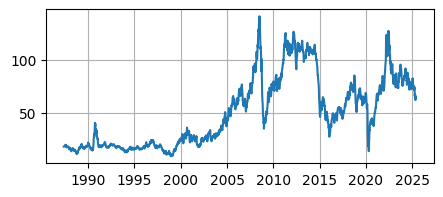

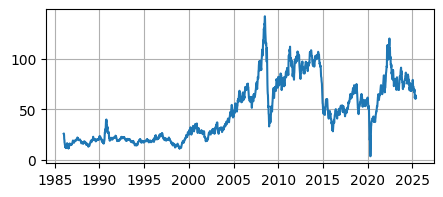

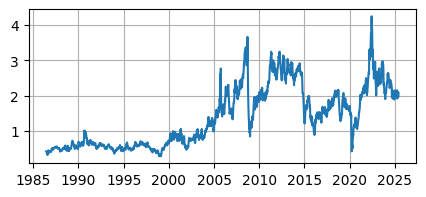

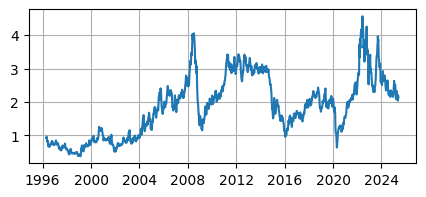

In [12]:
#*#*#*#**##* Weekly Europe Brent Spot Price FOB (Dollars per Barrel) -------- URL FOR DATA INFO https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RBRTE&f=W

url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=RBRTE&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)

df_brent = pd.DataFrame(jsonxx['response']['data'])
df_brent['value'] = pd.to_numeric(df_brent['value'], errors='coerce')
df_brent['date'] = pd.to_datetime(df_brent['period'])
df_brent=df_brent.set_index('date')

plt.figure(figsize=(5,2)) 
plt.plot(df_brent['value'])
plt.grid(True)
plt.show()

#*#*#*#**##* Weekly Cushing, OK WTI Spot Price FOB (Dollars per Barrel) -------- URL FOR DATA INFO https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=RWTC&f=W

url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=RWTC&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)

df_wti = pd.DataFrame(jsonxx['response']['data'])
df_wti['value'] = pd.to_numeric(df_wti['value'], errors='coerce')
df_wti['date'] = pd.to_datetime(df_wti['period'])
df_wti=df_wti.set_index('date')

plt.figure(figsize=(5,2))
plt.plot(df_wti['value'])
plt.grid(True)
plt.show()

#*#**#*#*#* Weekly U.S. Gulf Coast Conventional Gasoline Regular Spot Price FOB (Dollars per Gallon) ---- https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=EER_EPMRU_PF4_RGC_DPG&f=W

url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=EER_EPMRU_PF4_RGC_DPG&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)

df_gasoline = pd.DataFrame(jsonxx['response']['data'])
df_gasoline['value'] = pd.to_numeric(df_gasoline['value'], errors='coerce')
df_gasoline['date'] = pd.to_datetime(df_gasoline['period'])
df_gasoline=df_gasoline.set_index('date')

plt.figure(figsize=(5,2))
plt.plot(df_gasoline['value'])
plt.grid(True)
plt.show()

# #*#**#*#*#* Weekly U.S. Gulf Coast Ultra-Low Sulfur No 2 Diesel Spot Price (Dollars per Gallon) ------   https://www.eia.gov/dnav/pet/hist/eer_epd2dxl0_pf4_rgc_dpgD.htm

# url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=EER_EPD2DXL0_PF4_RGC_DPG&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"

#*#**#*#*#* Weekly Los Angeles, CA Ultra-Low Sulfur CARB Diesel Spot Price (Dollars per Gallon) ------   https://www.eia.gov/dnav/pet/hist/LeafHandler.ashx?n=PET&s=EER_EPD2DC_PF4_Y05LA_DPG&f=W

url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=weekly&data[0]=value&facets[series][]=EER_EPD2DC_PF4_Y05LA_DPG&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)


df_diesel = pd.DataFrame(jsonxx['response']['data'])
df_diesel['value'] = pd.to_numeric(df_diesel['value'], errors='coerce')
df_diesel['date'] = pd.to_datetime(df_diesel['period'])
df_diesel=df_diesel.set_index('date')

plt.figure(figsize=(5,2))
plt.plot(df_diesel['value'])
plt.grid(True)
plt.show()


In [13]:

df_merge_diesel_gas = pd.merge(
    df_diesel[['value']].rename(columns={'value': 'diesel'}),
    df_gasoline[['value']].rename(columns={'value': 'gasoline'}),
    left_index=True,
    right_index=True,
    how='inner'
)

df_merge_diesel_gas_wti = pd.merge(
    df_merge_diesel_gas,
    df_wti[['value']].rename(columns={'value': 'wti'}),
    left_index=True,
    right_index=True,
    how='inner'
)

df_merge_diesel_gas_crude = pd.merge(
    df_merge_diesel_gas_wti,
    df_brent[['value']].rename(columns={'value': 'brent'}),
    left_index=True,
    right_index=True,
    how='inner'
)

df_merge_diesel_gas_crude.head()


# print(df_brent.index) #**##* cheeck that the dates match
# print(df_wti.index)
# print(df_diesel.index)

,diesel,gasoline,wti,brent
date,,,,
2025-05-30,2.137,1.986,61.82,64.74
2025-05-23,2.166,2.097,63.26,65.86
2025-05-16,2.198,2.068,63.94,65.54
2025-05-09,2.043,2.000,60.39,62.29
2025-05-02,2.063,1.959,60.99,63.50


In [14]:
def calculate_crack_spread(df_crude, df_gasoline, df_diesel, label="WTI"):
    
    df_gasoline_bbl = df_gasoline * 42 # Convert gasoline and diesel to dollars per barrel
    df_diesel_bbl = df_diesel * 42


    # Apply crack spread formula
    df_crack_spread = ((2 * df_gasoline_bbl) + df_diesel_bbl - (3 * df_crude)) / 3

    return df_crack_spread

wti_crack = calculate_crack_spread(df_crude = df_merge_diesel_gas_crude['wti'], df_gasoline = df_merge_diesel_gas_crude['gasoline'], df_diesel = df_merge_diesel_gas_crude['diesel'] , label="WTI")
brent_crack = calculate_crack_spread(df_crude = df_merge_diesel_gas_crude['brent'], df_gasoline = df_merge_diesel_gas_crude['gasoline'], df_diesel = df_merge_diesel_gas_crude['diesel'] , label="WTI")

df_wti_crack_321 = pd.DataFrame(wti_crack)
df_brent_crack_321 =  pd.DataFrame(brent_crack)


#*#*#*#*#* NOTE NOTE THESE ARE THE DESIRED DFS
df_wti_crack_321.rename(columns={0: 'value'}, inplace=True)  
df_brent_crack_321.rename(columns={0: 'value'}, inplace=True)
#*#*#*#*#* NOTE NOTE THESE ARE THE DESIRED DFS


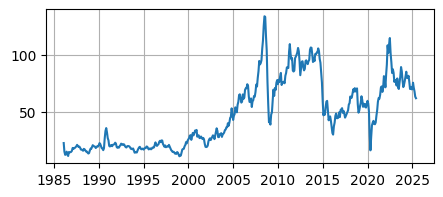

{"response":{"total":"473","dateFormat":"YYYY-MM","frequency":"monthly","data":[{"period":"2025-05","duoarea":"YCUOK","area-name":"NA","product":"EPCWTI","product-name":"WTI Crude Oil","process":"PF4","process-name":"Spot Price FOB","series":"RWTC","series-description":"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)","value":"62.17","units":"$\/BBL"},{"period":"2025-04","duoarea":"YCUOK","area-name":"NA","product":"EPCWTI","product-name":"WTI Crude Oil","process":"PF4","process-name":"Spot Price FOB","series":"RWTC","series-description":"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)","value":"63.54","units":"$\/BBL"},{"period":"2025-03","duoarea":"YCUOK","area-name":"NA","product":"EPCWTI","product-name":"WTI Crude Oil","process":"PF4","process-name":"Spot Price FOB","series":"RWTC","series-description":"Cushing, OK WTI Spot Price FOB (Dollars per Barrel)","value":"68.24","units":"$\/BBL"},{"period":"2025-02","duoarea":"YCUOK","area-name":"NA","product":"EPCWTI","product-nam

In [15]:
###### WTI DATA #############

url = f"https://api.eia.gov/v2/petroleum/pri/spt/data/?api_key=RPdbTZA0nXhnQ2XuVcf03eTL4mXyVGJpgyui8Ash&frequency=monthly&data[0]=value&facets[series][]=RWTC&sort[0][column]=period&sort[0][direction]=desc&offset=0&length=5000"
response = requests.get(url)

jsonxx = json.loads(response.text)

df_wti_monthly_y = pd.DataFrame(jsonxx['response']['data'])
df_wti_monthly_y['value'] = pd.to_numeric(df_wti_monthly_y['value'], errors='coerce')
df_wti_monthly_y['date'] = pd.to_datetime(df_wti_monthly_y['period']) + pd.offsets.MonthEnd(0)
df_wti_monthly_y=df_wti_monthly_y.set_index('date')

plt.figure(figsize=(5,2))
plt.plot(df_wti_monthly_y['value'])
plt.grid(True)
plt.show()

print(response.text)


In [16]:
'''
df_US_energy_PPI
df_EU28_PPI
df_US_PMI
df_oecd_pet_stocks
df_oecd_stocks_oilSPR_wkly
df_oecd_stocks_oilnonSPR_wkly
df_spec
df_wklyUSdollarIndex
df_futures_3m_copper_weekly
df_wti_crack_321
df_brent_crack_321
'''

import pandas as pd

# Simulate example DataFrames
# Note: In practice, replace these with actual loaded DataFrames from your session

dfs = { #df_wti_monthly_y_short_EXPLANATORY,df_wti_monthly_y_short
    "df_US_energy_PPI": df_US_energy_PPI,
    "df_EU28_PPI": df_EU28_PPI,
    "df_US_PMI": df_US_PMI,
    "df_oecd_pet_stocks": df_oecd_pet_stocks,
    "df_oecd_stocks_oilSPR_wkly": df_oecd_stocks_oilSPR_wkly,
    "df_oecd_stocks_oilnonSPR_wkly": df_oecd_stocks_oilnonSPR_wkly,
    "df_spec": df_spec,
    "df_wklyUSdollarIndex": df_wklyUSdollarIndex,
    "df_futures_3m_copper_weekly": df_futures_3m_copper_weekly,
    "df_wti_crack_321": df_wti_crack_321,
    "df_brent_crack_321": df_brent_crack_321,
}

# Analyze each DataFrame
summary_data = []

for name, df in dfs.items():

    start_date = df.index.min()
    end_date = df.index.max()

    # Counts
    n_nans = df.isna().sum().sum()
    n_empty = (df == '').sum().sum()
    n_dots = (df == '.').sum().sum()
    n_zeros = (df == 0).sum().sum()

    summary_data.append({
        "DataFrame": name,
        "Start Date": start_date,
        "End Date": end_date,
        "NaNs": n_nans,
        "Empty Strings": n_empty,
        "Dots ('.')": n_dots,
        "Zeros": n_zeros
    })

summary_df = pd.DataFrame(summary_data)

summary_df


# df_EU28_PPI ends in 2022, all other datasets are available till 2025 

## START - 2002-01-01 
## END - 2001-10-01


,DataFrame,Start Date,End Date,NaNs,Empty Strings,Dots ('.'),Zeros
0,df_US_energy_PPI,1974-01-31,2025-04-30,0,0,0,0
1,df_EU28_PPI,2000-01-31,2022-12-31,0,0,0,0
2,df_US_PMI,1987-11-30,2025-04-30,0,0,0,0
3,df_oecd_pet_stocks,1980-01-31,2025-02-28,1084,0,0,0
4,df_oecd_stocks_oilSPR_wkly,1982-08-20,2025-05-30,0,0,0,0
5,df_oecd_stocks_oilnonSPR_wkly,1982-08-20,2025-05-30,0,0,0,0
6,df_spec,1999-12-24,2025-05-23,0,0,0,0
7,df_wklyUSdollarIndex,1989-04-24,2025-05-27,0,0,0,0
8,df_futures_3m_copper_weekly,2001-10-22,2025-04-14,0,0,0,2276
9,df_wti_crack_321,1996-04-19,2025-05-30,0,0,0,0


In [17]:
df_oecd_pet_stocks.isna().sum()
(df_futures_3m_copper_weekly == 0).sum()

open           0
high           0
low            0
last           0
change         4
%chg           0
volume      1046
open int    1226
dtype: int64

/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_83625/2444010907.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs[name] = df.sort_index(ascending=True , inplace= True)
/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_83625/2444010907.py:51: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[target_col] = df[target_col].astype(float)
/var/folders/g_/x6nnyyc96zb627gqxngw5wgc0000gn/T/ipykernel_83625/2444010907.py:53: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_i

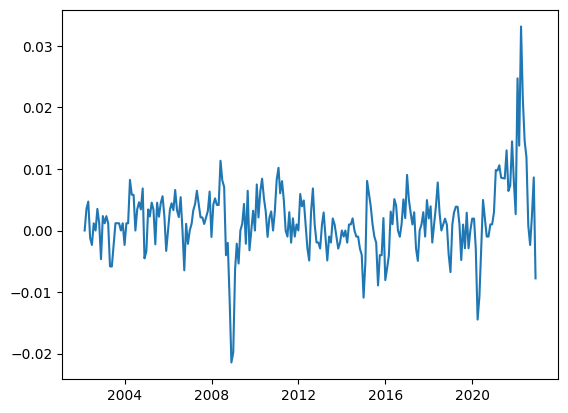

In [18]:
## START - 2002-01-01 
## END - 2022-12-01


start_date = '2002-01-01'
end_date = '2022-12-01'

df_US_energy_PPI_short = df_US_energy_PPI[(df_US_energy_PPI.index >= start_date) & (df_US_energy_PPI.index <= end_date)]
df_EU28_PPI_short = df_EU28_PPI[(df_EU28_PPI.index >= start_date) & (df_EU28_PPI.index <= end_date)]
df_US_PMI_short = df_US_PMI[(df_US_PMI.index >= start_date) & (df_US_PMI.index <= end_date)]
df_oecd_pet_stocks_short = df_oecd_pet_stocks[(df_oecd_pet_stocks.index >= start_date) & (df_oecd_pet_stocks.index <= end_date)]
df_oecd_stocks_oilSPR_wkly_short = df_oecd_stocks_oilSPR_wkly[(df_oecd_stocks_oilSPR_wkly.index >= start_date) & (df_oecd_stocks_oilSPR_wkly.index <= end_date)]
df_oecd_stocks_oilnonSPR_wkly_short = df_oecd_stocks_oilnonSPR_wkly[(df_oecd_stocks_oilnonSPR_wkly.index >= start_date) & (df_oecd_stocks_oilnonSPR_wkly.index <= end_date)]
df_spec_short = df_spec[(df_spec.index >= start_date) & (df_spec.index <= end_date)]
df_wklyUSdollarIndex_short = df_wklyUSdollarIndex[(df_wklyUSdollarIndex.index >= start_date) & (df_wklyUSdollarIndex.index <= end_date)]
df_futures_3m_copper_weekly_short = df_futures_3m_copper_weekly[(df_futures_3m_copper_weekly.index >= start_date) & (df_futures_3m_copper_weekly.index <= end_date)]
df_wti_crack_321_short = df_wti_crack_321[(df_wti_crack_321.index >= start_date) & (df_wti_crack_321.index <= end_date)]
df_brent_crack_321_short = df_brent_crack_321[(df_brent_crack_321.index >= start_date) & (df_brent_crack_321.index <= end_date)]

df_wti_monthly_y_short = df_wti_monthly_y[(df_wti_monthly_y.index >= '2002-06-01') & (df_wti_monthly_y.index <= end_date)] #**#*#*#*# set at a later start date !!!! *********



df_wti_monthly_y_short_EXPLANATORY = df_wti_monthly_y[(df_wti_monthly_y.index >= start_date) & (df_wti_monthly_y.index <= end_date)] #**#*#*#*# set at a later start date !!!! *********

# Dictionary of DataFrames
dfs = { "df_wti_monthly_y_short_EXPLANATORY" : df_wti_monthly_y_short_EXPLANATORY , "df_wti_monthly_y_short" : df_wti_monthly_y_short , "df_US_energy_PPI_short": df_US_energy_PPI_short,"df_EU28_PPI_short": df_EU28_PPI_short,"df_US_PMI_short": df_US_PMI_short,"df_oecd_pet_stocks_short": df_oecd_pet_stocks_short,"df_oecd_stocks_oilSPR_wkly_short": df_oecd_stocks_oilSPR_wkly_short,"df_oecd_stocks_oilnonSPR_wkly_short": df_oecd_stocks_oilnonSPR_wkly_short,"df_spec_short": df_spec_short,"df_wklyUSdollarIndex_short": df_wklyUSdollarIndex_short,"df_futures_3m_copper_weekly_short": df_futures_3m_copper_weekly_short,"df_wti_crack_321_short": df_wti_crack_321_short,"df_brent_crack_321_short": df_brent_crack_321_short,"df_wti_monthly_y_short": df_wti_monthly_y_short
}

for name, df in dfs.items():
    dfs[name] = df.sort_index(ascending=True , inplace= True)  




#*#*#* CALC RETURN RATE  #*#*#* clacl RETURN RATE  #*#*#* clacl RETURN RATE 

dfs = [
    df_wti_monthly_y_short_EXPLANATORY,df_wti_monthly_y_short,df_US_energy_PPI_short,df_EU28_PPI_short,df_US_PMI_short,df_oecd_pet_stocks_short,df_oecd_stocks_oilSPR_wkly_short,df_oecd_stocks_oilnonSPR_wkly_short,df_spec_short,df_wklyUSdollarIndex_short,df_futures_3m_copper_weekly_short,df_wti_crack_321_short,df_brent_crack_321_short]

names = [
    "df_wti_monthly_y_short_EXPLANATORY","df_wti_monthly_y_short","df_US_energy_PPI_short","df_EU28_PPI_short","df_US_PMI_short","df_oecd_pet_stocks_short","df_oecd_stocks_oilSPR_wkly_short","df_oecd_stocks_oilnonSPR_wkly_short","df_spec_short","df_wklyUSdollarIndex_short","df_futures_3m_copper_weekly_short","df_wti_crack_321_short","df_brent_crack_321_short"
]

for i, (df, name) in enumerate(zip(dfs, names)): #**#*#*# adds a new col for return rate 


    target_col = 'value' if 'value' in df.columns else 'close' if 'close' in df.columns else 'open' if 'open' in df.columns else None

    if target_col:
        df[target_col] = df[target_col].astype(float)
        ret_col = f"{target_col}_retRate"
        df[ret_col] = df[target_col].pct_change()

    else:
        print(f"Skipped {name} — no 'value', 'close', or 'open' column found.")

df_wti_monthly_y_short_EXPLANATORY.columns


#*#*#* CALC RETURN RATE  #*#*#* clacl RETURN RATE  #*#*#* clacl RETURN RATE  

plt.plot(df_EU28_PPI_short["value_retRate"])


In [19]:

#*#**#*#*#* # Transformations

dfs = [
    df_wti_monthly_y_short_EXPLANATORY,df_wti_monthly_y_short,df_US_energy_PPI_short,df_EU28_PPI_short,df_US_PMI_short,df_oecd_pet_stocks_short,df_oecd_stocks_oilSPR_wkly_short,df_oecd_stocks_oilnonSPR_wkly_short,df_spec_short,df_wklyUSdollarIndex_short,df_futures_3m_copper_weekly_short,df_wti_crack_321_short,df_brent_crack_321_short]

names = [
    "df_wti_monthly_y_short_EXPLANATORY","df_wti_monthly_y_short","df_US_energy_PPI_short","df_EU28_PPI_short","df_US_PMI_short","df_oecd_pet_stocks_short","df_oecd_stocks_oilSPR_wkly_short","df_oecd_stocks_oilnonSPR_wkly_short","df_spec_short","df_wklyUSdollarIndex_short","df_futures_3m_copper_weekly_short","df_wti_crack_321_short","df_brent_crack_321_short"
]


column_info = {name: df.columns.tolist() for name, df in zip(names, dfs)}

# for df, name in zip(dfs, names):
    
#     target_col = 'value' if 'value' in df.columns else 'close' if 'close' in df.columns else 'open' if 'open' in df.columns else None

#     df[target_col] = df[target_col].astype(float)



#*#*#*# #*#*#*# #*#*#*# min max scale

from sklearn.preprocessing import MinMaxScaler


scaler = MinMaxScaler()

for df, name in zip(dfs, names):
    df_scaled = df.copy()
    
    target_col = 'value' if 'value' in df_scaled.columns else 'close' if 'close' in df_scaled.columns else 'open' if 'open' in df_scaled.columns else None
    
    if target_col:
        df_scaled[target_col] = scaler.fit_transform(df_scaled[[target_col]])
        globals()[name] = df_scaled  
    else:
        print(f"Skipped {name} — no 'value' or 'close' column found.")

df_wti_monthly_y_short_EXPLANATORY["value"]



#*#*#*# #*#*#*# #*#*#*#min max scale



# scalers = {}

# for df, name in zip(dfs, names):
#     df_scaled = df.copy()

#     target_col = 'value' if 'value' in df_scaled.columns else \
#                  'close' if 'close' in df_scaled.columns else \
#                  'open' if 'open' in df_scaled.columns else None
    
#     if target_col:
#         scaler = MinMaxScaler()
#         df_scaled[target_col] = scaler.fit_transform(df_scaled[[target_col]])
#         scalers[name] = scaler         # 🔑 store the scaler per dataset
#         globals()[name] = df_scaled
#     else:
#         print(f"Skipped {name} — no 'value' or 'close' column found.")



date
2002-01-31    0.027018
2002-02-28    0.035541
2002-03-31    0.068013
2002-04-30    0.082076
2002-05-31    0.089406
                ...   
2022-07-31    0.725049
2022-08-31    0.657291
2022-09-30    0.577090
2022-10-31    0.605131
2022-11-30    0.578028
Name: value, Length: 251, dtype: float64

In [20]:
# print("df_oecd_stocks_oilSPR_wkly_short:", df_oecd_stocks_oilSPR_wkly_short.index[0:5])
# print("df_oecd_stocks_oilnonSPR_wkly_short:", df_oecd_stocks_oilnonSPR_wkly_short.index[0:5])
# print("df_spec_short:", df_spec_short.index[0:5]) #*#* 3 days ahead
# print("df_wklyUSdollarIndex_short:", df_wklyUSdollarIndex_short.index[0:5]) #*#* 3 days ahead
# print("df_futures_3m_copper_weekly_short:", df_futures_3m_copper_weekly_short.index[::-1][0:5]) #*#* 3 days ahead
# print("df_wti_crack_321_short:", df_wti_crack_321_short.index[0:5])
# print("df_brent_crack_321_short:", df_brent_crack_321_short.index[0:5])

# print('-------------------') #### Monthly below 

# print("df_US_energy_PPI_short:", df_US_energy_PPI_short.index[0:5])
# print("df_EU28_PPI_short:", df_EU28_PPI_short.index[0:5])
# print("df_US_PMI_short:", df_US_PMI_short.index[0:5])
# print("df_oecd_pet_stocks_short:", df_oecd_pet_stocks_short.index[0:5])
# print("WTI predictor:", df_wti_monthly_y_short.index[0:5])




In [21]:

# dfs = {
#     "df_wti_monthly_y_short":df_wti_monthly_y_short,
#     "df_US_energy_PPI": df_US_energy_PPI_short,
#     "df_EU28_PPI": df_EU28_PPI_short,
#     "df_US_PMI": df_US_PMI_short,
#     "df_oecd_pet_stocks": df_oecd_pet_stocks_short,
#     "df_oecd_stocks_oilSPR_wkly": df_oecd_stocks_oilSPR_wkly_short,
#     "df_oecd_stocks_oilnonSPR_wkly": df_oecd_stocks_oilnonSPR_wkly_short,
#     "df_spec": df_spec_short,
#     "df_wklyUSdollarIndex": df_wklyUSdollarIndex_short,
#     "df_futures_3m_copper_weekly": df_futures_3m_copper_weekly_short,
#     "df_wti_crack_321": df_wti_crack_321_short,
#     "df_brent_crack_321": df_brent_crack_321_short,
    
# }

# # Analyze each DataFrame
# summary_data = []

# for name, df in dfs.items():

#     start_date = df.index.min()
#     end_date = df.index.max()

#     summary_data.append({
#         "DataFrame": name,
#         "Start Date": start_date,
#         "End Date": end_date,

#     })

# summary_df = pd.DataFrame(summary_data)

# summary_df


# # df_EU28_PPI ends in 2022, all other datasets are available till 2025 

# ## START - 2002-01-01 
# ## END - 2001-10-01


In [22]:
# #**#*# check commpn dates 
# dfs = {
#     "df_wti_monthly_y_short": df_wti_monthly_y_short,
#     "df_US_energy_PPI": df_US_energy_PPI_short,
#     "df_EU28_PPI": df_EU28_PPI_short,
#     "df_US_PMI": df_US_PMI_short,
#     "df_oecd_pet_stocks": df_oecd_pet_stocks_short,
# }

# for df in dfs.values():
#     df.index = pd.to_datetime(df.index)

# from itertools import combinations

# results = []

# for (name1, df1), (name2, df2) in combinations(dfs.items(), 2):
#     total1 = len(df1)
#     total2 = len(df2)
#     common_dates = df1.index.intersection(df2.index)
#     results.append({
#         "Pair": f"{name1} vs {name2}",
#         "Rows in 1": total1,
#         "Rows in 2": total2,
#         "Common Dates": len(common_dates)
#     })


# results_df = pd.DataFrame(results)
# print(results_df)


In [23]:
# 5	df_oecd_stocks_oilSPR_wkly	2002-01-04	2022-11-25
# 6	df_oecd_stocks_oilnonSPR_wkly	2002-01-04	2022-11-25
# 7	df_spec	2002-01-11	2022-11-28  ----- NOTE the data here is irregular slightly
# 8	df_wklyUSdollarIndex	2002-01-07	2022-11-28
# 9	df_futures_3m_copper_weekly	2002-01-07	2022-11-28
# 10	df_wti_crack_321	2002-01-04	2022-11-25
# 11	df_brent_crack_321	2002-01-04	2022-11-25

In [24]:
def pair_check(df1,df2):
     return print(len(df1)) , print(len(df2)) , print('common dates',len(df1.index.intersection(df2.index))) 

pair_check(df_oecd_pet_stocks_short, df_oecd_pet_stocks_short)

# print(df_wklyUSdollarIndex_short.index)
# print(df_spec_short.index) #*#**## the data here is irregular slightly 

# pair_check(df_wklyUSdollarIndex_short, df_futures_3m_copper_weekly)

# print('common dates',df1.index.intersection(df2.index)) 



251
251
common dates 251


(None, None, None)

In [25]:
#*#**#                          Make dataset for LSTM (CREATING FUNCTIONS FOR LAGGED VALUES )

#*#*#*# DELETE -- ONLY FOR TESTING
# # WTI_dates[::-1]

# import pandas as pd

# WTI_dates = df_wti_monthly_y_short.index.to_numpy()

# for i in WTI_dates[::-1]:  # reverse loop if needed
#     target_date = pd.Timestamp(i) - pd.DateOffset(months=1)
    
#     # Find closest date in Brent index that is <= target_date
#     possible_dates = df_brent_crack_321_short.index[df_brent_crack_321_short.index <= target_date]
    
#     if not possible_dates.empty:
#         closest_date = possible_dates.max()
#         print(f"Target: {target_date.date()} → Closest Match: {closest_date.date()}")
#     else:
#         print(f"No match found before {target_date.date()}")

        
# from pandas.tseries.offsets import DateOffset

# WTI_dates = df_wti_monthly_y_short.index

# list  = []
# for wti_date in WTI_dates[::-1]:
    
#     valid_past_dates = df_brent_crack_321_short.index[df_brent_crack_321_short.index < (wti_date - DateOffset(months=1))]
#     last_4 = valid_past_dates[-5:][::-1]

#     values  = [ df_brent_crack_321_short.reset_index()["value"][df_brent_crack_321_short.reset_index()['date'] == i].to_numpy()[0] for i in last_4 ]
#     values_dict = {f"t_minus{idx+1}": val for idx, val in enumerate(values)}

#     print(values_dict)
#     print(f"WTI Date: {wti_date.date()} → Past indicator dates: {[d.date() for d in last_4]}")
#*#*#*# DELETE -- ONLY FOR TESTING


from pandas.tseries.offsets import DateOffset

def lagged_vals_generator(df_crude_short, df_explainer_short,str_name, lag , use_ret_rate = True):

    WTI_dates = df_crude_short.index

    values_dict_list = []
    dates_dict_list = []
    

    if use_ret_rate is True : 

        target_col = 'value_retRate' if 'value_retRate' in df_explainer_short.columns else 'close_retRate' if 'close_retRate' in df_explainer_short.columns else 'open_retRate' if 'open_retRate' in df_explainer_short.columns else None
        col = "value_retRate"
    else :
        
        target_col = 'value' if 'value' in df_explainer_short.columns else 'close' if 'close' in df_explainer_short.columns else 'open' if 'open' in df_explainer_short.columns else None
        col = "value"


    for wti_date in WTI_dates[::-1] :

        wti_value = df_crude_short.reset_index()[col][df_crude_short.reset_index()['date'] == wti_date].to_numpy()[0]
        valid_past_dates = df_explainer_short.index[df_explainer_short.index < (wti_date - DateOffset(months=1))]
        last_4 = valid_past_dates[-lag:][::-1]

        values  = [ df_explainer_short.reset_index()[target_col][df_explainer_short.reset_index()['date'] == i].to_numpy()[0] for i in last_4 ]

        # #*#*#*#*#*#* uncomment --- ONLY FOR TESTING
        # values_dict = {f"t_minus{idx+1}_{str_name}": val for idx, val in enumerate(values)} 
        # values_dict.update({"wti_pred_date":wti_date}) ; values_dict.update({"wti_value":wti_value})

        # dates_dict = {f"t_minus{idx+1}_{str_name}_timestamp": date for idx, date in enumerate(last_4)} 
        # dates_dict.update({"wti_pred_date_timestamp":wti_date}) ; dates_dict.update({"wti_value":wti_value})
        # print(values_dict)
        # print(dates_dict)
        # #*#*#*#*#*#* uncomment --- ONLY FOR TESTING

    ##**#*#*#*#**##*#* Actual ##**#*#*#*#**##*#* Actual ##**#*#*#*#**##*#* Actual
        values_dict = {f"t_minus{idx+1}_{str_name}": val for idx, val in enumerate(values)} 
        values_dict.update({"wti_pred_date":wti_date}) ; values_dict.update({"wti_value":wti_value})
        values_dict_list.append(values_dict)

        dates_dict = {f"t_minus{idx+1}_{str_name}_timestamp": date for idx, date in enumerate(last_4)} 
        dates_dict.update({"wti_pred_date_timestamp":wti_date}) ; dates_dict.update({"wti_value":wti_value})
        dates_dict_list.append(dates_dict)

    df_values = pd.DataFrame(values_dict_list)[::-1]
    df_dates = pd.DataFrame(dates_dict_list)[::-1]
    
    return df_values , df_dates

    ##**#*#*#*#**##*#* Actual ##**#*#*#*#**##*#* Actual ##**#*#*#*#**##*#* Actual


lagged_vals_generator(df_crude_short = df_wti_monthly_y_short, df_explainer_short = df_brent_crack_321_short,str_name = "EU28_PPI", lag= 4)[0]

# [40.424, 32.888, 43.056000000000004, 45.564, 38.15999999999999]
# WTI Date: 2022-11-30 → Past Brent Crack Dates: [datetime.date(2022, 10, 28), datetime.date(2022, 10, 21), datetime.date(2022, 10, 14), datetime.date(2022, 10, 7), datetime.date(2022, 9, 30)]
#TEST
# df_brent_crack_321_short[df_brent_crack_321_short['value'] == 38.15999999999999 ]


lagged_vals_generator(df_wti_monthly_y_short, df_futures_3m_copper_weekly_short, "futures_3m_copper_weekly", 4 , use_ret_rate=True)[0]

,t_minus1_futures_3m_copper_weekly,t_minus2_futures_3m_copper_weekly,t_minus3_futures_3m_copper_weekly,t_minus4_futures_3m_copper_weekly,wti_pred_date,wti_value
245,0.020189,-0.014303,0.024857,-0.038603,2002-06-30,NaN
244,-0.015015,-0.014793,-0.001772,0.047001,2002-07-31,0.056818
243,-0.033438,-0.024615,-0.021084,-0.016005,2002-08-31,0.052651
242,0.018868,-0.004695,-0.000670,-0.026110,2002-09-30,0.044734
241,-0.021696,0.006618,-0.001322,0.000661,2002-10-31,-0.027647
...,...,...,...,...,...,...
4,-0.068120,-0.040907,-0.036485,0.024211,2022-07-31,-0.115117
3,0.026946,-0.066615,-0.045590,-0.037952,2022-08-31,-0.078233
2,-0.008305,-0.004320,0.030330,-0.004620,2022-09-30,-0.100459
1,-0.049427,-0.000191,0.043389,-0.059375,2022-10-31,0.039046


In [26]:



lag = 4

df_lagged_US_energy_PPI = lagged_vals_generator(df_wti_monthly_y_short, df_US_energy_PPI_short, "US_energy_PPI", lag)
df_lagged_EU28_PPI = lagged_vals_generator(df_wti_monthly_y_short, df_EU28_PPI_short, "EU28_PPI", lag)
df_lagged_US_PMI = lagged_vals_generator(df_wti_monthly_y_short, df_US_PMI_short, "US_PMI", lag)
df_lagged_oecd_pet_stocks = lagged_vals_generator(df_wti_monthly_y_short, df_oecd_pet_stocks_short, "oecd_pet_stocks", lag)
df_lagged_oecd_stocks_oilSPR_wkly = lagged_vals_generator(df_wti_monthly_y_short, df_oecd_stocks_oilSPR_wkly_short, "oecd_stocks_oilSPR_wkly", lag)
df_lagged_oecd_stocks_oilnonSPR_wkly = lagged_vals_generator(df_wti_monthly_y_short, df_oecd_stocks_oilnonSPR_wkly_short, "oecd_stocks_oilnonSPR_wkly", lag)
df_lagged_spec = lagged_vals_generator(df_wti_monthly_y_short, df_spec_short, "spec", lag)
df_lagged_wklyUSdollarIndex = lagged_vals_generator(df_wti_monthly_y_short, df_wklyUSdollarIndex_short, "wklyUSdollarIndex", lag)
df_lagged_futures_3m_copper_weekly = lagged_vals_generator(df_wti_monthly_y_short, df_futures_3m_copper_weekly_short, "futures_3m_copper_weekly", lag)
df_lagged_wti_crack_321 = lagged_vals_generator(df_wti_monthly_y_short, df_wti_crack_321_short, "wti_crack_321", lag)
df_lagged_brent_crack_321 = lagged_vals_generator(df_wti_monthly_y_short, df_brent_crack_321_short, "brent_crack_321", lag)


df_lagged_wti_monthly_y_short_EXPLANATORY = lagged_vals_generator(df_wti_monthly_y_short, df_wti_monthly_y_short_EXPLANATORY, "wti_monthly_y_short", lag)


In [27]:
df_lagged_wti_monthly_y_short_EXPLANATORY[0]

,t_minus1_wti_monthly_y_short,t_minus2_wti_monthly_y_short,t_minus3_wti_monthly_y_short,t_minus4_wti_monthly_y_short,wti_pred_date,wti_value
245,0.067265,0.183880,0.050710,NaN,2002-06-30,NaN
244,0.032850,0.067265,0.183880,0.050710,2002-07-31,0.056818
243,-0.056213,0.032850,0.067265,0.183880,2002-08-31,0.052651
242,0.056818,-0.056213,0.032850,0.067265,2002-09-30,0.044734
241,0.052651,0.056818,-0.056213,0.032850,2002-10-31,-0.027647
...,...,...,...,...,...,...
4,0.076341,-0.061935,0.183981,0.101178,2022-07-31,-0.115117
3,0.048288,0.076341,-0.061935,0.183981,2022-08-31,-0.078233
2,-0.115117,0.048288,0.076341,-0.061935,2022-09-30,-0.100459
1,-0.078233,-0.115117,0.048288,0.076341,2022-10-31,0.039046


In [28]:
lagged_dfs = [
      df_lagged_wti_monthly_y_short_EXPLANATORY         ,df_lagged_US_energy_PPI,df_lagged_EU28_PPI,df_lagged_US_PMI,df_lagged_oecd_pet_stocks,df_lagged_oecd_stocks_oilSPR_wkly,df_lagged_oecd_stocks_oilnonSPR_wkly,df_lagged_spec,df_lagged_wklyUSdollarIndex,df_lagged_futures_3m_copper_weekly,df_lagged_wti_crack_321,  df_lagged_brent_crack_321
]


df_lagged_US_energy_PPI[0]

from functools import reduce

lagged_dfs = [
    df_lagged_US_energy_PPI[0],
    df_lagged_EU28_PPI[0],
    df_lagged_US_PMI[0],
    df_lagged_oecd_pet_stocks[0],
    df_lagged_oecd_stocks_oilSPR_wkly[0],
    df_lagged_oecd_stocks_oilnonSPR_wkly[0],
    df_lagged_spec[0],
    df_lagged_wklyUSdollarIndex[0],
    df_lagged_futures_3m_copper_weekly[0],
    df_lagged_wti_crack_321[0],
    df_lagged_brent_crack_321[0]      ,df_lagged_wti_monthly_y_short_EXPLANATORY[0] ] 

df_merged = lagged_dfs[0]

for df in lagged_dfs[1:]:
    df.drop(columns = 'wti_value', inplace = True) #**#*# need ot srop the wti_value col in all but one df or else err

for df in lagged_dfs[1:]:
    df_merged = pd.merge(df_merged, df, on='wti_pred_date', how='inner')



In [29]:
print(df_merged.columns)
df_merged

df_merged = df_merged[2::].reset_index() #**#*# first two vals are nans  
df_merged 

Index(['t_minus1_US_energy_PPI', 't_minus2_US_energy_PPI',
       't_minus3_US_energy_PPI', 't_minus4_US_energy_PPI', 'wti_pred_date',
       'wti_value', 't_minus1_EU28_PPI', 't_minus2_EU28_PPI',
       't_minus3_EU28_PPI', 't_minus4_EU28_PPI', 't_minus1_US_PMI',
       't_minus2_US_PMI', 't_minus3_US_PMI', 't_minus4_US_PMI',
       't_minus1_oecd_pet_stocks', 't_minus2_oecd_pet_stocks',
       't_minus3_oecd_pet_stocks', 't_minus4_oecd_pet_stocks',
       't_minus1_oecd_stocks_oilSPR_wkly', 't_minus2_oecd_stocks_oilSPR_wkly',
       't_minus3_oecd_stocks_oilSPR_wkly', 't_minus4_oecd_stocks_oilSPR_wkly',
       't_minus1_oecd_stocks_oilnonSPR_wkly',
       't_minus2_oecd_stocks_oilnonSPR_wkly',
       't_minus3_oecd_stocks_oilnonSPR_wkly',
       't_minus4_oecd_stocks_oilnonSPR_wkly', 't_minus1_spec', 't_minus2_spec',
       't_minus3_spec', 't_minus4_spec', 't_minus1_wklyUSdollarIndex',
       't_minus2_wklyUSdollarIndex', 't_minus3_wklyUSdollarIndex',
       't_minus4_wklyUSdollarIn

,index,t_minus1_US_energy_PPI,t_minus2_US_energy_PPI,t_minus3_US_energy_PPI,t_minus4_US_energy_PPI,wti_pred_date,wti_value,t_minus1_EU28_PPI,t_minus2_EU28_PPI,t_minus3_EU28_PPI,...,t_minus3_wti_crack_321,t_minus4_wti_crack_321,t_minus1_brent_crack_321,t_minus2_brent_crack_321,t_minus3_brent_crack_321,t_minus4_brent_crack_321,t_minus1_wti_monthly_y_short,t_minus2_wti_monthly_y_short,t_minus3_wti_monthly_y_short,t_minus4_wti_monthly_y_short
0,2,0.003432,-0.011312,0.030303,0.034982,2002-08-31,0.052651,-0.002342,-0.001170,0.004700,...,0.032857,-0.163680,-0.056348,0.073615,0.020074,-0.157004,-0.056213,0.032850,0.067265,0.183880
1,3,0.009122,0.003432,-0.011312,0.030303,2002-09-30,0.044734,0.001174,-0.002342,-0.001170,...,0.012680,0.046682,-0.018834,-0.061204,0.020472,0.036691,0.056818,-0.056213,0.032850,0.067265
2,4,0.011299,0.009122,0.003432,-0.011312,2002-10-31,-0.027647,0.000000,0.001174,-0.002342,...,-0.025010,0.091258,0.021739,-0.120923,-0.039253,0.053000,0.052651,0.056818,-0.056213,0.032850
3,5,0.017877,0.011299,0.009122,0.003432,2002-11-30,-0.086338,0.003517,0.000000,0.001174,...,-0.000360,0.389780,-0.148481,0.219982,-0.023451,0.267058,0.044734,0.052651,0.056818,-0.056213
4,6,0.028540,0.017877,0.011299,0.009122,2002-12-31,0.118027,0.001168,0.003517,0.000000,...,-0.268731,-0.025633,-0.283392,-0.151679,-0.130797,0.004186,-0.027647,0.044734,0.052651,0.056818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,241,0.061358,-0.006403,0.056289,0.036945,2022-07-31,-0.115117,0.014504,0.021399,0.033163,...,-0.010851,0.233023,0.083059,-0.137638,0.001514,0.180619,0.076341,-0.061935,0.183981,0.101178
240,242,0.093301,0.061358,-0.006403,0.056289,2022-08-31,-0.078233,0.011914,0.014504,0.021399,...,-0.026481,-0.211947,0.386946,-0.274585,-0.021445,-0.275980,0.048288,0.076341,-0.061935,0.183981
241,243,-0.094916,0.093301,0.061358,-0.006403,2022-09-30,-0.100459,0.000785,0.011914,0.014504,...,0.060869,-0.334705,0.149111,0.519146,0.012860,-0.398822,-0.115117,0.048288,0.076341,-0.061935
242,244,-0.055063,-0.094916,0.093301,0.061358,2022-10-31,0.039046,-0.002353,0.000785,0.011914,...,-0.039331,-0.068890,0.119900,-0.035719,-0.064388,-0.081101,-0.078233,-0.115117,0.048288,0.076341


In [30]:
#**#*#DATA for next steps 
tensor_formatted_data = []
predictor_data_wti_vals = df_merged["wti_value"].to_numpy()
prediction_date = df_merged["wti_pred_date"].to_numpy()



t_minus_1_cols = [col for col in df_merged.columns if 't_minus1_' in col]
t_minus_2_cols = [col for col in df_merged.columns if 't_minus2_' in col]
t_minus_3_cols = [col for col in df_merged.columns if 't_minus3_' in col]
t_minus_4_cols = [col for col in df_merged.columns if 't_minus4_' in col]

t_minus_1_cols.sort()
t_minus_2_cols.sort()
t_minus_3_cols.sort()
t_minus_4_cols.sort()

for i in range(len(df_merged)):
    t_minus_1 = df_merged.loc[i, t_minus_1_cols].tolist()
    t_minus_2 = df_merged.loc[i, t_minus_2_cols].tolist()
    t_minus_3 = df_merged.loc[i, t_minus_3_cols].tolist()
    t_minus_4 = df_merged.loc[i, t_minus_4_cols].tolist()

    sample = [t_minus_4 ,t_minus_3 , t_minus_2 , t_minus_1 ]
    tensor_formatted_data.append(sample)

tensor_formatted_data = np.array(tensor_formatted_data) #*#*#* convert to np to get the rifght shape, lists do not have the shape method 


print(len(tensor_formatted_data))
print(len(predictor_data_wti_vals))
print(len(prediction_date))

244
244
244


In [31]:
tensor_formatted_data.shape

(244, 4, 12)

In [32]:
cutoff = .85
intCutoff = int(cutoff*len(tensor_formatted_data))

X_train = tensor_formatted_data[:intCutoff]
Y_train = predictor_data_wti_vals[:intCutoff]

Y_train_dates = prediction_date[:intCutoff]



X_test = tensor_formatted_data[intCutoff:]
Y_test = predictor_data_wti_vals[intCutoff:]

Y_test_dates = prediction_date[intCutoff:]

X_train.shape , Y_train.shape , X_test.shape , Y_test.shape

((207, 4, 12), (207,), (37, 4, 12), (37,))

In [33]:
import torch

device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(device)


X_train = torch.tensor(X_train).float()
Y_train = torch.tensor(Y_train).float()
X_test = torch.tensor(X_test).float()
Y_test = torch.tensor(Y_test).float()

X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

cpu


(torch.Size([207, 4, 12]),
 torch.Size([37, 4, 12]),
 torch.Size([207]),
 torch.Size([37]))

In [34]:
X_train

tensor([[[ 0.0035,  0.0335,  0.0350,  ..., -0.0165, -0.1637,  0.1839],
         [ 0.0047,  0.0000,  0.0303,  ..., -0.0173,  0.0329,  0.0673],
         [-0.0012,  0.0134, -0.0113,  ...,  0.0245,  0.0493,  0.0328],
         [-0.0023,  0.0094,  0.0034,  ...,  0.0006, -0.0400, -0.0562]],

        [[ 0.0047,  0.0000,  0.0303,  ...,  0.0144,  0.0467,  0.0673],
         [-0.0012,  0.0134, -0.0113,  ..., -0.0138,  0.0127,  0.0328],
         [-0.0023,  0.0094,  0.0034,  ...,  0.0117, -0.2569, -0.0562],
         [ 0.0012, -0.0634,  0.0091,  ..., -0.0092, -0.1551,  0.0568]],

        [[-0.0012,  0.0134, -0.0113,  ..., -0.0013,  0.0913,  0.0328],
         [-0.0023,  0.0094,  0.0034,  ...,  0.0114, -0.0250, -0.0562],
         [ 0.0012, -0.0634,  0.0091,  ..., -0.0049, -0.1451,  0.0568],
         [ 0.0000,  0.0020,  0.0113,  ...,  0.0000, -0.0642,  0.0527]],

        ...,

        [[ 0.0039,  0.0203,  0.0305,  ..., -0.0045,  0.0582,  0.0582],
         [ 0.0039, -0.0452,  0.0447,  ...,  0.0035,  0.02

In [35]:
from torch.utils.data import Dataset

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_dataset = TimeSeriesDataset(X_train, Y_train)
test_dataset = TimeSeriesDataset(X_test, Y_test)



In [36]:
train_dataset[0]

(tensor([[ 3.5377e-03,  3.3531e-02,  3.4982e-02, -1.5700e-01, -1.6005e-02,
          -4.5034e-03,  1.7848e-03, -1.4454e-02,  1.6931e-01, -1.6532e-02,
          -1.6368e-01,  1.8388e-01],
         [ 4.7004e-03,  0.0000e+00,  3.0303e-02,  2.0074e-02, -2.1084e-02,
           1.6048e-04,  1.8753e-03, -6.5921e-03,  9.5023e-02, -1.7282e-02,
           3.2857e-02,  6.7265e-02],
         [-1.1696e-03,  1.3359e-02, -1.1312e-02,  7.3615e-02, -2.4615e-02,
           8.4041e-03,  9.0559e-04, -1.2340e-02,  4.5041e-01,  2.4505e-02,
           4.9331e-02,  3.2850e-02],
         [-2.3419e-03,  9.4162e-03,  3.4325e-03, -5.6348e-02, -3.3438e-02,
           5.8892e-03,  0.0000e+00, -6.7085e-03, -3.5897e-01,  5.6280e-04,
          -3.9982e-02, -5.6213e-02]]),
 tensor(0.0527))

In [37]:
from torch.utils.data import DataLoader

batch_size = 50

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [38]:
# train_loader.dataset.X

In [39]:
for batch in (train_loader): #*#*# notice you can not index the train_loader object but it is iterable ... 
    x_batch, y_batch = batch[0].to(device), batch[1].to(device)
    print(x_batch.shape, y_batch.shape)
    break

torch.Size([50, 4, 12]) torch.Size([50])


In [40]:
#*#*#*#*#* The forward() method is not run automatically because it’s the only method —it's run automatically because of how PyTorch’s nn.Module is designed.

import torch.nn as nn

class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_stacked_layers): 
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers, bias = True,
                            batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out


input_size = 12
hidden_size = 15
num_layers = 4


model = LSTM(input_size, hidden_size, num_layers)
model.to(device)
model

LSTM(
  (lstm): LSTM(12, 15, num_layers=4, batch_first=True)
  (fc): Linear(in_features=15, out_features=1, bias=True)
)

In [41]:
def train_one_epoch():
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0

    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if batch_index % 2 == 1:  # print every 100 batches *#*#*# CHANGED ot 10 
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.10f}'.format(batch_index+1,
                                                    avg_loss_across_batches))
            running_loss = 0.0
    print()

In [42]:
def validate_one_epoch():
    model.train(False)
    running_loss = 0.0

    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)

        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()

    avg_loss_across_batches = running_loss / len(test_loader)

    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

In [43]:
learning_rate = 0.05
num_epochs = 800
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    train_one_epoch()
    validate_one_epoch()

Epoch: 1


/opt/anaconda3/envs/fsi_quant_research/lib/python3.8/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([50])) that is different to the input size (torch.Size([50, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Batch 2, Loss: 0.0022257285
Batch 4, Loss: 0.0002561603

Val Loss: 0.040
***************************************************

Epoch: 2
Batch 2, Loss: 0.0002834677
Batch 4, Loss: 0.0001527410

Val Loss: 0.039
***************************************************

Epoch: 3
Batch 2, Loss: 0.0002099964
Batch 4, Loss: 0.0001661057

Val Loss: 0.036
***************************************************

Epoch: 4
Batch 2, Loss: 0.0001943979
Batch 4, Loss: 0.0001279570

Val Loss: 0.033
***************************************************

Epoch: 5
Batch 2, Loss: 0.0001631394
Batch 4, Loss: 0.0001386852

Val Loss: 0.034
***************************************************

Epoch: 6
Batch 2, Loss: 0.0001678228
Batch 4, Loss: 0.0001287496

Val Loss: 0.034
***************************************************

Epoch: 7
Batch 2, Loss: 0.0001686839
Batch 4, Loss: 0.0001292154

Val Loss: 0.034
***************************************************

Epoch: 8
Batch 2, Loss: 0.0001627279
Batch 4, Loss: 0.0001300703

/opt/anaconda3/envs/fsi_quant_research/lib/python3.8/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([7])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/fsi_quant_research/lib/python3.8/site-packages/torch/nn/modules/loss.py:535: UserWarning: Using a target size (torch.Size([37])) that is different to the input size (torch.Size([37, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)



Val Loss: 0.034
***************************************************

Epoch: 10
Batch 2, Loss: 0.0001658542
Batch 4, Loss: 0.0001290466

Val Loss: 0.034
***************************************************

Epoch: 11
Batch 2, Loss: 0.0001639223
Batch 4, Loss: 0.0001288625

Val Loss: 0.034
***************************************************

Epoch: 12
Batch 2, Loss: 0.0001665779
Batch 4, Loss: 0.0001279514

Val Loss: 0.034
***************************************************

Epoch: 13
Batch 2, Loss: 0.0001651695
Batch 4, Loss: 0.0001288228

Val Loss: 0.034
***************************************************

Epoch: 14
Batch 2, Loss: 0.0001647973
Batch 4, Loss: 0.0001284542

Val Loss: 0.034
***************************************************

Epoch: 15
Batch 2, Loss: 0.0001659782
Batch 4, Loss: 0.0001282143

Val Loss: 0.034
***************************************************

Epoch: 16
Batch 2, Loss: 0.0001649843
Batch 4, Loss: 0.0001286439

Val Loss: 0.034
*******************************

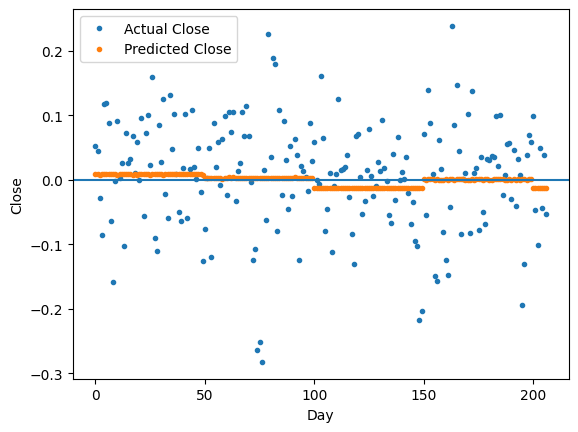

In [44]:
with torch.no_grad():
    predicted = model(X_train.to(device)).to('cpu').numpy()

# scaler_wti = scalers["df_wti_monthly_y_short"]
# predicted_unscaled = scaler_wti.inverse_transform(predicted.reshape(-1, 1)).flatten()

plt.plot(Y_train , '.', label='Actual Close')
plt.plot(predicted, '.' ,label='Predicted Close')
plt.axhline(0 )

plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()



In [45]:
# Assuming predicted and Y_train are already defined in the environment and correspond to the same scale and shape
# Convert tensors if needed
import torch

# Flatten predictions and targets
predicted_array = predicted.flatten()
actual_array = Y_train.flatten()

# Compute DS from the provided arrays
T = len(actual_array)
d = [(actual_array[i]) * (predicted_array[i]) >= 0 for i in range(1, T)]
DS = sum(d) / len(d) * 100
DS


tensor(62.1359)

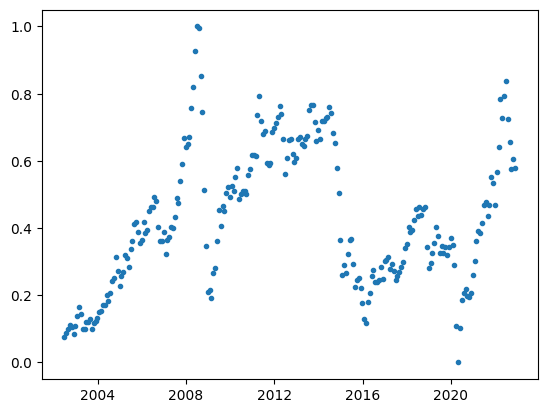

In [46]:
plt.plot(df_wti_monthly_y_short["value"], '.')

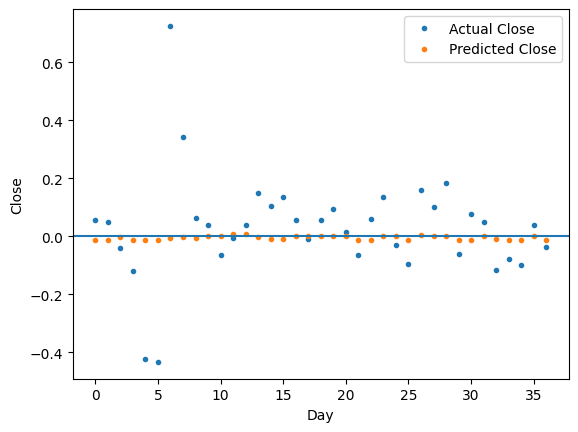

In [47]:
test_predictions = model(X_test.to(device)).detach().cpu().numpy().flatten()


# scaler_wti = scalers["df_wti_monthly_y_short"]
# predicted_unscaled = scaler_wti.inverse_transform(predicted.reshape(-1, 1)).flatten()

plt.plot(Y_test , '.', label='Actual Close')
plt.plot(test_predictions, '.' ,label='Predicted Close')
plt.axhline(0 )

plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.show()



In [48]:
# Assuming predicted and Y_train are already defined in the environment and correspond to the same scale and shape
# Convert tensors if needed
import torch

# Flatten predictions and targets
predicted_array = test_predictions.flatten()
actual_array = Y_test.flatten()

# Compute DS from the provided arrays
T = len(actual_array)
d = [(actual_array[i]) * (predicted_array[i]) >= 0 for i in range(1, T)]
DS = sum(d) / len(d) * 100
DS


tensor(55.5556)